In [1]:
import pymc3 as pm
import theano
import theano.tensor as tt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
import exoplanet as xo
#from exoplanet.distributions import Angle

import pymc3_ext as pmx
#from celerite2.theano import terms, GaussianProcess

import astropy.units as u
from astropy import constants
from astropy.time import Time
import math
#from sigfig import round

import sys
print(sys.executable)

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


/opt/anaconda3/envs/exoplanet/bin/python


In [2]:

def get_median_sigma(pos):
    """
    Helper function to estimate median and sigma from posterior distribution
    Args:
        pos: array from posterior distribution
    Returns:
        (median,sigma): best fit value and 1 sigma uncertainty
    """
    temp = np.percentile(pos,[16,50,84])
    lower = temp[1]-temp[0]
    upper = temp[2]-temp[1]
    sigma = np.max([lower,upper])
    
    return (temp[1], sigma)

def fmt(val, sig):
    """
    Format val±sig with the uncertainty rounded to 2 significant figures
    and the central value matched to the same precision.
    Uses numpy rounding + f-strings (sigfig.round cannot preserve 2-sf uncertainty).
    """
    mag = math.floor(math.log10(abs(sig)))
    ndecimals = max(0, 1 - mag)      # decimal places needed for 2 sig figs
    factor = 10 ** (mag - 1)
    sig_r = np.round(sig / factor) * factor
    val_r = np.round(val / factor) * factor
    if ndecimals > 0:
        return f'{val_r:.{ndecimals}f}$\\pm${sig_r:.{ndecimals}f}'
    else:
        return f'{val_r:.0f}$\\pm${sig_r:.0f}'


In [3]:
# conversion constant from au to R_sun
au_to_R_sun = (constants.au / constants.R_sun).value

# The position angle measurements come in degrees in the range [0, 360].
# We'll convert this to radians in the range [-pi, pi]
deg = np.pi / 180.0
rad_2_deg = 180 / np.pi
yr = 365.25


In [4]:
# parallax from Validation of the new Hipparcos reduction (2007). 
plx_hip = [22.27, 2.31]

# From our last orbital solution
plx_BaBb = [21.9, 0.35]


# RV from our last orbital solution of AaAb and BaBb (gamma_1 and gamma_2)
#RV_A = pd.read_csv('RV_A.csv')
RV_B = pd.read_csv('RV_B.csv')

#t_A = np.ascontiguousarray(RV_A["MJD"], dtype=float) + 2400000.5 # MJD to JD
#rvA = np.ascontiguousarray(RV_A["A"], dtype=float) # km/s
#rvA_err = np.ascontiguousarray(RV_A["A_err"], dtype=float) # km/s

t_B = np.ascontiguousarray(RV_B["MJD"], dtype=float) + 2400000.5 # MJD to JD
rvB = np.ascontiguousarray(RV_B["B"], dtype=float) # km/s
rvB_err = np.ascontiguousarray(RV_B["B_err"], dtype=float) # km/s

#rvB

In [5]:
# Read astrometry

astrometry_AB = pd.read_csv('AB_astrometry.csv')

# Convert years to Julian Dates
outer_jd = Time(np.ascontiguousarray(astrometry_AB["date"]), format="byear").jd
astro_mjds = outer_jd - 2400000.5
rho_data = np.ascontiguousarray(astrometry_AB["sep"], dtype=float)  # arcsec
rho_err = np.ascontiguousarray(astrometry_AB["sep_err"], dtype=float)  # arcsec

# Convert the position angle to radians in [-pi, pi].
theta_data = np.ascontiguousarray(astrometry_AB["pa"].to_numpy() * deg, dtype=float)
theta_data[theta_data > np.pi] -= 2 * np.pi
theta_err = np.ascontiguousarray(
    astrometry_AB["pa_err"].to_numpy() * deg,
    dtype=float
)  # radians

# Cartesian sky offsets: x is north (Dec), y is east (RA).
x_data = rho_data * np.cos(theta_data)  # arcsec, north
y_data = rho_data * np.sin(theta_data)  # arcsec, east

# Propagate independent rho and theta errors through x = rho*cos(theta),
# y = rho*sin(theta), using first-order Jacobian error propagation.
x_err_data = np.sqrt(
    (np.cos(theta_data) * rho_err)**2
    +
    (rho_data * np.sin(theta_data) * theta_err)**2
)  # arcsec

y_err_data = np.sqrt(
    (np.sin(theta_data) * rho_err)**2
    +
    (rho_data * np.cos(theta_data) * theta_err)**2
)  # arcsec

# Covariance is retained because the transformed x/y errors are generally correlated.
xy_cov_data = (
    np.sin(theta_data) * np.cos(theta_data)
    * (rho_err**2 - (rho_data * theta_err)**2)
)  # arcsec^2

astroAB_new = astrometry_AB[['date', 'sep', 'sep_err', 'pa', 'pa_err']]
astroAB_new.to_csv('CSV/astroAaB.csv', index=False)

astroAB_xy = pd.DataFrame({
    "JD": outer_jd,
    "x_north_arcsec": x_data,
    "x_north_err_arcsec": x_err_data,
    "y_east_arcsec": y_data,
    "y_east_err_arcsec": y_err_data,
    "xy_cov_arcsec2": xy_cov_data,
})
astroAB_xy.to_csv('CSV/astroAB_xy.csv', index=False)


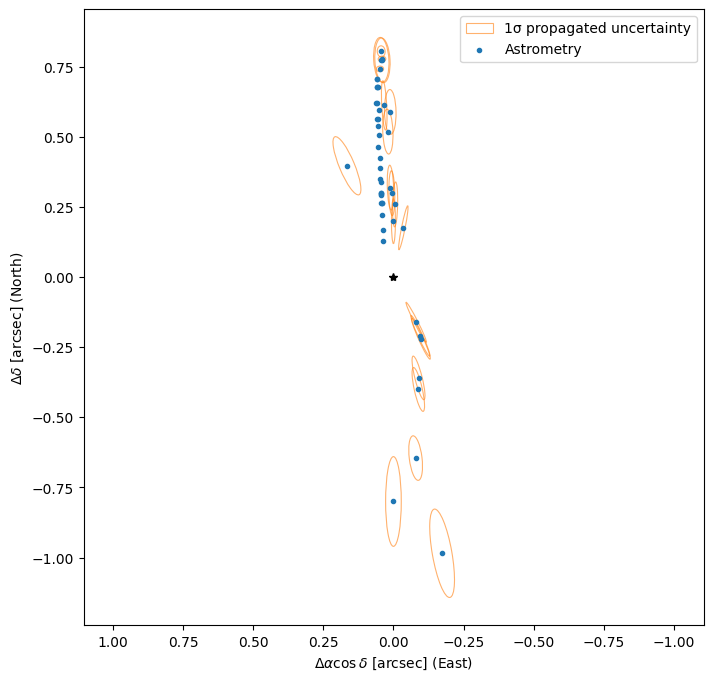

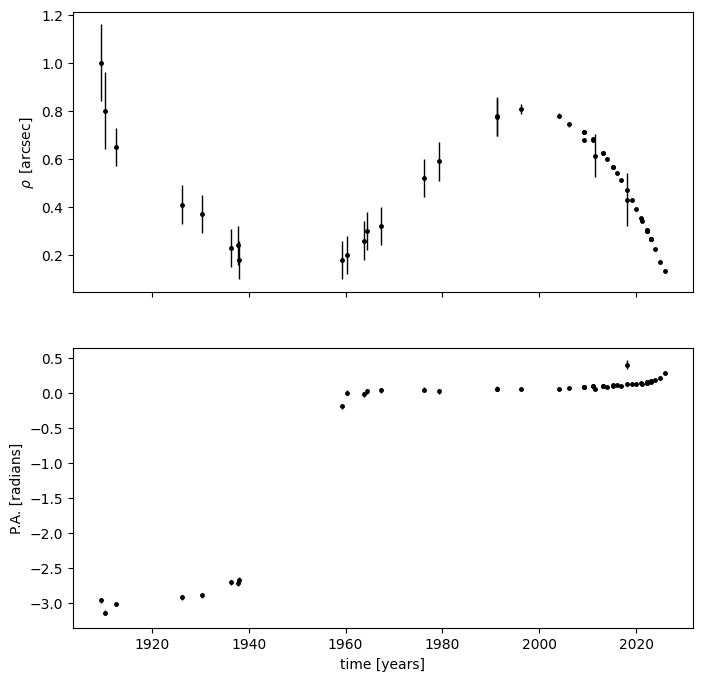

In [6]:
from matplotlib.patches import Ellipse

# Plot sky-plane astrometry with uncertainty ellipses propagated from rho and PA.

fig, ax = plt.subplots(nrows=1, figsize=(8, 8))

for index, (east_offset, north_offset, east_sigma, north_sigma, xy_cov) in enumerate(
    zip(y_data, x_data, y_err_data, x_err_data, xy_cov_data)
):
    covariance_xy = np.array([
        [east_sigma**2, xy_cov],
        [xy_cov, north_sigma**2]
    ])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_xy)
    eigenvalues = np.maximum(eigenvalues, 0.0)
    major_axis = np.argsort(eigenvalues)[::-1]
    major_vector = eigenvectors[:, major_axis[0]]
    ellipse_angle = np.degrees(np.arctan2(major_vector[1], major_vector[0]))

    ax.add_patch(Ellipse(
        (east_offset, north_offset),
        width=2 * np.sqrt(eigenvalues[major_axis[0]]),
        height=2 * np.sqrt(eigenvalues[major_axis[1]]),
        angle=ellipse_angle,
        fill=False,
        edgecolor="C1",
        linewidth=0.8,
        alpha=0.6,
        label="1σ propagated uncertainty" if index == 0 else None
    ))

# Astrometric data on the sky.
# exoplanet convention:
#   X = North
#   Y = East
#   PA = angle East of North
# Matplotlib:
#   horizontal axis = East
#   vertical axis   = North
ax.scatter(y_data, x_data, marker=".", color="C0", label="Astrometry", zorder=3)
ax.set_ylabel(r"$\Delta \delta$ [arcsec] (North)")
ax.set_xlabel(r"$\Delta \alpha \cos\delta$ [arcsec] (East)")
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
ax.legend(loc="best")

# Separation and position angle versus time remain in their measured coordinates.
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 8))
ax[0].errorbar(astrometry_AB['date'], rho_data, yerr=rho_err, fmt=".k", lw=1, ms=5)
ax[0].set_ylabel(r'$\rho\,$ [arcsec]')

ax[1].errorbar(astrometry_AB['date'], theta_data, yerr=theta_err, fmt=".k", lw=1, ms=5)
ax[1].set_ylabel(r"P.A. [radians]")
_ = ax[1].set_xlabel("time [years]")

plt.show()


Median MJD TO95 48635.456400000025
Median JD FEROS 54310.466950000264
Median JD FEROS2 57061.77270000009
Median MJD CTIO 59411.9949
Median MJD ELODIE 50841.6274195
Median MJD Mercator 57054.6979
Median MJD HARPS 60107.96299450006
Median MJD NIRPS 60107.96299450006


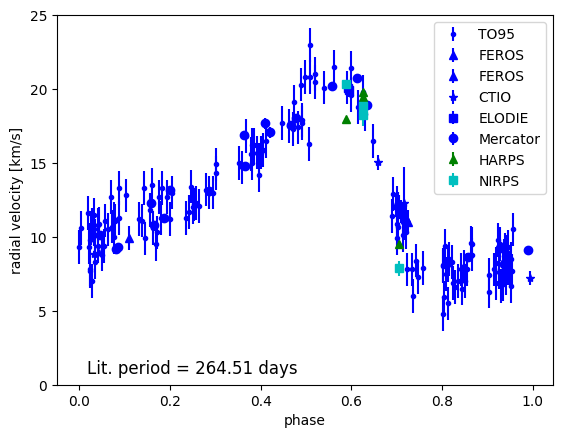

In [7]:
# Read Torres et al. 1995 RV data
RV_Aa = pd.read_csv('RV_Aa.csv')

t = RV_Aa['HJD'].to_numpy()
rva = RV_Aa['Aa'].to_numpy()
rva_err = RV_Aa['Aa_err'].to_numpy()

print("Median MJD TO95", np.median(t)- 2400000.5)

# Read FEROS RV data
RV_Aa = pd.read_csv('RV_Aa_FEROS.csv')

t_FEROS = RV_Aa['MJD'].to_numpy()

t_FEROS = t_FEROS  + 2400000.0 # MJD to JD
print("Median JD FEROS", (np.median(t_FEROS)- 2400000.5))
rva_FEROS = RV_Aa['Aa'].to_numpy()
rva_err_FEROS = RV_Aa['Aa_err'].to_numpy()

# Read FEROS RV data
RV_Aa = pd.read_csv('RV_Aa_FEROS2.csv')

t_FEROS2 = RV_Aa['MJD'].to_numpy()
t_FEROS2 = t_FEROS2  + 2400000.0 # MJD to JD
print("Median JD FEROS2", (np.median(t_FEROS2)- 2400000.5))
rva_FEROS2 = RV_Aa['Aa'].to_numpy()
rva_err_FEROS2 = RV_Aa['Aa_err'].to_numpy()


# Read CHIRON RV data
RV_Aa = pd.read_csv('RV_Aa_CTIO.csv')

t_CTIO = RV_Aa['MJD'].to_numpy()
print("Median MJD CTIO", np.median(t_CTIO))
t_CTIO = t_CTIO  + 2400000.5 # MJD to JD
rva_CTIO = RV_Aa['Aa'].to_numpy()
rva_err_CTIO = RV_Aa['Aa_err'].to_numpy()

# Read ELODIE RV data
RV_Aa = pd.read_csv('RV_Aa_ELODIE.csv')

t_ELODIE = RV_Aa['MJD'].to_numpy()
print("Median MJD ELODIE", np.median(t_ELODIE))
t_ELODIE = t_ELODIE  + 2400000.5 # MJD to JD
rva_ELODIE = RV_Aa['Aa'].to_numpy()
rva_err_ELODIE = RV_Aa['Aa_err'].to_numpy()

# Read Mercator RV data
RV_Aa = pd.read_csv('RV_Aa_Mercator.csv')

t_Mercator = RV_Aa['MJD'].to_numpy()
print("Median MJD Mercator", np.median(t_Mercator))
t_Mercator = t_Mercator  + 2400000.5 # MJD to JD
rva_Mercator = RV_Aa['Aa'].to_numpy()
rva_err_Mercator = RV_Aa['Aa_err'].to_numpy()

# Read HARPS RV data (Aa)
RV_Aa = pd.read_csv('RV_Aa_HARPS.csv')
t_HARPS = RV_Aa['MJD'].to_numpy() + 2400000.5  # MJD to JD
print("Median MJD HARPS", np.median(t_HARPS) - 2400000.5)
rva_HARPS = RV_Aa['Aa'].to_numpy()
rva_err_HARPS = RV_Aa['Aa_err'].to_numpy()

# Read NIRPS RV data (Aa)
RV_Aa = pd.read_csv('RV_Aa_NIRPS.csv')
t_NIRPS = RV_Aa['MJD'].to_numpy() + 2400000.5  # MJD to JD
print("Median MJD NIRPS", np.median(t_NIRPS) - 2400000.5)
rva_NIRPS = RV_Aa['Aa'].to_numpy()
rva_err_NIRPS = RV_Aa['Aa_err'].to_numpy()


# Plot the observations "folded" on the published period:
# Torres et al. 1995
#lit_period = 262.15
# Zuniga-Fernandez et al. 2021
lit_period = 264.51

# Primary
plt.errorbar(
    (t % lit_period) / lit_period, rva, yerr=rva_err, fmt=".b", capsize=0, label="TO95"
)

plt.errorbar(
    (t_FEROS % lit_period) / lit_period, rva_FEROS, yerr=rva_err_FEROS, fmt="^b", capsize=0, label="FEROS"
)

plt.errorbar(
    (t_FEROS2 % lit_period) / lit_period, rva_FEROS2, yerr=rva_err_FEROS2, fmt="^b", capsize=0, label="FEROS"
)

plt.errorbar(
    (t_CTIO % lit_period) / lit_period, rva_CTIO, yerr=rva_err_CTIO, fmt="*b", capsize=0, label="CTIO"
)

plt.errorbar(
    (t_ELODIE % lit_period) / lit_period, rva_ELODIE, yerr=rva_err_ELODIE, fmt="sb", capsize=0, label="ELODIE"
)

plt.errorbar(
    (t_Mercator % lit_period) / lit_period, rva_Mercator, yerr=rva_err_Mercator, fmt="ob", capsize=0, label="Mercator"
)

plt.errorbar(
    (t_HARPS % lit_period) / lit_period, rva_HARPS, yerr=rva_err_HARPS, fmt="^g", capsize=0, label="HARPS"
)

plt.errorbar(
    (t_NIRPS % lit_period) / lit_period, rva_NIRPS, yerr=rva_err_NIRPS, fmt="sc", capsize=0, label="NIRPS"
)

# Secondary (Ab)
#plt.errorbar(
#    (t_HARPSAb % lit_period) / lit_period, rvb_HARPS, yerr=rvb_err_HARPS, fmt="^r", capsize=0, label="HARPS Ab"
#)

#plt.errorbar(
#    (t_NIRPSAb % lit_period) / lit_period, rvb_NIRPS, yerr=rvb_err_NIRPS, fmt="sm", capsize=0, label="NIRPS Ab"
#)

#plt.xlim(0, 1)
plt.ylim(0, 25)
plt.annotate(
    "Lit. period = {0:.2f} days".format(lit_period),
    xy=(0.5, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)

plt.legend(loc='upper right', prop={'size': 10})

plt.ylabel("radial velocity [km/s]")
_ = plt.xlabel("phase")


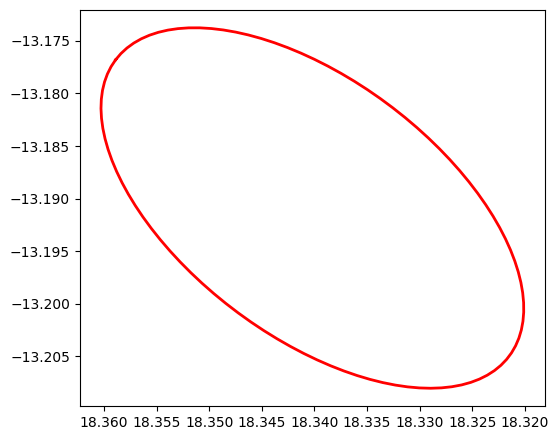

In [8]:
# Lets try now with a joint-fit (astrometry+RV)

# Read astrometry 
astrometry_elipse_A = pd.read_csv('HD98800A_astrometry.csv')


# The uncertainties in the astrometry from optical interferomtry should be represented with an elipse error
# i.e PA, sigma_maj, sigma_min (see Gallenne et al. 2015). 

t_astro = astrometry_elipse_A['MJD'].to_numpy()
astro_jds = t_astro + 2400000.5 # MJD to JD

# x is horizontal and y is vertical (CANDID output convetion). Logical for plotting, but not for exoplanet convention.
x = astrometry_elipse_A['x'].to_numpy()
y = astrometry_elipse_A['y'].to_numpy()

# Semi major axis (sigma_maj) as a astrometry x,y error (to be conservative).
x_err = astrometry_elipse_A['sigma_maj'].to_numpy()
y_err = astrometry_elipse_A['sigma_maj'].to_numpy()

# exoplanet convention:
#   x_model = North
#   y_model = East
#
# Observational data:
#   north_obs = North (y)
#   east_obs  = East (x)

north_obs = y
east_obs = x

# error elipse
astro_sigma_maj = astrometry_elipse_A['sigma_maj'].to_numpy() #semi-major axis
astro_sigma_min = astrometry_elipse_A['sigma_min'].to_numpy() # semi-minor axis
astrometry_PA = astrometry_elipse_A['PA'].to_numpy() # position angle

# Quick test to visualize the error elipse
th = np.linspace(0,2*np.pi,100)
angle = astrometry_PA[1]*deg
_x, _y = astro_sigma_maj[1]*np.cos(th), astro_sigma_min[1]*np.sin(th)

_x, _y = _x*np.cos(angle)+_y*np.sin(angle), -_y*np.cos(angle)+_x*np.sin(angle)
_x += north_obs[1]
_y += east_obs[1]

fig, ax = plt.subplots(nrows=1, figsize=(6, 6))
plt.plot(_y, _x, linestyle='-', color='r', linewidth=2)
ax.invert_xaxis()
ax.set_aspect('equal')
plt.show()

In [9]:
def calc_Mtot(a, P):
    '''
    Calculate the total mass of the system using Kepler's third law. 
    
    Args: 
        a (au) semi-major axis
        P (days) period 
        
    Returns:
        Mtot (M_sun) total mass of system (M_primary + M_secondary)
    '''
    
    day_to_s = (1 * u.day).to(u.s).value
    au_to_m = (1 * u.au).to(u.m).value
    kg_to_M_sun = (1 * u.kg).to(u.M_sun).value
    
    return 4 * np.pi**2 * (a * au_to_m)**3 / (constants.G.value * (P * day_to_s)**2) * kg_to_M_sun


def calc_a(Mtot, P):
    '''
    Calculate the semi-major axis using Kepler's third law 
    
    Args:
        Mtot (Msun) total mass 
        P (days) period
        
    Returns:
        a (au)
    '''
    
    day_to_s = (1 * u.day).to(u.s).value
    au_to_m = (1 * u.au).to(u.m).value
    kg_to_M_sun = (1 * u.kg).to(u.M_sun).value
    
    return (((Mtot / kg_to_M_sun) * constants.G.value * (P * day_to_s)**2) / (4 * np.pi**2))**(1/3) / au_to_m

def calc_K(Mtot, m_K, ecc,i,a):
    '''
    Calculate the RV semi-amplitude 
    
    Args:
        Mtot (Msun) total mass 
        m_K (Msun) mass for K (for K1 use M2 and for K2 use M1)
        ecc eccentricity
        i inclination
        a semi-major axis in AU
        
    Returns:
        K (km/s) semi-amplitude
    '''
    
    #day_to_s = (1 * u.day).to(u.s).value
    au_to_m = (1 * u.au).to(u.m).value
    kg_to_M_sun = (1 * u.kg).to(u.M_sun).value
    
    Kv = np.sqrt(constants.G.value/(1-ecc**2)) * m_K/kg_to_M_sun * np.sin(i) / (np.sqrt(Mtot/kg_to_M_sun) * np.sqrt(a*au_to_m))
    
    return Kv * (1 * u.meter / u.second).to(u.km / u.second).value


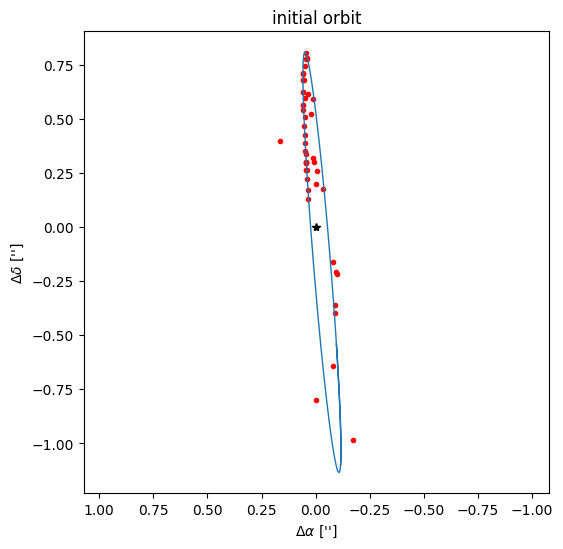

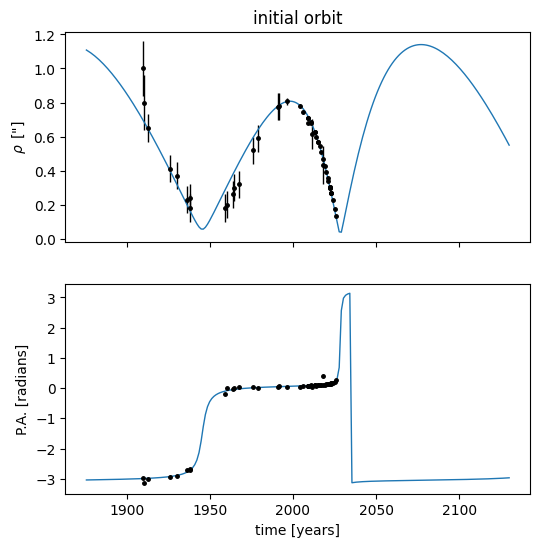

In [10]:
# Orbital elements from Zúñiga-Fernández et al. 2026

# convert from R_sun / day to km/s
# and from v_r = - v_Z
output_units = u.km / u.s
conv = -(1 * u.R_sun / u.day).to(output_units).value

# For the relative astrometric fit, we only need the following parameters
a_ang_0 = 1.067  # arcsec
#parallax = 1  # arcsec (meaningless choice for now)
parallax = 21.89  # arcsec (meaningless choice for now)
a = a_ang_0 * au_to_R_sun / parallax
e_0 = 0.437
i_0 = 87.850 * deg  # [rad]
omega_0 = 69.1 * deg  # omega_1
Omega_0 = 184.47 * deg
P_0 = 212 * yr  # days

T0 = Time(2024.11, format="decimalyear")
T0.format = "jd"
T0 = T0.value  # [Julian Date]
#T0 = 52481.34 + 2400000.5 # [Julian Date]

MB = 1.306


orbit = xo.orbits.KeplerianOrbit(
                a= a,
                t_periastron= T0,
                period= P_0,
                incl= i_0,
                ecc= e_0,
                omega= omega_0,
                Omega= Omega_0,
                m_planet=MB)

# The position functions take an optional argument parallax to convert from
# physical units back to arcseconds
t_fine = np.linspace(T0 - P_0*0.7, T0 + P_0/2, num=200) 
rho, theta = theano.function([], orbit.get_relative_angles(t_fine, parallax))()

rv1 = theano.function([], conv * orbit.get_star_velocity(t_fine)[2])()
rv2 = theano.function([], conv * orbit.get_planet_velocity(t_fine)[2])()

#y_model, x_model, z_model = theano.function([], orbit.get_relative_position(outer_jd, parallax))()

# Plot the orbit
fig, ax = plt.subplots(nrows=1, figsize=(6, 6))

xs = rho * np.cos(theta)  # X is north
ys = rho * np.sin(theta)  # Y is east
ax.plot(ys, xs, color="C0", lw=1)

yd = y_data
xd = x_data
ax.scatter(yd, xd, marker=".", color ='r', label = 'Astrometry')
#ax.scatter(x_model*1000,y_model*1000)

ax.set_ylabel(r"$\Delta \delta$ ['']")
ax.set_xlabel(r"$\Delta \alpha$ ['']")
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
ax.set_title("initial orbit")
#ax.legend(loc='upper left', prop={'size': 12})
#print(astrometry_PA[2])

t_fine_y = Time(np.ascontiguousarray(t_fine), format="jd").byear

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(6, 6))
ax[0].errorbar(astrometry_AB['date'], rho_data, yerr=rho_err, fmt=".k", lw=1, ms=5)
ax[0].plot(t_fine_y, rho, color="C0", lw=1)
ax[0].set_ylabel(r'$\rho\,$ ["]')
ax[0].set_title("initial orbit")

ax[1].errorbar(astrometry_AB['date'], theta_data, yerr=theta_err, fmt=".k", lw=1, ms=5)
ax[1].plot(t_fine_y, theta, color="C0", lw=1)
ax[1].set_ylabel(r"P.A. [radians]")
_ = ax[1].set_xlabel("time [years]")


plt.show()

In [11]:
# =============================================================
# =============================================================
#              HD 98800 INITIAL / REFERENCE VALUES
# =============================================================
# =============================================================

# =============================================================
# Time conversion
# =============================================================

yr = 365.25


# =============================================================
# INNER Aa-Ab From Zúñiga-Fernández et al. 2026
# =============================================================

# Orbital period [days]
P_inner_0 = 264.507

# Periastron passage [MJD]
tp_inner_0 = 48742.46 + 2400000.5 # MJD to JD

# Eccentricity
e_inner_0 = 0.48082

# Argument of periastron [deg]
omega_inner_0 = 68.70 * deg

# Longitude of ascending node [deg]
Omega_inner_0 = 170.17 * deg

# Inclination [deg]
incl_inner_0 = 135.59 * deg

# RV semi-amplitude of Aa [km/s]
K1_inner_0 = 6.79

# Mass of Ab [Msun]
M_Ab_inner_0 = 0.298

# Total mass of Aa-Ab [Msun]
M_AaAb_inner_0 = 1.262

# Mass of Aa [Msun]
M_Aa_inner_0 = (
    M_AaAb_inner_0
    -
    M_Ab_inner_0
)

# Angular semi-major axis [mas]
a_inner_mas_0 = 19.036

# Angular semi-major axis [arcsec]
a_inner_0 = a_inner_mas_0 / 1000.0


# =============================================================
# OUTER A-B - From Zúñiga-Fernández et al. 2026
# =============================================================

# Orbital period [years]
P_outer_0 = 212.0

# Periastron passage [Besselian year]
tp_outer_0 = 2024.11

# Convert outer periastron to MJD.
#
# This assumes t_B, t, and outer_jds are MJD.

tp_outer_JD_0 = Time(
    tp_outer_0,
    format="byear"
).jd

# Eccentricity
e_outer_0 = 0.437

# Argument of periastron [deg]
omega_outer_0 = 69.1 * deg

# Longitude of ascending node [deg]
Omega_outer_0 = 184.47 * deg

# Inclination [deg]
incl_outer_0 = 87.850 * deg

# Systemic velocity [km/s]
gamma_sys_0 = 9.15

# Outer angular semi-major axis [arcsec]
a_outer_0 = 1.067


# =============================================================
# OUTER MASSES
# =============================================================

# BaBb total mass [Msun]
M_BaBb_0 = 1.306

# Previous approximate value
M_BaBb_previous_0 = 1.306


# =============================================================
# WOBBLE
# =============================================================

f_wobble_0 = 0.18


# =============================================================
# =============================================================
#                     DIAGNOSTIC TIME ARRAYS
# =============================================================
# =============================================================

# -------------------------------------------------------------
# Inner orbit diagnostic grid
# -------------------------------------------------------------
#
# The inner orbit has a period of ~264 days, so a relatively
# local grid around the observational baseline is sufficient.

t_fine = np.linspace(
    outer_jd.min() - 700,
    outer_jd.max() + 700,
    num=1000
)


# -------------------------------------------------------------
# Outer orbit diagnostic grids
# -------------------------------------------------------------



# -------------------------------------------------------------
# Full outer-orbit plane-of-sky grid
# -------------------------------------------------------------

t_fine_xy_full = np.linspace(
    tp_outer_JD_0 - 150 * yr,
    tp_outer_JD_0 + 150 * yr,
    num=2000
)


# -------------------------------------------------------------
# High-resolution zoom grid for the wobble
# -------------------------------------------------------------

xy_start_year = 2006.0
xy_end_year   = 2030.0

xy_start_jd = Time(xy_start_year, format="byear").jd
xy_end_jd   = Time(xy_end_year, format="byear").jd

t_fine_xy_zoom = np.linspace(
    xy_start_jd,
    xy_end_jd,
    num=8000
)

# t_fine_outer:
#     Used for diagnosing the complete outer orbit, including
#     quantities such as RV.
#
#     +/-200 years around the outer periastron.

t_fine_outer = np.linspace(
    tp_outer_JD_0 - 200 * yr,
    tp_outer_JD_0 + 200 * yr,
    num=400
)


# -------------------------------------------------------------
# Zero array for PA likelihood
# -------------------------------------------------------------

zeros = np.zeros_like(outer_jd)


In [12]:
# =============================================================
#                         MODEL
# =============================================================

def get_model(parallax=None):
    """Unified hierarchical model for the HD 98800 quadruple system.

    Outer orbit: B = BaBb relative to A = AaAb.
    Inner orbit: Ab relative to Aa.

    B RV measurements constrain the outer orbit. Individual Aa RVs
    include systemic velocity, instrument offset, outer motion, and
    inner Aa motion. AB astrometry includes the Aa-Ab wobble.
    """
    with pm.Model() as model:
        # Constants
        c1 = 1.036149E-7
        c2 = 9.191940E-5
        conv = -(1 * u.R_sun / u.day).to(u.km / u.s).value

        # Outer orbit A-B priors
        logP_outer = pm.Uniform("logP_outer", lower=np.log(50 * yr), upper=np.log(400 * yr), testval=np.log(P_outer_0 * yr))
        P_outer = pm.Deterministic("P_outer", tt.exp(logP_outer))
        omega_outer = pm.Uniform("omega_outer", lower=0.0, upper=2 * np.pi, testval=omega_outer_0)
        Omega_outer = pm.Uniform("Omega_outer", lower=np.pi, upper=2 * np.pi, testval=Omega_outer_0)
        ecc_outer = pm.Uniform("ecc_outer", lower=0.01, upper=0.99, testval=e_outer_0)
        tp_outer = pm.Uniform("tp_outer", lower=Time(2000.0, format="byear").jd, upper=Time(2040.0, format="byear").jd, testval=tp_outer_JD_0)
        cos_incl_outer = pm.Uniform("cos_incl_outer", lower=-1, upper=1, testval=np.cos(incl_outer_0))
        incl_outer = pm.Deterministic("incl_outer", tt.arccos(cos_incl_outer))
        gamma_sys = pm.Uniform("gamma_sys", lower=0, upper=20, testval=gamma_sys_0)

        # Common parallax for both orbits
        if parallax is not None:
            m_plx_outer = pm.Bound(pm.Normal, lower=15, upper=30)("m_plx_outer", mu=parallax[0], sd=parallax[1], testval=parallax[0])
            plx_outer = pm.Deterministic("plx_outer", 1e-3 * m_plx_outer)
            plx = plx_outer
        else:
            plx_outer = 1
            plx = 1

        # Inner orbit Aa-Ab priors
        logP = pm.Uniform("logP", lower=np.log(250), upper=np.log(270), testval=np.log(P_inner_0))
        P = pm.Deterministic("P", tt.exp(logP))
        omega = pm.Uniform("omega", lower=45 * deg, upper=90 * deg, testval=omega_inner_0)
        Omega = pm.Uniform("Omega", lower=0.0, upper=2 * np.pi, testval=Omega_inner_0)
        ecc = pm.Uniform("ecc", lower=0.1, upper=0.9, testval=e_inner_0)
        tp = pm.Normal("tp", mu=tp_inner_0, sd=20, testval=tp_inner_0)
        cos_incl = pm.Uniform("cos_incl", lower=-1, upper=1, testval=np.cos(incl_inner_0))
        incl = pm.Deterministic("incl", tt.arccos(cos_incl))
        K1 = pm.Uniform("K1", lower=1, upper=30, testval=K1_inner_0)

        # Inner orbit mass and physical scale
        if parallax is not None:
            M_2 = pm.Bound(pm.Normal, lower=0.05, upper=1.0)("M_2", mu=M_Ab_inner_0, sd=0.039, testval=M_Ab_inner_0)
            a = pm.Deterministic("a", ((M_2 * c2**2 * P * tt.sin(incl)) / (c1 * K1 * tt.sqrt(1 - ecc**2)))**(1 / 2))
            M_t = pm.Deterministic("M_t", a**3 / (P / yr)**2)
            M_Aa = pm.Deterministic("M_Aa", M_t - M_2)
            a_ang = pm.Deterministic("a_ang", plx * a)
            K2 = pm.Deterministic("K2", (K1 * M_Aa) / M_2)
        else:
            a_ang = pm.Uniform("a_ang", 0.005, 0.3, testval=a_inner_0)
            a = pm.Deterministic("a", a_ang / plx)
            M_t = pm.Deterministic("M_t", a**3 / (P / yr)**2)
            M_2 = pm.Deterministic("M_2", M_Ab_inner_0)
            M_Aa = pm.Deterministic("M_Aa", M_t - M_2)
            K2 = pm.Deterministic("K2", (K1 * M_Aa) / M_2)

        orbit = xo.orbits.KeplerianOrbit(a=a * au_to_R_sun, t_periastron=tp, period=P, incl=incl, ecc=ecc, omega=omega, Omega=Omega)

        # Outer masses and semimajor axis
        if parallax is not None:
            MA_outer = pm.Deterministic("MA_outer", M_t)
            MB_outer = pm.Bound(pm.Normal, lower=0.5, upper=2.0)("MB_outer", mu=M_BaBb_0, sd=0.255, testval=M_BaBb_0)
            Mtot_outer = pm.Deterministic("Mtot_outer", MA_outer + MB_outer)
            a_outer = pm.Deterministic("a_outer", calc_a(Mtot_outer, P_outer))
            a_ang_outer = pm.Deterministic("a_ang_outer", a_outer * plx_outer)
            K1_outer = pm.Deterministic("K1_outer", calc_K(Mtot_outer, MB_outer, ecc_outer, incl_outer, a_outer))
            K2_outer = pm.Deterministic("K2_outer", (K1_outer * MA_outer) / MB_outer)
        else:
            a_ang_outer = pm.Uniform("a_ang_outer", 0.005, 3.0, testval=a_outer_0)
            a_outer = pm.Deterministic("a_outer", a_ang_outer / plx_outer)
            MA_outer = pm.Deterministic("MA_outer", M_t)
            MB_outer = pm.Deterministic("MB_outer", M_BaBb_previous_0)
            Mtot_outer = pm.Deterministic("Mtot_outer", MA_outer + MB_outer)

        orbit_outer = xo.orbits.KeplerianOrbit(
            a=a_outer * au_to_R_sun,
            t_periastron=tp_outer,
            period=P_outer,
            incl=incl_outer,
            ecc=ecc_outer,
            omega=omega_outer,
            Omega=Omega_outer,
            m_planet=MB_outer if parallax is not None else M_BaBb_previous_0
        )

        # Outer RV jitter priors and deterministics
        logjit_outer = pm.Uniform("logjitterouter", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_ELO = pm.Uniform("logjitterouter_ELO", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_FEROS = pm.Uniform("logjitterouter_FEROS", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_FEROS2 = pm.Uniform("logjitterouter_FEROS2", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_CTIO = pm.Uniform("logjitterouter_CTIO", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_K19 = pm.Uniform("logjitterouter_K19", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_MERCATOR = pm.Uniform("logjitterouter_MERCATOR", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_HARPS = pm.Uniform("logjitterouter_HARPS", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        logjit_outer_NIRPS = pm.Uniform("logjitterouter_NIRPS", lower=-5.0, upper=np.log(15), testval=np.log(1.0))
        jit_outer = pm.Deterministic("jitouter", tt.exp(logjit_outer))
        jit_outer_ELO = pm.Deterministic("jitouter_ELO", tt.exp(logjit_outer_ELO))
        jit_outer_FEROS = pm.Deterministic("jitouter_FEROS", tt.exp(logjit_outer_FEROS))
        jit_outer_FEROS2 = pm.Deterministic("jitouter_FEROS2", tt.exp(logjit_outer_FEROS2))
        jit_outer_CTIO = pm.Deterministic("jitouter_CTIO", tt.exp(logjit_outer_CTIO))
        jit_outer_K19 = pm.Deterministic("jitouter_K19", tt.exp(logjit_outer_K19))
        jit_outer_MERCATOR = pm.Deterministic("jitouter_MERCATOR", tt.exp(logjit_outer_MERCATOR))
        jit_outer_HARPS = pm.Deterministic("jitouter_HARPS", tt.exp(logjit_outer_HARPS))
        jit_outer_NIRPS = pm.Deterministic("jitouter_NIRPS", tt.exp(logjit_outer_NIRPS))

        def get_err(rv_err, logjitter):
            return tt.sqrt(rv_err**2 + tt.exp(2 * logjitter))

        # B RV model and likelihoods
        def model_rv2_outer(t):
            return gamma_sys + conv * orbit_outer.get_planet_velocity(t)[2]

        rvmodel_b = pm.Deterministic("rvmodel_b", model_rv2_outer(t_B))
        pm.Normal("obs_b_TO95", mu=rvmodel_b[0], sd=get_err(rvB_err[0], logjit_outer), observed=rvB[0])
        pm.Deterministic("OC_TOb", rvmodel_b[0] - rvB[0])
        pm.Normal("obs_b_ELO", mu=rvmodel_b[1], sd=get_err(rvB_err[1], logjit_outer_ELO), observed=rvB[1])
        pm.Deterministic("OC_ELOb", rvmodel_b[1] - rvB[1])
        pm.Normal("obs_b_K19", mu=rvmodel_b[2], sd=get_err(rvB_err[2], logjit_outer_K19), observed=rvB[2])
        pm.Deterministic("OC_K19b", rvmodel_b[2] - rvB[2])
        pm.Normal("obs_b_CTIO", mu=rvmodel_b[3], sd=get_err(rvB_err[3], logjit_outer_CTIO), observed=rvB[3])
        pm.Deterministic("OC_CTIOb", rvmodel_b[3] - rvB[3])
        pm.Normal("obs_b_MERCATOR", mu=rvmodel_b[4], sd=get_err(rvB_err[4], logjit_outer_MERCATOR), observed=rvB[4])
        pm.Deterministic("OC_MERCATORb", rvmodel_b[4] - rvB[4])
        pm.Normal("obs_b_HARPS", mu=rvmodel_b[5], sd=get_err(rvB_err[5], logjit_outer_HARPS), observed=rvB[5])
        pm.Deterministic("OC_HARPSb", rvmodel_b[5] - rvB[5])
        pm.Normal("obs_b_NIRPS", mu=rvmodel_b[6], sd=get_err(rvB_err[6], logjit_outer_NIRPS), observed=rvB[6])
        pm.Deterministic("OC_NIRPSb", rvmodel_b[6] - rvB[6])

        # get_relative_position returns (x, y, z) = (North, East, z).
        # We assign them as (x_model, y_model, z_model), so:
        #   x_model = North
        #   y_model = East
        # Therefore atan2(y_model, x_model) = atan2(East, North) = PA.

        # Outer astrometry plus Aa-Ab wobble
        x_outer_model, y_outer_model, z_outer_model = orbit_outer.get_relative_position(outer_jd, plx_outer)
        pm.Deterministic("x_outer_model", x_outer_model)
        pm.Deterministic("y_outer_model", y_outer_model)
        x_inner_wobble, y_inner_wobble, z_inner_wobble = orbit.get_relative_position(outer_jd, plx)
        pm.Deterministic("x_inner_wobble", x_inner_wobble)
        pm.Deterministic("y_inner_wobble", y_inner_wobble)
        f_wobble = pm.Normal("f_wobble", mu=f_wobble_0, sd=0.2, testval=f_wobble_0)
        x_model_outer_wobble = pm.Deterministic("x_model_outer_wobble", x_outer_model + f_wobble * x_inner_wobble)
        y_model_outer_wobble = pm.Deterministic("y_model_outer_wobble", y_outer_model + f_wobble * y_inner_wobble)
        pm.Deterministic("x_model_outer", x_model_outer_wobble)
        pm.Deterministic("y_model_outer", y_model_outer_wobble)
        rho_model_outer = tt.sqrt(x_model_outer_wobble**2 + y_model_outer_wobble**2)
        # x = North, y = East; atan2(y, x) gives astronomical PA.
        theta_model_outer = tt.arctan2(y_model_outer_wobble, x_model_outer_wobble)
        pm.Deterministic("rho_model_outer", rho_model_outer)
        pm.Deterministic("theta_model_outer", theta_model_outer)
        pm.Normal("obs_rho_outer", mu=rho_model_outer, observed=rho_data, sd=rho_err)
        pm.Deterministic("rho_diff_outer", rho_data - rho_model_outer)
        theta_diff_outer = tt.arctan2(tt.sin(theta_model_outer - theta_data), tt.cos(theta_model_outer - theta_data))
        pm.Deterministic("theta_diff_outer", theta_diff_outer)
        pm.Normal("obs_theta_outer", mu=theta_diff_outer, observed=zeros, sd=theta_err)

        # Inner RV jitter priors and deterministics
        logjit_TO95 = pm.Uniform("logjitterTO95", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_FEROS = pm.Uniform("logjitterFEROS", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_FEROS2 = pm.Uniform("logjitterFEROS2", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_CTIO = pm.Uniform("logjitterCTIO", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_ELODIE = pm.Uniform("logjitterELODIE", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_Mercator = pm.Uniform("logjitterMercator", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_HARPS_A = pm.Uniform("logjitterHARPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_NIRPS_A = pm.Uniform("logjitterNIRPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        jit_TO95 = pm.Deterministic("jitTO95", tt.exp(logjit_TO95))
        jit_FEROS = pm.Deterministic("jitFEROS", tt.exp(logjit_FEROS))
        jit_FEROS2 = pm.Deterministic("jitFEROS2", tt.exp(logjit_FEROS2))
        jit_CTIO = pm.Deterministic("jitCTIO", tt.exp(logjit_CTIO))
        jit_ELODIE = pm.Deterministic("jitELODIE", tt.exp(logjit_ELODIE))
        jit_Mercator = pm.Deterministic("jitMercator", tt.exp(logjit_Mercator))
        jit_HARPS_A = pm.Deterministic("jitHARPS_A", tt.exp(logjit_HARPS_A))
        jit_NIRPS_A = pm.Deterministic("jitNIRPS_A", tt.exp(logjit_NIRPS_A))

        # Aa instrument zero-point offsets
        delta_gamma_TO95 = pm.Normal("delta_gamma_TO95", mu=0, sd=2, testval=0)
        delta_gamma_FEROS = pm.Normal("delta_gamma_FEROS", mu=0, sd=2, testval=0)
        delta_gamma_FEROS2 = pm.Normal("delta_gamma_FEROS2", mu=0, sd=2, testval=0)
        delta_gamma_CTIO = pm.Normal("delta_gamma_CTIO", mu=0, sd=2, testval=0)
        delta_gamma_ELODIE = pm.Normal("delta_gamma_ELODIE", mu=0, sd=2, testval=0)
        delta_gamma_Mercator = pm.Normal("delta_gamma_Mercator", mu=0, sd=2, testval=0)
        delta_gamma_HARPS = pm.Normal("delta_gamma_HARPS", mu=0, sd=2, testval=0)
        delta_gamma_NIRPS = pm.Normal("delta_gamma_NIRPS", mu=0, sd=2, testval=0)

        # Individual Aa RV model
        def model_rv1_inner(jd):
            return orbit.get_radial_velocity(jd, K=K1)

        def model_rv1(jd, delta_gamma):
            return gamma_sys + delta_gamma + conv * orbit_outer.get_star_velocity(jd)[2] + model_rv1_inner(jd)

        # Aa RV models and likelihoods
        rvmodel_a = pm.Deterministic("rvmodel_a", model_rv1(t, delta_gamma_TO95))
        rvmodel_a_FEROS = pm.Deterministic("rvmodel_a_FEROS", model_rv1(t_FEROS, delta_gamma_FEROS))
        rvmodel_a_FEROS2 = pm.Deterministic("rvmodel_a_FEROS2", model_rv1(t_FEROS2, delta_gamma_FEROS2))
        rvmodel_a_CTIO = pm.Deterministic("rvmodel_a_CTIO", model_rv1(t_CTIO, delta_gamma_CTIO))
        rvmodel_a_ELODIE = pm.Deterministic("rvmodel_a_ELODIE", model_rv1(t_ELODIE, delta_gamma_ELODIE))
        rvmodel_a_Mercator = pm.Deterministic("rvmodel_a_Mercator", model_rv1(t_Mercator, delta_gamma_Mercator))
        rvmodel_a_HARPS = pm.Deterministic("rvmodel_a_HARPS", model_rv1(t_HARPS, delta_gamma_HARPS))
        rvmodel_a_NIRPS = pm.Deterministic("rvmodel_a_NIRPS", model_rv1(t_NIRPS, delta_gamma_NIRPS))
        pm.Normal("obs_a", mu=rvmodel_a, sd=get_err(rva_err, logjit_TO95), observed=rva)
        pm.Normal("obs_a_FEROS", mu=rvmodel_a_FEROS, sd=get_err(rva_err_FEROS, logjit_FEROS), observed=rva_FEROS)
        pm.Normal("obs_a_FEROS2", mu=rvmodel_a_FEROS2, sd=get_err(rva_err_FEROS2, logjit_FEROS2), observed=rva_FEROS2)
        pm.Normal("obs_a_CTIO", mu=rvmodel_a_CTIO, sd=get_err(rva_err_CTIO, logjit_CTIO), observed=rva_CTIO)
        pm.Normal("obs_a_ELODIE", mu=rvmodel_a_ELODIE, sd=get_err(rva_err_ELODIE, logjit_ELODIE), observed=rva_ELODIE)
        pm.Normal("obs_a_Mercator", mu=rvmodel_a_Mercator, sd=get_err(rva_err_Mercator, logjit_Mercator), observed=rva_Mercator)
        pm.Normal("obs_a_HARPS", mu=rvmodel_a_HARPS, sd=get_err(rva_err_HARPS, logjit_HARPS_A), observed=rva_HARPS)
        pm.Normal("obs_a_NIRPS", mu=rvmodel_a_NIRPS, sd=get_err(rva_err_NIRPS, logjit_NIRPS_A), observed=rva_NIRPS)

        # Inner astrometry with error-ellipse residuals
        # get_relative_position returns (x, y, z) = (North, East, z).
        # We assign them as (x_model, y_model, z_model), so:
        #   x_model = North
        #   y_model = East
        #   z_model = z
        # Therefore atan2(y_model, x_model) = atan2(East, North) = PA.

        x_model, y_model, z_model = orbit.get_relative_position(astro_jds, plx)
        pm.Deterministic("x_model", x_model)
        pm.Deterministic("y_model", y_model)
        Maj_err = (north_obs - x / 1000) * tt.cos(astrometry_PA * deg) + (east_obs - y / 1000) * tt.sin(astrometry_PA * deg)
        Min_err = (east_obs - y / 1000) * tt.cos(astrometry_PA * deg) - (north_obs - x / 1000) * tt.sin(astrometry_PA * deg)
        pm.Deterministic("Maj_err", Maj_err * 1000)
        pm.Deterministic("Min_err", Min_err * 1000)
        pm.Normal("sigmaMaj_obs", mu=Maj_err, sd=astro_sigma_maj / 1000, observed=0.0)
        pm.Normal("sigmaMin_obs", mu=Min_err, sd=astro_sigma_min / 1000, observed=0.0)

        # Diagnostic RV components
        rv_outer_Aa = pm.Deterministic("rv_outer_Aa", conv * orbit_outer.get_star_velocity(t)[2])
        rv_inner_Aa = pm.Deterministic("rv_inner_Aa", orbit.get_radial_velocity(t, K=K1))
        rv_Aa_physical = pm.Deterministic("rv_Aa_physical", rv_outer_Aa + rv_inner_Aa)

        # Predicted inner orbit and inner Aa RV
        x_dense, y_dense, z_dense = orbit.get_relative_position(t_fine, plx)
        x_save = pm.Deterministic("x_save", x_dense)
        y_save = pm.Deterministic("y_save", y_dense)
       
        va_dense = orbit.get_radial_velocity(t_fine, K1)
        va_save = pm.Deterministic("va_save", va_dense)

        # Full outer-orbit plane-of-sky track
        x_dense_outer_xy_full, y_dense_outer_xy_full, z_dense_outer_xy_full = orbit_outer.get_relative_position(t_fine_xy_full, plx_outer)
        x_save_outer_xy_full = pm.Deterministic("x_save_outer_xy_full", x_dense_outer_xy_full)
        y_save_outer_xy_full = pm.Deterministic("y_save_outer_xy_full", y_dense_outer_xy_full)

        # Full outer orbit plus Aa-Ab wobble
        x_dense_inner_wobble_full, y_dense_inner_wobble_full, _ = orbit.get_relative_position(t_fine_xy_full, plx)
        x_save_outer_xy_wobble_full = pm.Deterministic("x_save_outer_xy_wobble_full", x_dense_outer_xy_full + f_wobble * x_dense_inner_wobble_full)
        y_save_outer_xy_wobble_full = pm.Deterministic("y_save_outer_xy_wobble_full", y_dense_outer_xy_full + f_wobble * y_dense_inner_wobble_full)
        rho_save_outer_xy_full = pm.Deterministic("rho_save_outer_xy_full", tt.sqrt(x_save_outer_xy_wobble_full**2 + y_save_outer_xy_wobble_full**2))
        theta_save_outer_xy_full = pm.Deterministic("theta_save_outer_xy_full", tt.arctan2(y_save_outer_xy_wobble_full, x_save_outer_xy_wobble_full))

        # High-resolution zoom tracks, with and without Aa-Ab wobble
        x_dense_outer_xy_zoom, y_dense_outer_xy_zoom, z_dense_outer_xy_zoom = orbit_outer.get_relative_position(t_fine_xy_zoom, plx_outer)
        x_save_outer_xy_zoom = pm.Deterministic("x_save_outer_xy_zoom", x_dense_outer_xy_zoom)
        y_save_outer_xy_zoom = pm.Deterministic("y_save_outer_xy_zoom", y_dense_outer_xy_zoom)
        y_dense_inner_wobble_zoom, x_dense_inner_wobble_zoom, _ = orbit.get_relative_position(t_fine_xy_zoom, plx)
        x_save_outer_xy_wobble_zoom = pm.Deterministic("x_save_outer_xy_wobble_zoom", x_dense_outer_xy_zoom + f_wobble * x_dense_inner_wobble_zoom)
        y_save_outer_xy_wobble_zoom = pm.Deterministic("y_save_outer_xy_wobble_zoom", y_dense_outer_xy_zoom + f_wobble * y_dense_inner_wobble_zoom)
        rho_save_outer_xy_zoom = pm.Deterministic("rho_save_outer_xy_zoom", tt.sqrt(x_save_outer_xy_wobble_zoom**2 + y_save_outer_xy_wobble_zoom**2))
        theta_save_outer_xy_zoom = pm.Deterministic("theta_save_outer_xy_zoom", tt.arctan2(y_save_outer_xy_wobble_zoom, x_save_outer_xy_wobble_zoom))

        # Full outer-orbit diagnostics and RV predictions
        y_dense_outer, x_dense_outer, z_dense_outer = orbit_outer.get_relative_position(t_fine_outer, plx_outer)
        x_save_outer = pm.Deterministic("x_save_outer", x_dense_outer)
        y_save_outer = pm.Deterministic("y_save_outer", y_dense_outer)
        va_outer_dense = pm.Deterministic("va_outer_save", conv * orbit_outer.get_star_velocity(t_fine_outer)[2])
        vb_outer_dense = pm.Deterministic("vb_outer_save", conv * orbit_outer.get_planet_velocity(t_fine_outer)[2])
        va_total_dense = pm.Deterministic("va_total_save", conv * orbit_outer.get_star_velocity(t_fine_outer)[2] + orbit.get_radial_velocity(t_fine_outer, K1))
        rv_Aa_dense = pm.Deterministic("rv_Aa_dense", gamma_sys + conv * orbit_outer.get_star_velocity(t_fine_outer)[2] + orbit.get_radial_velocity(t_fine_outer, K1))
        rv_B_dense = pm.Deterministic("rv_B_dense", gamma_sys + conv * orbit_outer.get_planet_velocity(t_fine_outer)[2])

        # Derived mass ratios
        q_inner = pm.Deterministic("q_inner", M_2 / M_Aa)
        f_inner = pm.Deterministic("f_inner", M_2 / M_t)
        q_outer = pm.Deterministic("q_outer", MB_outer / MA_outer)

        # MAP solution
        map_soln = pmx.optimize(model.test_point)

    return model, map_soln


# Run model
model, map_soln = get_model(parallax=plx_BaBb)


optimizing logp for variables: [delta_gamma_NIRPS, delta_gamma_HARPS, delta_gamma_Mercator, delta_gamma_ELODIE, delta_gamma_CTIO, delta_gamma_FEROS2, delta_gamma_FEROS, delta_gamma_TO95, logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, f_wobble, logjitterouter_NIRPS, logjitterouter_HARPS, logjitterouter_MERCATOR, logjitterouter_K19, logjitterouter_CTIO, logjitterouter_FEROS2, logjitterouter_FEROS, logjitterouter_ELO, logjitterouter, MB_outer, M_2, K1, cos_incl, tp, ecc, Omega, omega, logP, m_plx_outer, gamma_sys, cos_incl_outer, tp_outer, ecc_outer, Omega_outer, omega_outer, logP_outer]


message: Desired error not necessarily achieved due to precision loss.
logp: -7315893303482.932 -> -7315893301924.598


========== SYSTEMIC / INSTRUMENT OFFSETS ==========
gamma_sys = 9.099164295036656
delta_gamma_TO95    = 0.33052290759688074
delta_gamma_FEROS   = 1.447507878521659
delta_gamma_FEROS2   = -0.7572905956863077
delta_gamma_CTIO   = 0.27225506440246483
delta_gamma_ELODIE   = -1.4052970457751317
delta_gamma_Mercator   = -0.12976184173480415
delta_gamma_HARPS   = 0.5784180608561644
delta_gamma_NIRPS   = 0.4614596059538187

========== OUTER ORBIT ==========
parallax = 21.77995601712689
Tp_outer = 2026.2971359226215
P_outer [yr] = 189.40210453265132
a_outer [AU] = 44.3026031991804
a_outer [arcsec] = 0.9649087491223742
Omega_outer [deg] = 184.39172777811055
omega_outer [deg] = 78.385296579104
incl_outer [deg] = 87.59573470107814
e_outer = 0.43123721554770866

========== INNER Aa-Ab ORBIT ==========
P_inner [days] = 264.5038675237037
Tp_inner = 48738.68492214801
a_inner [AU] = 0.8598559743544775
a_inner [arcsec] = 0.018727625302504308
Omega_inner [deg] = 181.5714823526331
omega_inner [deg] = 62.3

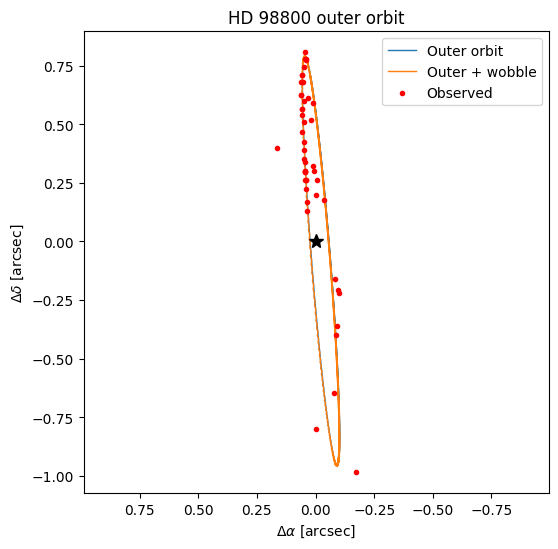

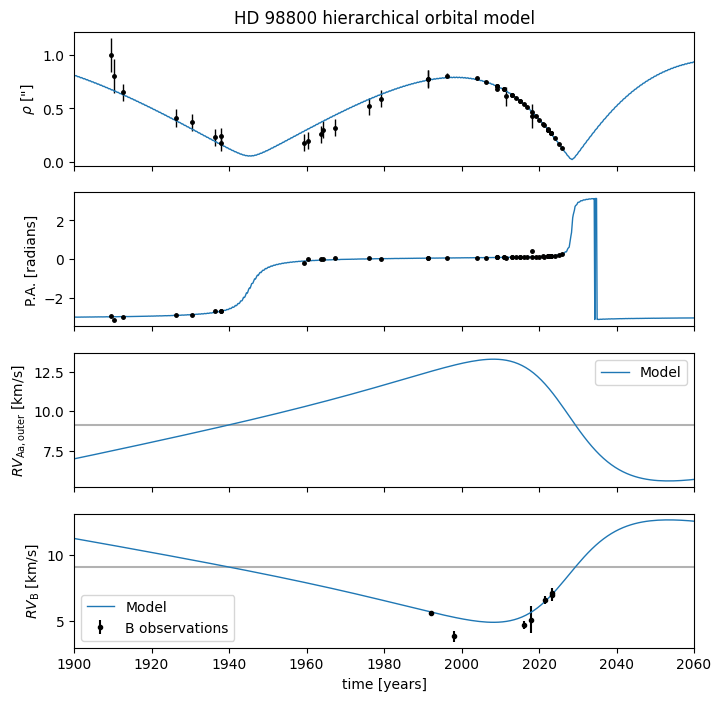

In [13]:
# ============================================================
# Plot the MAP solution
# ============================================================

print("========== SYSTEMIC / INSTRUMENT OFFSETS ==========")

print("gamma_sys =", map_soln["gamma_sys"])

print("delta_gamma_TO95    =", map_soln["delta_gamma_TO95"])

print("delta_gamma_FEROS   =", map_soln["delta_gamma_FEROS"])

print("delta_gamma_FEROS2   =", map_soln["delta_gamma_FEROS2"])

print("delta_gamma_CTIO   =", map_soln["delta_gamma_CTIO"])

print("delta_gamma_ELODIE   =", map_soln["delta_gamma_ELODIE"])

print("delta_gamma_Mercator   =", map_soln["delta_gamma_Mercator"])

print("delta_gamma_HARPS   =", map_soln["delta_gamma_HARPS"])

print("delta_gamma_NIRPS   =", map_soln["delta_gamma_NIRPS"])


print("")

print("========== OUTER ORBIT ==========")

print("parallax =", map_soln["m_plx_outer"])

print(
    "Tp_outer =",
    Time(map_soln["tp_outer"], format="jd").byear
)

print("P_outer [yr] =", map_soln["P_outer"] / yr)

print("a_outer [AU] =", map_soln["a_outer"])

print("a_outer [arcsec] =", map_soln["a_ang_outer"])

print(
    "Omega_outer [deg] =",
    map_soln["Omega_outer"] * rad_2_deg
)

print(
    "omega_outer [deg] =",
    map_soln["omega_outer"] * rad_2_deg
)

print(
    "incl_outer [deg] =",
    map_soln["incl_outer"] * rad_2_deg
)

print("e_outer =", map_soln["ecc_outer"])

print("")

print("========== INNER Aa-Ab ORBIT ==========")

print("P_inner [days] =", map_soln["P"])

print(
    "Tp_inner =",
    Time(map_soln["tp"], format="jd").mjd
)

print("a_inner [AU] =", map_soln["a"])

print("a_inner [arcsec] =", map_soln["a_ang"])

print(
    "Omega_inner [deg] =",
    map_soln["Omega"] * rad_2_deg
)

print(
    "omega_inner [deg] =",
    map_soln["omega"] * rad_2_deg
)

print(
    "incl_inner [deg] =",
    map_soln["incl"] * rad_2_deg
)

print("e_inner =", map_soln["ecc"])

print("K1_inner [km/s] =", map_soln["K1"])

print("M_Aa =", map_soln["M_Aa"])

print("M_Ab =", map_soln["M_2"])

print("M_AaAb =", map_soln["M_t"])

print("")

print("========== OUTER MASSES ==========")

print("M_A_outer =", map_soln["MA_outer"])

print("M_B_outer =", map_soln["MB_outer"])

print("M_total_outer =", map_soln["Mtot_outer"])

print("q_inner =", map_soln["q_inner"])

print("q_outer =", map_soln["q_outer"])

print("f_wobble =", map_soln["f_wobble"])


# ============================================================
# OUTER ORBIT IN THE PLANE OF THE SKY
# ============================================================

fig, ax = plt.subplots(
    nrows=1,
    figsize=(6, 6)
)

# Pure outer orbit
ax.plot(
    map_soln["y_save_outer_xy_full"],
    map_soln["x_save_outer_xy_full"],
    color="C0",
    lw=1,
    label="Outer orbit"
)

# Outer orbit + Aa-Ab wobble
ax.plot(
    map_soln["y_save_outer_xy_wobble_full"],
    map_soln["x_save_outer_xy_wobble_full"],
    color="C1",
    lw=1,
    label="Outer + wobble"
)

# Observed astrometry
ax.scatter(
    yd,
    xd,
    marker=".",
    color="r",
    zorder=3,
    label="Observed"
)

# Reference position
ax.plot(
    0,
    0,
    "k*",
    ms=10
)

ax.set_ylabel(r"$\Delta\delta$ [arcsec]")

ax.set_xlabel(r"$\Delta\alpha$ [arcsec]")

# East is to the left
ax.invert_xaxis()

ax.set_aspect("equal", "datalim")

ax.set_title("HD 98800 outer orbit")

ax.legend(loc="best")

plt.show()


# ============================================================
# TIME ARRAYS
# ============================================================

# All model times are JD

t_fine_y = Time(
    np.ascontiguousarray(t_fine),
    format="jd"
).byear

t_fine_xy_full_y = Time(
    np.ascontiguousarray(t_fine_xy_full),
    format="jd"
).byear

t_fine_xy_zoom_y = Time(
    np.ascontiguousarray(t_fine_xy_zoom),
    format="jd"
).byear

t_fine_outer_y = Time(
    np.ascontiguousarray(t_fine_outer),
    format="jd"
).byear


# ============================================================
# ASTROMETRY + RADIAL VELOCITIES
# ============================================================

fig, ax = plt.subplots(
    nrows=4,
    sharex=True,
    figsize=(8, 8)
)


# ------------------------------------------------------------
# 1. Separation
# ------------------------------------------------------------

ax[0].errorbar(
    astrometry_AB["date"],
    rho_data,
    yerr=rho_err,
    fmt=".k",
    lw=1,
    ms=5
)

ax[0].plot(
    t_fine_xy_full_y,
    map_soln["rho_save_outer_xy_full"],
    color="C0",
    lw=1
)

ax[0].set_ylabel(r'$\rho$ ["]')

ax[0].set_title(
    "HD 98800 hierarchical orbital model"
)


# ------------------------------------------------------------
# 2. Position angle
# ------------------------------------------------------------

ax[1].errorbar(
    astrometry_AB["date"],
    theta_data,
    yerr=theta_err,
    fmt=".k",
    lw=1,
    ms=5
)

ax[1].plot(
    t_fine_xy_full_y,
    map_soln["theta_save_outer_xy_full"],
    color="C0",
    lw=1
)

ax[1].set_ylabel(r"P.A. [radians]")


# ------------------------------------------------------------
# 3. Aa radial velocity
# ------------------------------------------------------------

ax[2].axhline(
    map_soln["gamma_sys"],
    color="k",
    alpha=0.3
)

# Observations
# ax[2].errorbar(
#     Time(t_HARPS, format="jd").byear,
#     rva_HARPS,
#     yerr=rva_err_HARPS,
#     fmt=".k",
#     label="Aa HARPS observations"
# )

# Full physical Aa outer-orbit prediction
ax[2].plot(
    t_fine_outer_y,
    map_soln["va_outer_save"] + map_soln["gamma_sys"],
    color="C0",
    lw=1,
    label="Model"
)

ax[2].set_ylabel(r"$RV_{\rm Aa,outer}$ [km/s]")

ax[2].legend(loc="best")


# ------------------------------------------------------------
# 4. B radial velocity
# ------------------------------------------------------------

ax[3].axhline(
    map_soln["gamma_sys"],
    color="k",
    alpha=0.3
)

# Observations
ax[3].errorbar(
    Time(t_B, format="jd").byear,
    rvB,
    yerr=rvB_err,
    fmt=".k",
    label="B observations"
)

# Full physical B prediction
ax[3].plot(
    t_fine_outer_y,
    map_soln["rv_B_dense"],
    color="C0",
    lw=1,
    label="Model"
)

ax[3].set_ylabel(r"$RV_{\rm B}$ [km/s]")

ax[3].set_xlabel("time [years]")

ax[3].legend(loc="best")

plt.setp(
    ax[3],
    xlim=[1900, 2060]
)

plt.show()

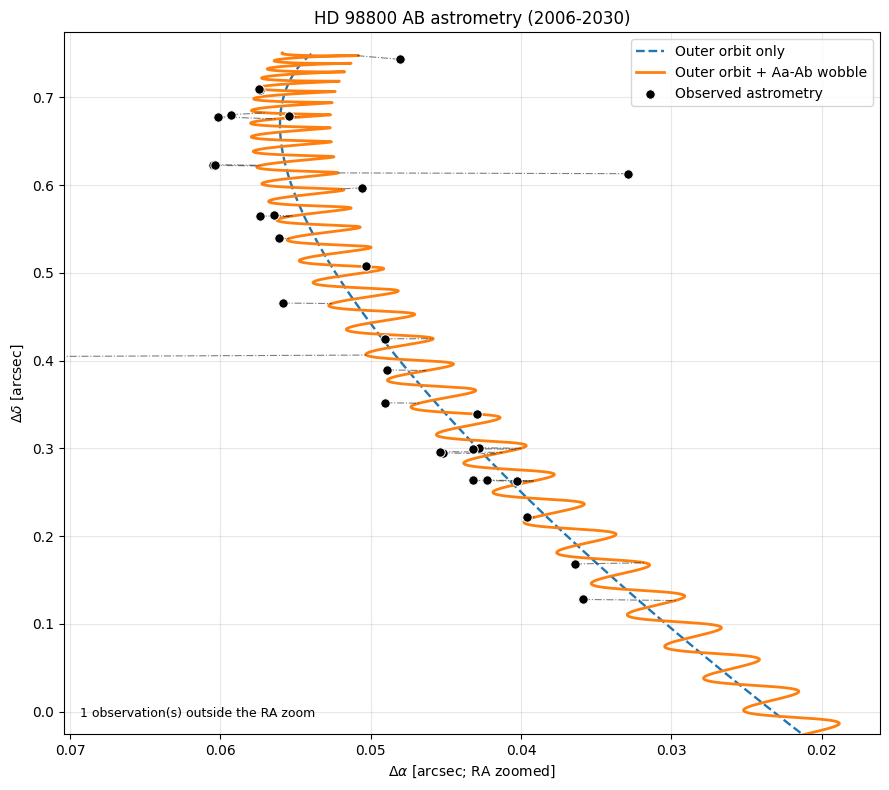

In [14]:
# ============================================================
# ZOOMED XY ASTROMETRY: OUTER ORBIT VS OUTER + WOBBLE
# ============================================================
# Compare both model tracks directly against observations in the
# dedicated 2006-2030 zoom interval. A robust RA window prevents a
# single high-PA-error measurement from hiding the wobble separation.

x_outer_zoom = map_soln["x_save_outer_xy_zoom"]                  # North
y_outer_zoom = map_soln["y_save_outer_xy_zoom"]                  # East
x_outer_wobble_zoom = map_soln["x_save_outer_xy_wobble_zoom"]    # North
y_outer_wobble_zoom = map_soln["y_save_outer_xy_wobble_zoom"]    # East

t_zoom_year = Time(
    np.ascontiguousarray(t_fine_xy_zoom),
    format="jd"
).byear

obs_year = astrometry_AB["date"].to_numpy(dtype=float)

obs_in_zoom = (
    (obs_year >= t_zoom_year[0]) &
    (obs_year <= t_zoom_year[-1])
)

# Data convention:
# xd = North = Delta Dec
# yd = East  = Delta RA cos(delta)

x_observed_zoom = xd[obs_in_zoom]    # North
y_observed_zoom = yd[obs_in_zoom]    # East

fig, ax = plt.subplots(figsize=(9, 8))

# The pure outer orbit is dashed; the wobble-adjusted prediction is solid.
ax.plot(
    y_outer_zoom,
    x_outer_zoom,
    color="C0",
    lw=1.7,
    ls="--",
    label="Outer orbit only",
    zorder=2
)
ax.plot(
    y_outer_wobble_zoom,
    x_outer_wobble_zoom,
    color="C1",
    lw=2.0,
    ls="-",
    label="Outer orbit + Aa-Ab wobble",
    zorder=3
)

ax.scatter(
    y_observed_zoom,
    x_observed_zoom,
    marker="o",
    s=46,
    facecolor="black",
    edgecolor="white",
    linewidth=0.7,
    zorder=5,
    label="Observed astrometry"
)

# Add pointer lines connecting observations to the wobble model curve
for i in range(len(x_observed_zoom)):
    # Find nearest point on the wobble model curve
    distances = np.sqrt(
            (x_outer_wobble_zoom - x_observed_zoom[i])**2 +
            (y_outer_wobble_zoom - y_observed_zoom[i])**2
        )
    
    nearest_idx = np.argmin(distances)
    
    # Draw pointer line from observation to model curve
    ax.plot(
            [
                y_observed_zoom[i],
                y_outer_wobble_zoom[nearest_idx]
            ],
            [
                x_observed_zoom[i],
                x_outer_wobble_zoom[nearest_idx]
            ],
        color="black",
        linestyle="-.",
        linewidth=0.8,
        alpha=0.5,
        zorder=4
    )

# Use central observed RA values for the detail view and report clipped points.
ra_min, ra_max = np.percentile(y_observed_zoom, [5, 95])
ra_padding = max(0.01, 0.05 * (ra_max - ra_min))
ra_zoom_min = ra_min - 2*ra_padding
ra_zoom_max = ra_max + ra_padding

n_ra_clipped = np.count_nonzero(
    (y_observed_zoom < ra_zoom_min)
    | (y_observed_zoom > ra_zoom_max)
)

# Dec/North padding
y_padding = max(0.02, 0.05 * np.ptp(x_observed_zoom))

ax.set_xlim(ra_zoom_max, ra_zoom_min)

ax.set_ylim(
    x_observed_zoom.min() - 5*y_padding,
    x_observed_zoom.max() + y_padding
)

ax.set_xlabel(r"$\Delta\alpha$ [arcsec; RA zoomed]")
ax.set_ylabel(r"$\Delta\delta$ [arcsec]")
ax.grid(alpha=0.3)
ax.set_title(
    f"HD 98800 AB astrometry ({t_zoom_year[0]:.0f}-{t_zoom_year[-1]:.0f})"
)
ax.legend(loc="best")

if n_ra_clipped:
    ax.text(
        0.02,
        0.02,
        f"{n_ra_clipped} observation(s) outside the RA zoom",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom"
    )

# RA and Dec use independent display scales here to emphasize the narrow RA
# range; use the numeric axis ticks rather than judging angular shape by eye.
ax.set_aspect("auto")

plt.tight_layout()
plt.savefig("Plots/AB_outer_orbit_vs_wobble_astrometry_zoom.pdf", bbox_inches="tight")
plt.show()

In [15]:
#That looks fine, so now we can run the MCMC sampler:
np.random.seed(39091)
with model:
    trace = pmx.sample(
        tune=3500, draws=2000, start=map_soln, chains=5, cores=5, target_accept=0.98, init="adapt_full",
    )

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/opt/anaconda3/envs/exoplanet/lib/python3.9/site-packages/deprecat/classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Multiprocess sampling (5 chains in 5 jobs)
NUTS: [delta_gamma_NIRPS, delta_gamma_HARPS, delta_gamma_Mercator, delta_gamma_ELODIE, delta_gamma_CTIO, delta_gamma_FEROS2, delta_gamma_FEROS, delta_gamma_TO95, logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, f_wobble, logjitterouter_NIRPS, logjitterouter_HARPS, logjitterouter_MERCATOR, logjitterouter_K19, logjitter

Sampling 5 chains for 3_500 tune and 2_000 draw iterations (17_500 + 10_000 draws total) took 1844 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


In [ ]:
# Then we can look at some summaries of the trace and the constraints on some of the key parameters:
with model:
    summary = pm.summary(
    trace,
    var_names=[
        "P_outer",
        "tp_outer",
        "omega_outer",
        "Omega_outer",
        "incl_outer",
        "ecc_outer",
        "a_ang_outer",
        "f_wobble",
        "gamma_sys",
    ],
    round_to=3
)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
P_outer,69793.321,4268.143,62240.281,77903.880,92.559,66.602,2239.921,1749.177,1.002
tp_outer,2461105.829,350.335,2460462.705,2461766.038,7.316,5.174,2261.590,1891.779,1.003
omega_outer,1.362,0.085,1.209,1.528,0.002,0.001,2255.675,1882.451,1.003
Omega_outer,3.219,0.001,3.218,3.220,0.000,0.000,5282.985,5740.399,1.000
incl_outer,1.529,0.001,1.527,1.531,0.000,0.000,2693.813,1964.861,1.002
ecc_outer,0.436,0.013,0.414,0.460,0.000,0.000,2177.233,1601.553,1.002
a_ang_outer,0.971,0.045,0.891,1.056,0.001,0.001,2242.892,1743.886,1.003
f_wobble,0.134,0.012,0.112,0.157,0.000,0.000,9794.606,5618.358,1.000
gamma_sys,9.212,0.141,8.950,9.470,0.002,0.001,5628.731,3476.603,1.000


Period (years): 183$\pm$12
Tp (years): 2026.9$\pm$1.1
omega (deg): 81.3$\pm$5.5
Omega (deg): 184.381$\pm$0.043
i (deg): 87.558$\pm$0.072
a (arcsec): 0.940$\pm$0.047
e: 0.425$\pm$0.013
gamma_sys (km/s): 9.07$\pm$0.43
f_wobble: 0.157$\pm$0.022
Pandas support in corner is deprecated; use ArviZ directly


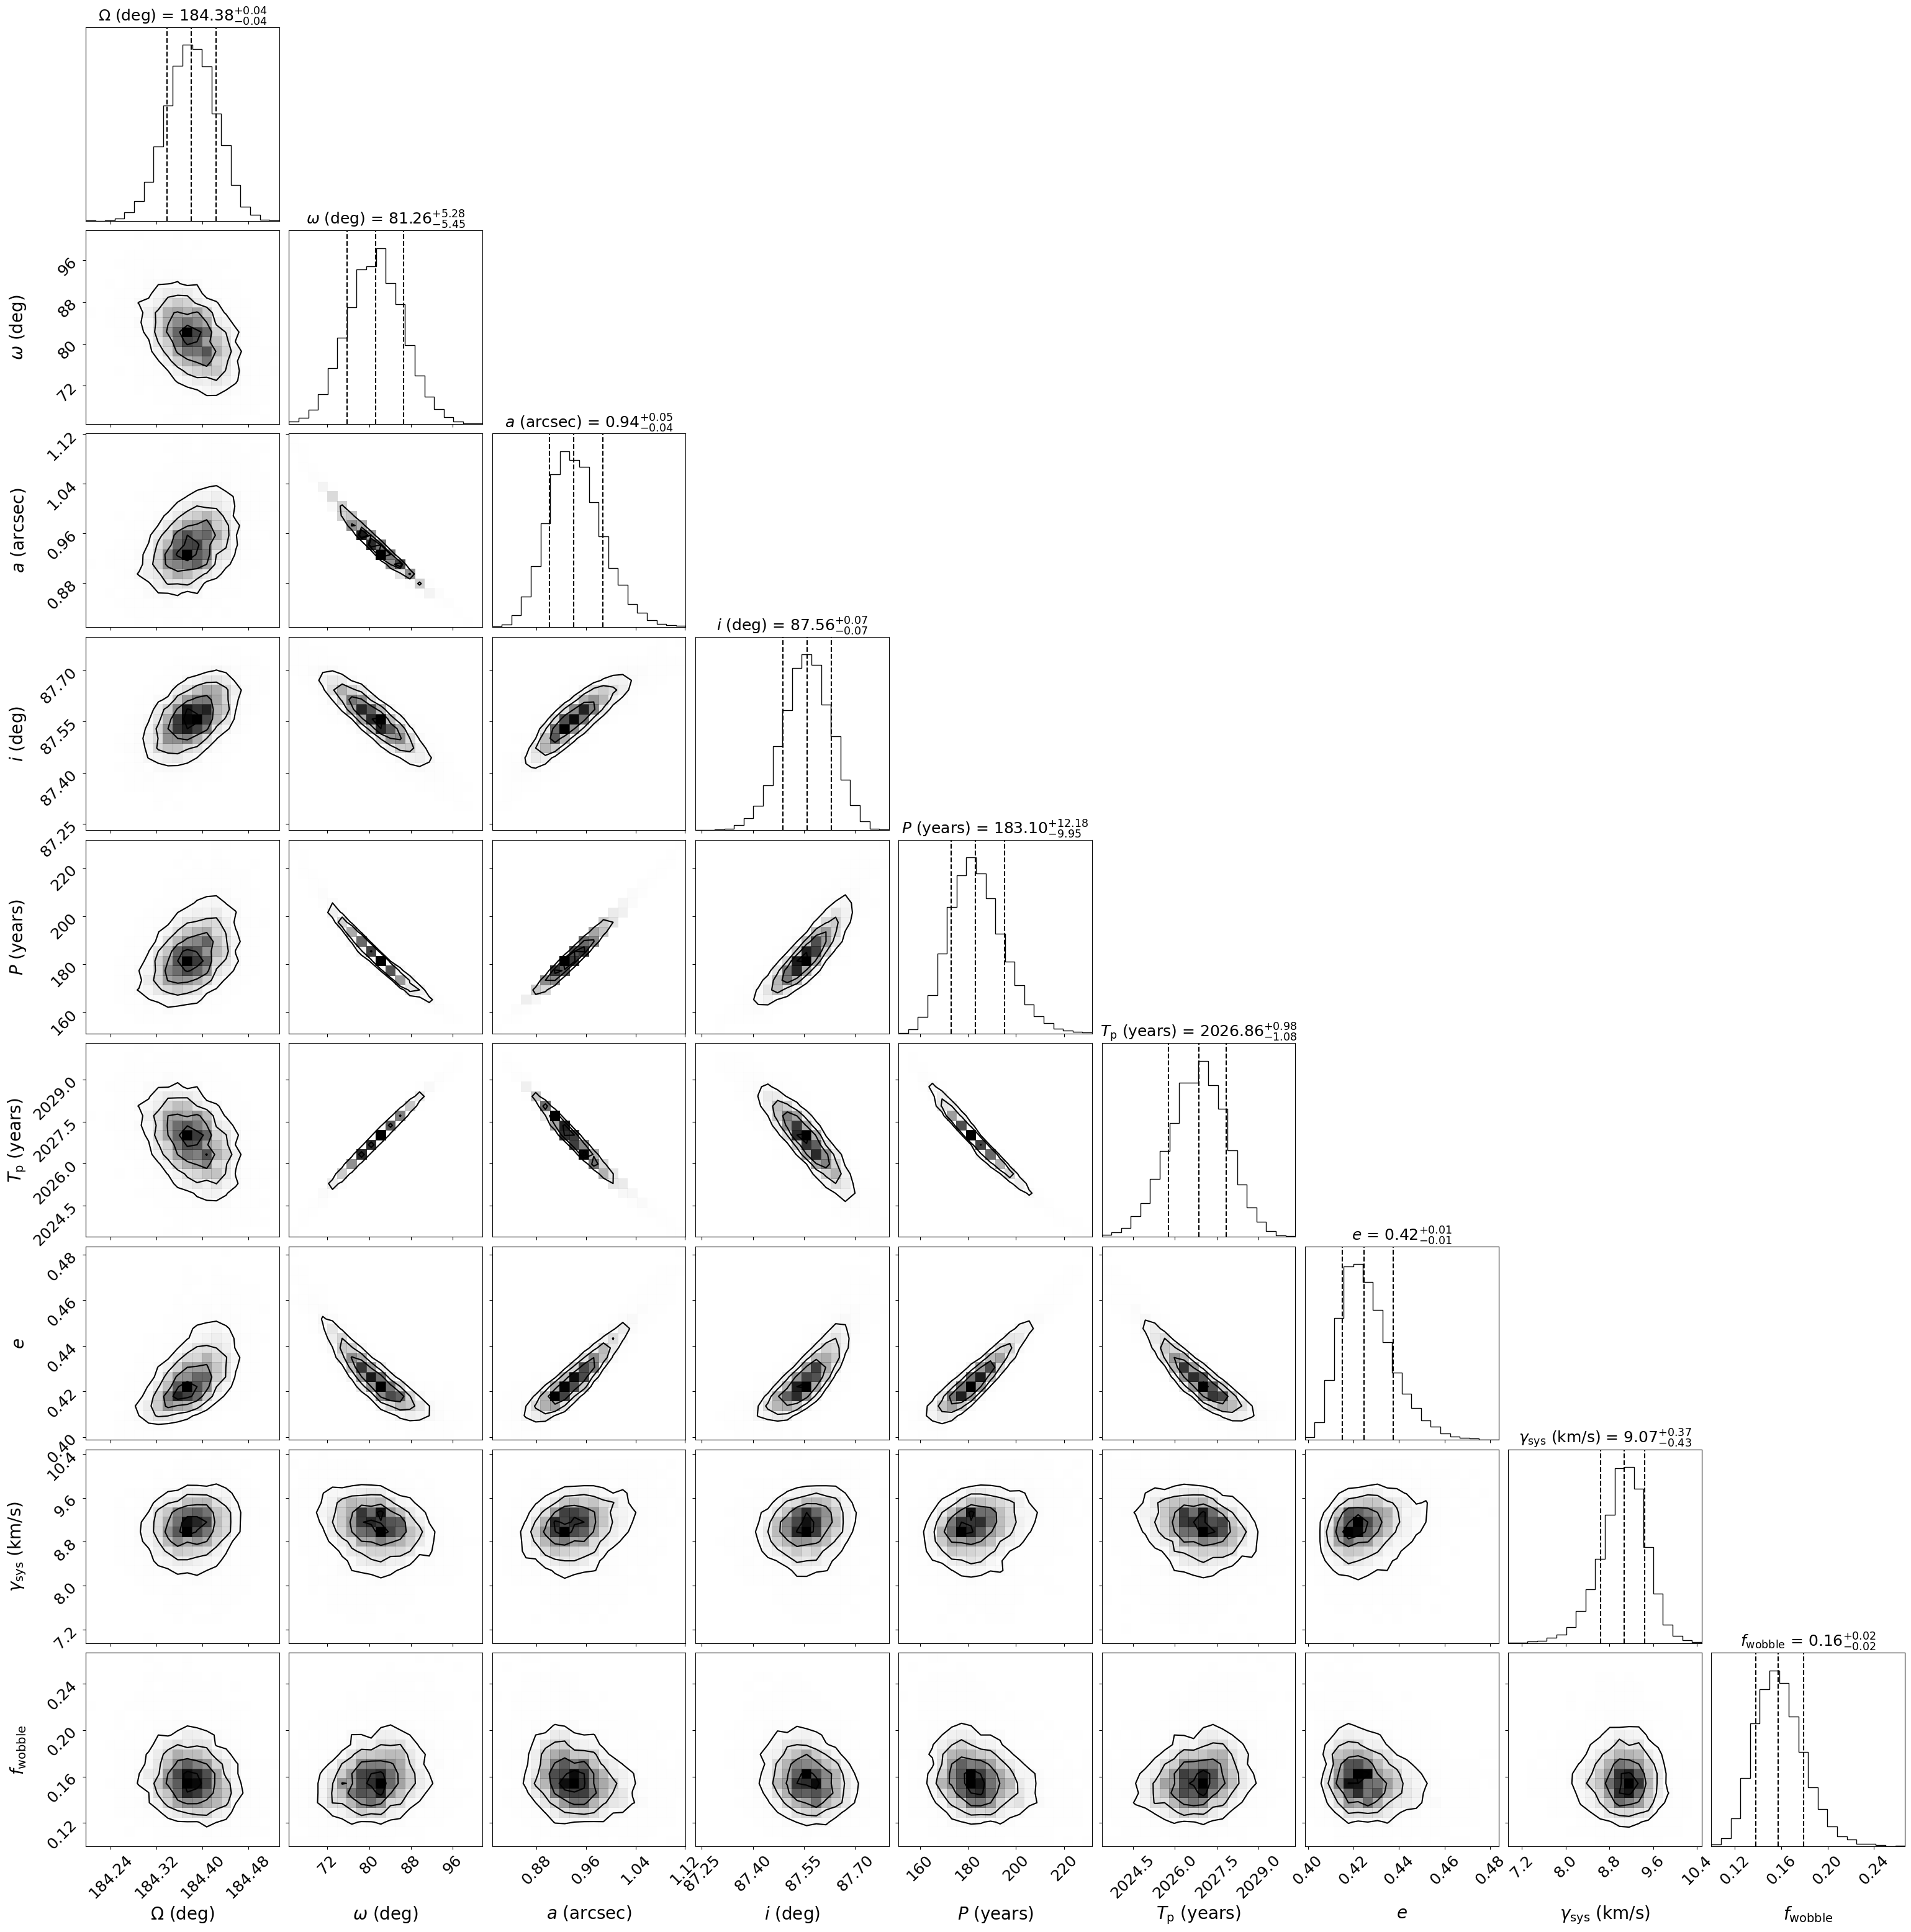

In [16]:
# ============================================================
# OUTER ORBIT POSTERIOR / CORNER PLOT
# ============================================================

samples_outer = pm.trace_to_dataframe(
    trace,
    varnames=[
        "Omega_outer",
        "omega_outer",
        "a_ang_outer",
        "incl_outer",
        "P_outer",
        "tp_outer",
        "ecc_outer",
        "gamma_sys",
        "f_wobble",
    ]
)

# ------------------------------------------------------------
# Transform posterior variables into plotting quantities
# ------------------------------------------------------------

samples_outer[r"$\Omega$ (deg)"] = (
    trace["Omega_outer"] / deg
) % 360

samples_outer[r"$\omega$ (deg)"] = (
    trace["omega_outer"] / deg
) % 360

samples_outer[r"$a$ (arcsec)"] = (
    trace["a_ang_outer"]
)

samples_outer[r"$i$ (deg)"] = (
    trace["incl_outer"] / deg
) % 180

samples_outer[r"$P$ (years)"] = (
    trace["P_outer"] / yr
)

samples_outer[r"$T_{\mathrm{p}}$ (years)"] = (
    Time(
        np.ascontiguousarray(trace["tp_outer"]),
        format="jd"
    ).byear
)

samples_outer[r"$e$"] = (
    trace["ecc_outer"]
)

samples_outer[r"$\gamma_{\mathrm{sys}}$ (km/s)"] = (
    trace["gamma_sys"]
)

samples_outer[r"$f_{\mathrm{wobble}}$"] = (
    trace["f_wobble"]
)


# ============================================================
# POSTERIOR MEDIANS AND UNCERTAINTIES
# ============================================================

period, period_s = get_median_sigma(
    samples_outer[r"$P$ (years)"]
)

print("Period (years): " + fmt(period, period_s))


tp, tp_s = get_median_sigma(
    samples_outer[r"$T_{\mathrm{p}}$ (years)"]
)

print("Tp (years): " + fmt(tp, tp_s))


omega, omega_s = get_median_sigma(
    (trace["omega_outer"] * rad_2_deg) % 360
)

print("omega (deg): " + fmt(omega, omega_s))


Omega, Omega_s = get_median_sigma(
    (trace["Omega_outer"] * rad_2_deg) % 360
)

print("Omega (deg): " + fmt(Omega, Omega_s))


inc, inc_s = get_median_sigma(
    (trace["incl_outer"] * rad_2_deg) % 180
)

print("i (deg): " + fmt(inc, inc_s))


aang, aang_s = get_median_sigma(
    trace["a_ang_outer"]
)

print("a (arcsec): " + fmt(aang, aang_s))


ecc, ecc_s = get_median_sigma(
    trace["ecc_outer"]
)

print("e: " + fmt(ecc, ecc_s))


gamma, gamma_s = get_median_sigma(
    trace["gamma_sys"]
)

print("gamma_sys (km/s): " + fmt(gamma, gamma_s))


fw, fw_s = get_median_sigma(
    trace["f_wobble"]
)

print("f_wobble: " + fmt(fw, fw_s))


# ============================================================
# CLEAN DATAFRAME FOR CORNER
# ============================================================

raw_variables = [
    "Omega_outer",
    "omega_outer",
    "a_ang_outer",
    "incl_outer",
    "P_outer",
    "tp_outer",
    "ecc_outer",
    "gamma_sys",
    "f_wobble",
]

for var in raw_variables:
    if var in samples_outer.columns:
        del samples_outer[var]


# ============================================================
# CORNER PLOT
# ============================================================

figure = corner.corner(
    samples_outer,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 18},
    label_kwargs={"fontsize": 20},
    plot_datapoints=False
)

figure.subplots_adjust(
    right=1.5,
    top=1.5
)

for ax in figure.get_axes():
    ax.tick_params(
        axis="both",
        labelsize=18
    )


# Optional time limits for future plotting
xlim_min = tp - period
xlim_max = tp + period


# ============================================================
# SAVE RESULTS
# ============================================================

figure.savefig(
    "Plots/AaAbB_outer_corner.pdf",
    dpi=300,
    pad_inches=0.3,
    bbox_inches="tight"
)

samples_outer.to_csv(
    "CSV/AaAbB_outer_posterior.csv",
    index=False
)

Period (days): 264.512$\pm$0.034
Tp (MJD): 48738.5$\pm$1.8
omega (deg): 62.3$\pm$3.0
Omega (deg): 181.6$\pm$4.7
i (deg): 133.0$\pm$7.6
a (mas): 18.82$\pm$0.96
e: 0.489$\pm$0.016
K1 (km/s): 6.95$\pm$0.17
M_Ab (Msun): 0.290$\pm$0.033
M_Aa (Msun): 0.94$\pm$0.18
M_AaAb (Msun): 1.24$\pm$0.19
Pandas support in corner is deprecated; use ArviZ directly


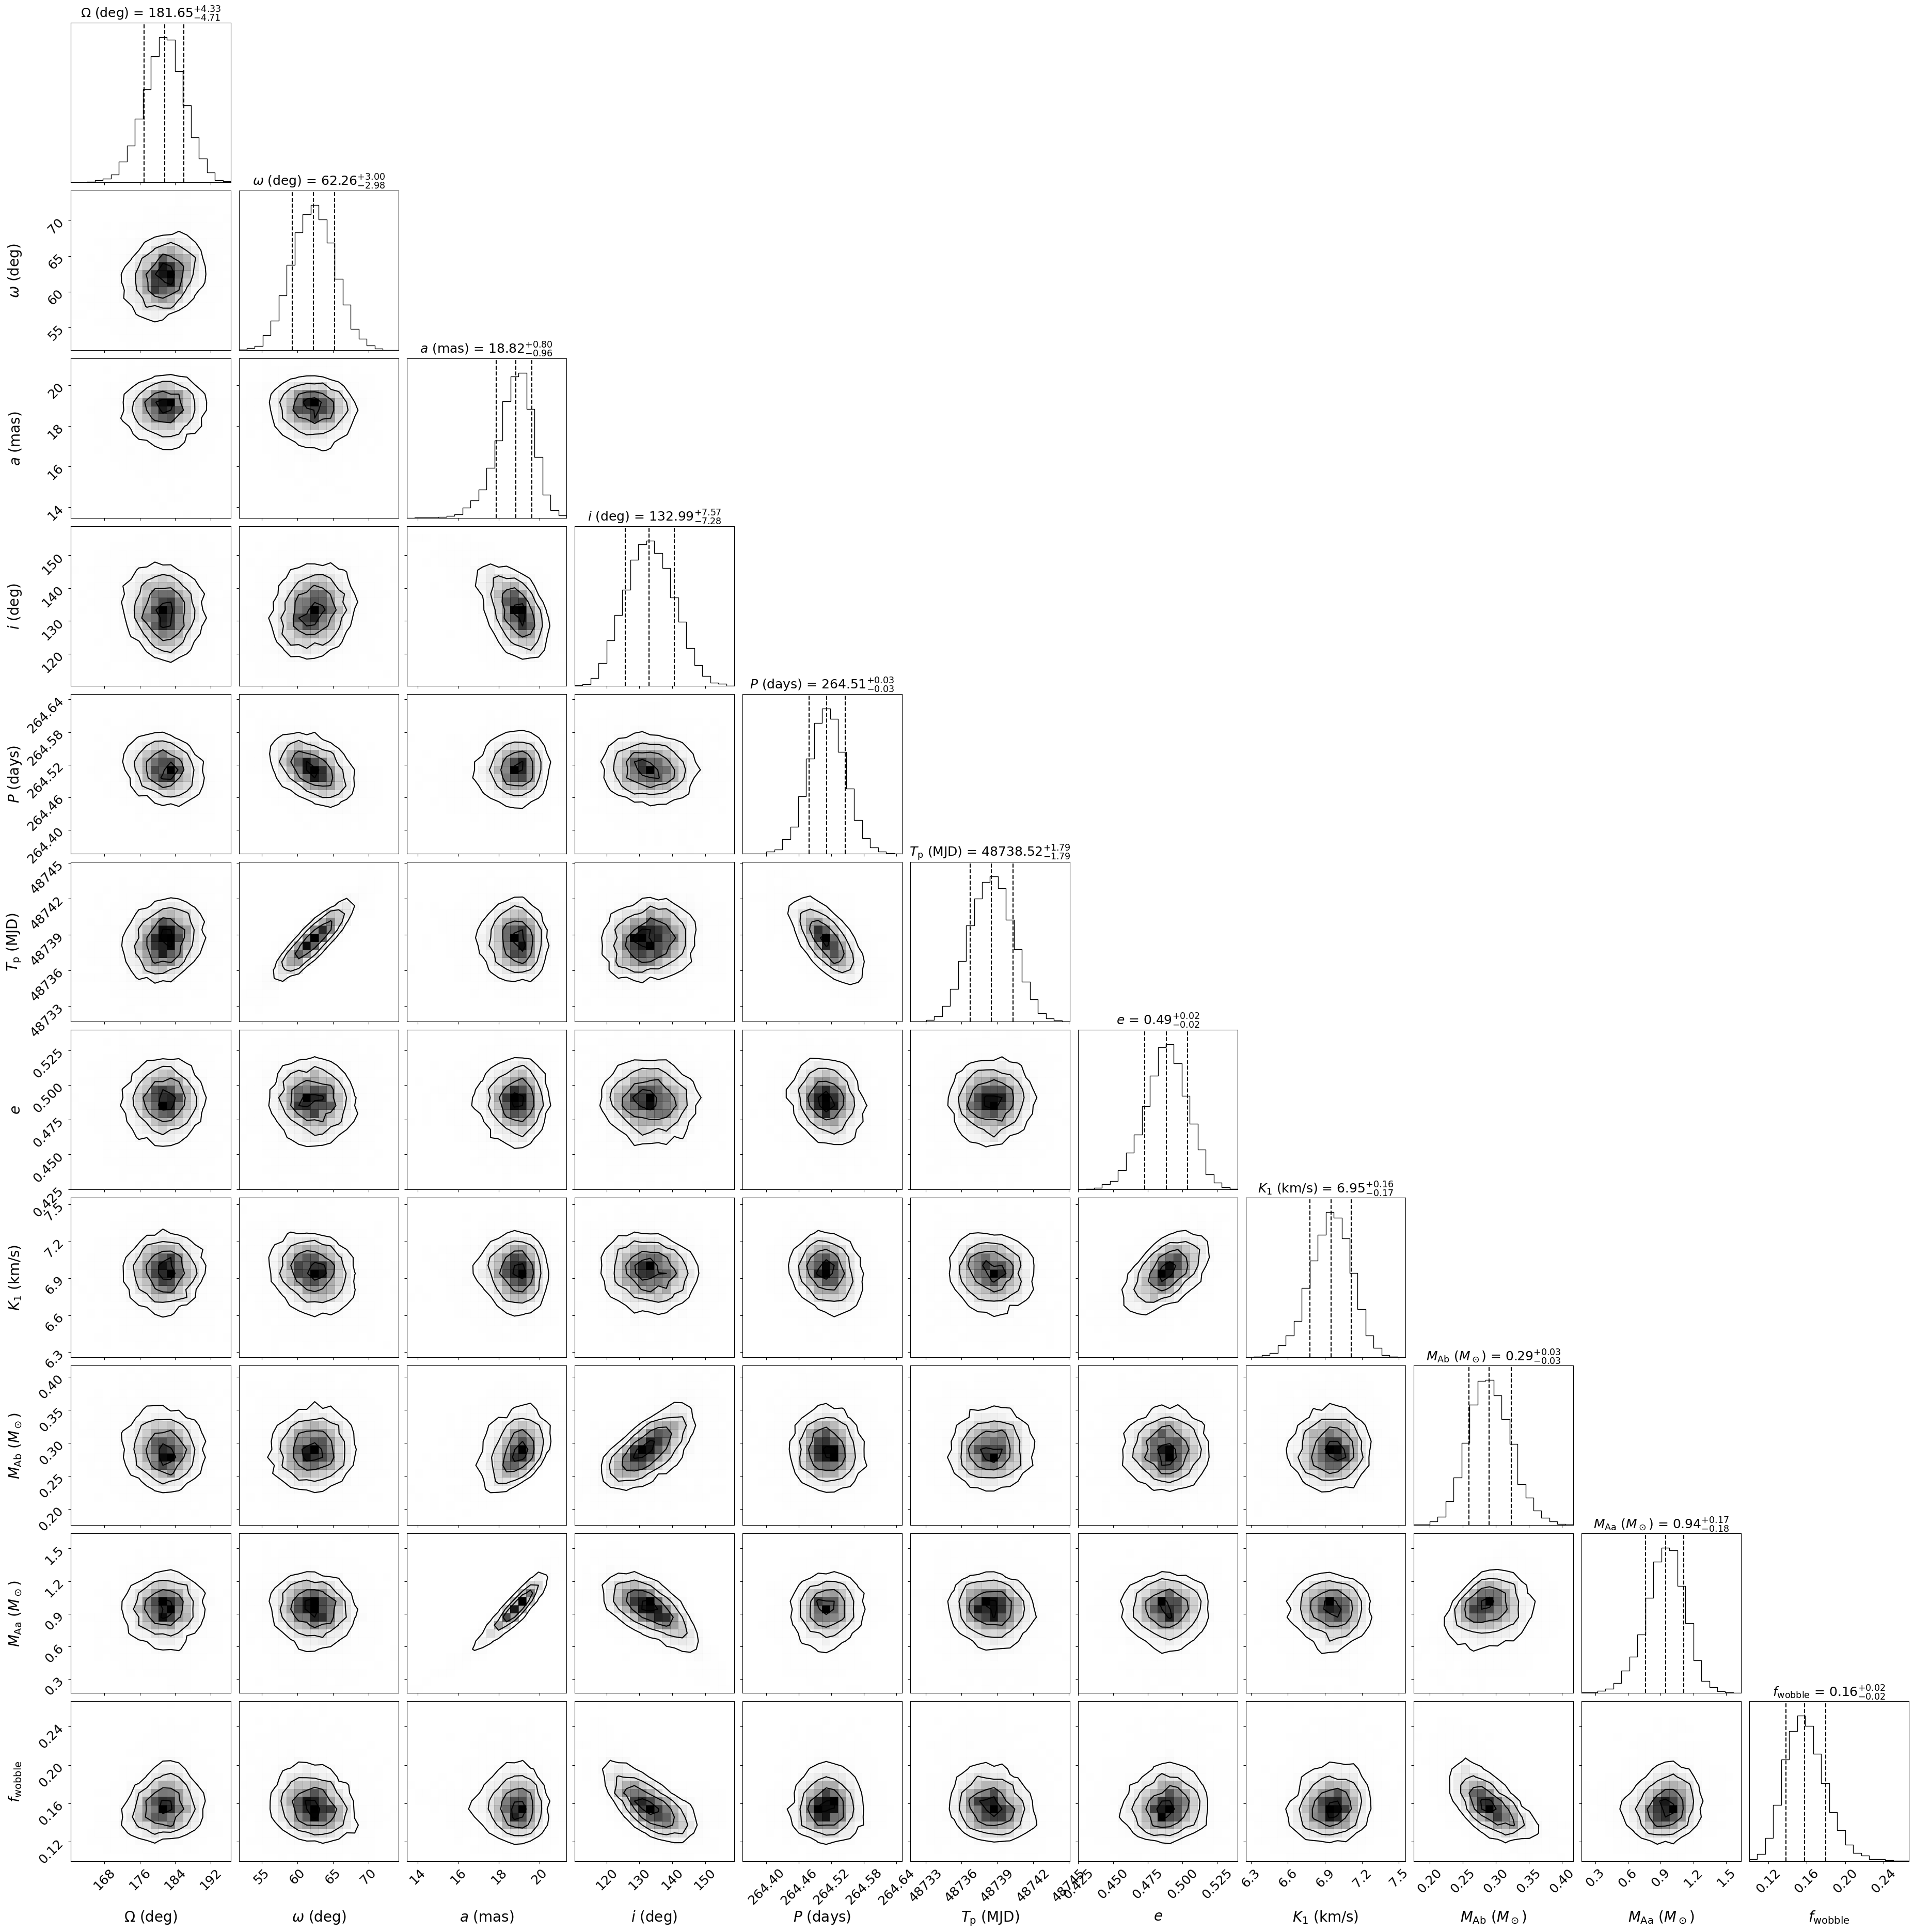

In [22]:
# ============================================================
# INNER ORBIT POSTERIOR / CORNER PLOT
# ============================================================

samples_inner = pm.trace_to_dataframe(
    trace,
    varnames=[
        "Omega",
        "omega",
        "a_ang",
        "incl",
        "P",
        "tp",
        "ecc",
        "K1",
        "M_2",
        "M_Aa",
        "M_t",
        "f_wobble",
    ]
)


# ------------------------------------------------------------
# Transform posterior variables into plotting quantities
# ------------------------------------------------------------

samples_inner[r"$\Omega$ (deg)"] = (
    trace["Omega"] / deg
) % 360

samples_inner[r"$\omega$ (deg)"] = (
    trace["omega"] / deg
) % 360

samples_inner[r"$a$ (mas)"] = (
    trace["a_ang"] * 1000
)

samples_inner[r"$i$ (deg)"] = (
    trace["incl"] / deg
) % 180

samples_inner[r"$P$ (days)"] = (
    trace["P"]
)

samples_inner[r"$T_{\mathrm{p}}$ (MJD)"] = (
    trace["tp"] - 2400000.5
)

samples_inner[r"$e$"] = (
    trace["ecc"]
)

samples_inner[r"$K_1$ (km/s)"] = (
    trace["K1"]
)

samples_inner[r"$M_{\mathrm{Ab}}$ ($M_\odot$)"] = (
    trace["M_2"]
)

samples_inner[r"$M_{\mathrm{Aa}}$ ($M_\odot$)"] = (
    trace["M_Aa"]
)

#samples_inner[r"$M_{\mathrm{AaAb}}$ ($M_\odot$)"] = (
#    trace["M_t"]
#)

samples_inner[r"$f_{\mathrm{wobble}}$"] = (
    trace["f_wobble"]
)


# ============================================================
# POSTERIOR MEDIANS AND UNCERTAINTIES
# ============================================================

period_inner, period_inner_s = get_median_sigma(
    samples_inner[r"$P$ (days)"]
)

print("Period (days): " + fmt(period_inner, period_inner_s))


tp_inner, tp_inner_s = get_median_sigma(
    samples_inner[r"$T_{\mathrm{p}}$ (MJD)"]
)

print("Tp (MJD): " + fmt(tp_inner, tp_inner_s))


omega_inner, omega_inner_s = get_median_sigma(
    (trace["omega"] * rad_2_deg) % 360
)

print("omega (deg): " + fmt(omega_inner, omega_inner_s))


Omega_inner, Omega_inner_s = get_median_sigma(
    (trace["Omega"] * rad_2_deg) % 360
)

print("Omega (deg): " + fmt(Omega_inner, Omega_inner_s))


inc_inner, inc_inner_s = get_median_sigma(
    (trace["incl"] * rad_2_deg) % 180
)

print("i (deg): " + fmt(inc_inner, inc_inner_s))


aang_inner, aang_inner_s = get_median_sigma(
    trace["a_ang"] * 1000
)

print("a (mas): " + fmt(aang_inner, aang_inner_s))


ecc_inner, ecc_inner_s = get_median_sigma(
    trace["ecc"]
)

print("e: " + fmt(ecc_inner, ecc_inner_s))


K1_inner, K1_inner_s = get_median_sigma(
    trace["K1"]
)

print("K1 (km/s): " + fmt(K1_inner, K1_inner_s))


M_Ab, M_Ab_s = get_median_sigma(
    trace["M_2"]
)

print("M_Ab (Msun): " + fmt(M_Ab, M_Ab_s))


M_Aa, M_Aa_s = get_median_sigma(
    trace["M_Aa"]
)

print("M_Aa (Msun): " + fmt(M_Aa, M_Aa_s))


M_AaAb, M_AaAb_s = get_median_sigma(
    trace["M_t"]
)

print("M_AaAb (Msun): " + fmt(M_AaAb, M_AaAb_s))


# ============================================================
# CLEAN DATAFRAME FOR CORNER
# ============================================================

raw_variables = [
    "Omega",
    "omega",
    "a_ang",
    "incl",
    "P",
    "tp",
    "ecc",
    "K1",
    "M_2",
    "M_Aa",
    "M_t",
    "f_wobble"
]

for var in raw_variables:
    if var in samples_inner.columns:
        del samples_inner[var]


# ============================================================
# CORNER PLOT
# ============================================================

figure_inner = corner.corner(
    samples_inner,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 18},
    label_kwargs={"fontsize": 20},
    plot_datapoints=False
)

figure_inner.subplots_adjust(
    right=1.5,
    top=1.5
)

for ax in figure_inner.get_axes():
    ax.tick_params(
        axis="both",
        labelsize=18
    )


# ============================================================
# SAVE RESULTS
# ============================================================

figure_inner.savefig(
    "Plots/AaAbB_inner_corner.pdf",
    dpi=300,
    pad_inches=0.3,
    bbox_inches="tight"
)

samples_inner.to_csv(
    "CSV/AaAbB_inner_posterior.csv",
    index=False
)

MA (Msun): 1.24$\pm$0.19
MB (Msun): 1.18$\pm$0.18
KA (km/s): 3.78$\pm$0.57
KB (km/s): 3.98$\pm$0.59
Parallax (mas): 21.76$\pm$0.34
a_outer (AU): 43.2$\pm$2.2
Distance (pc): 45.95$\pm$0.73
Pandas support in corner is deprecated; use ArviZ directly


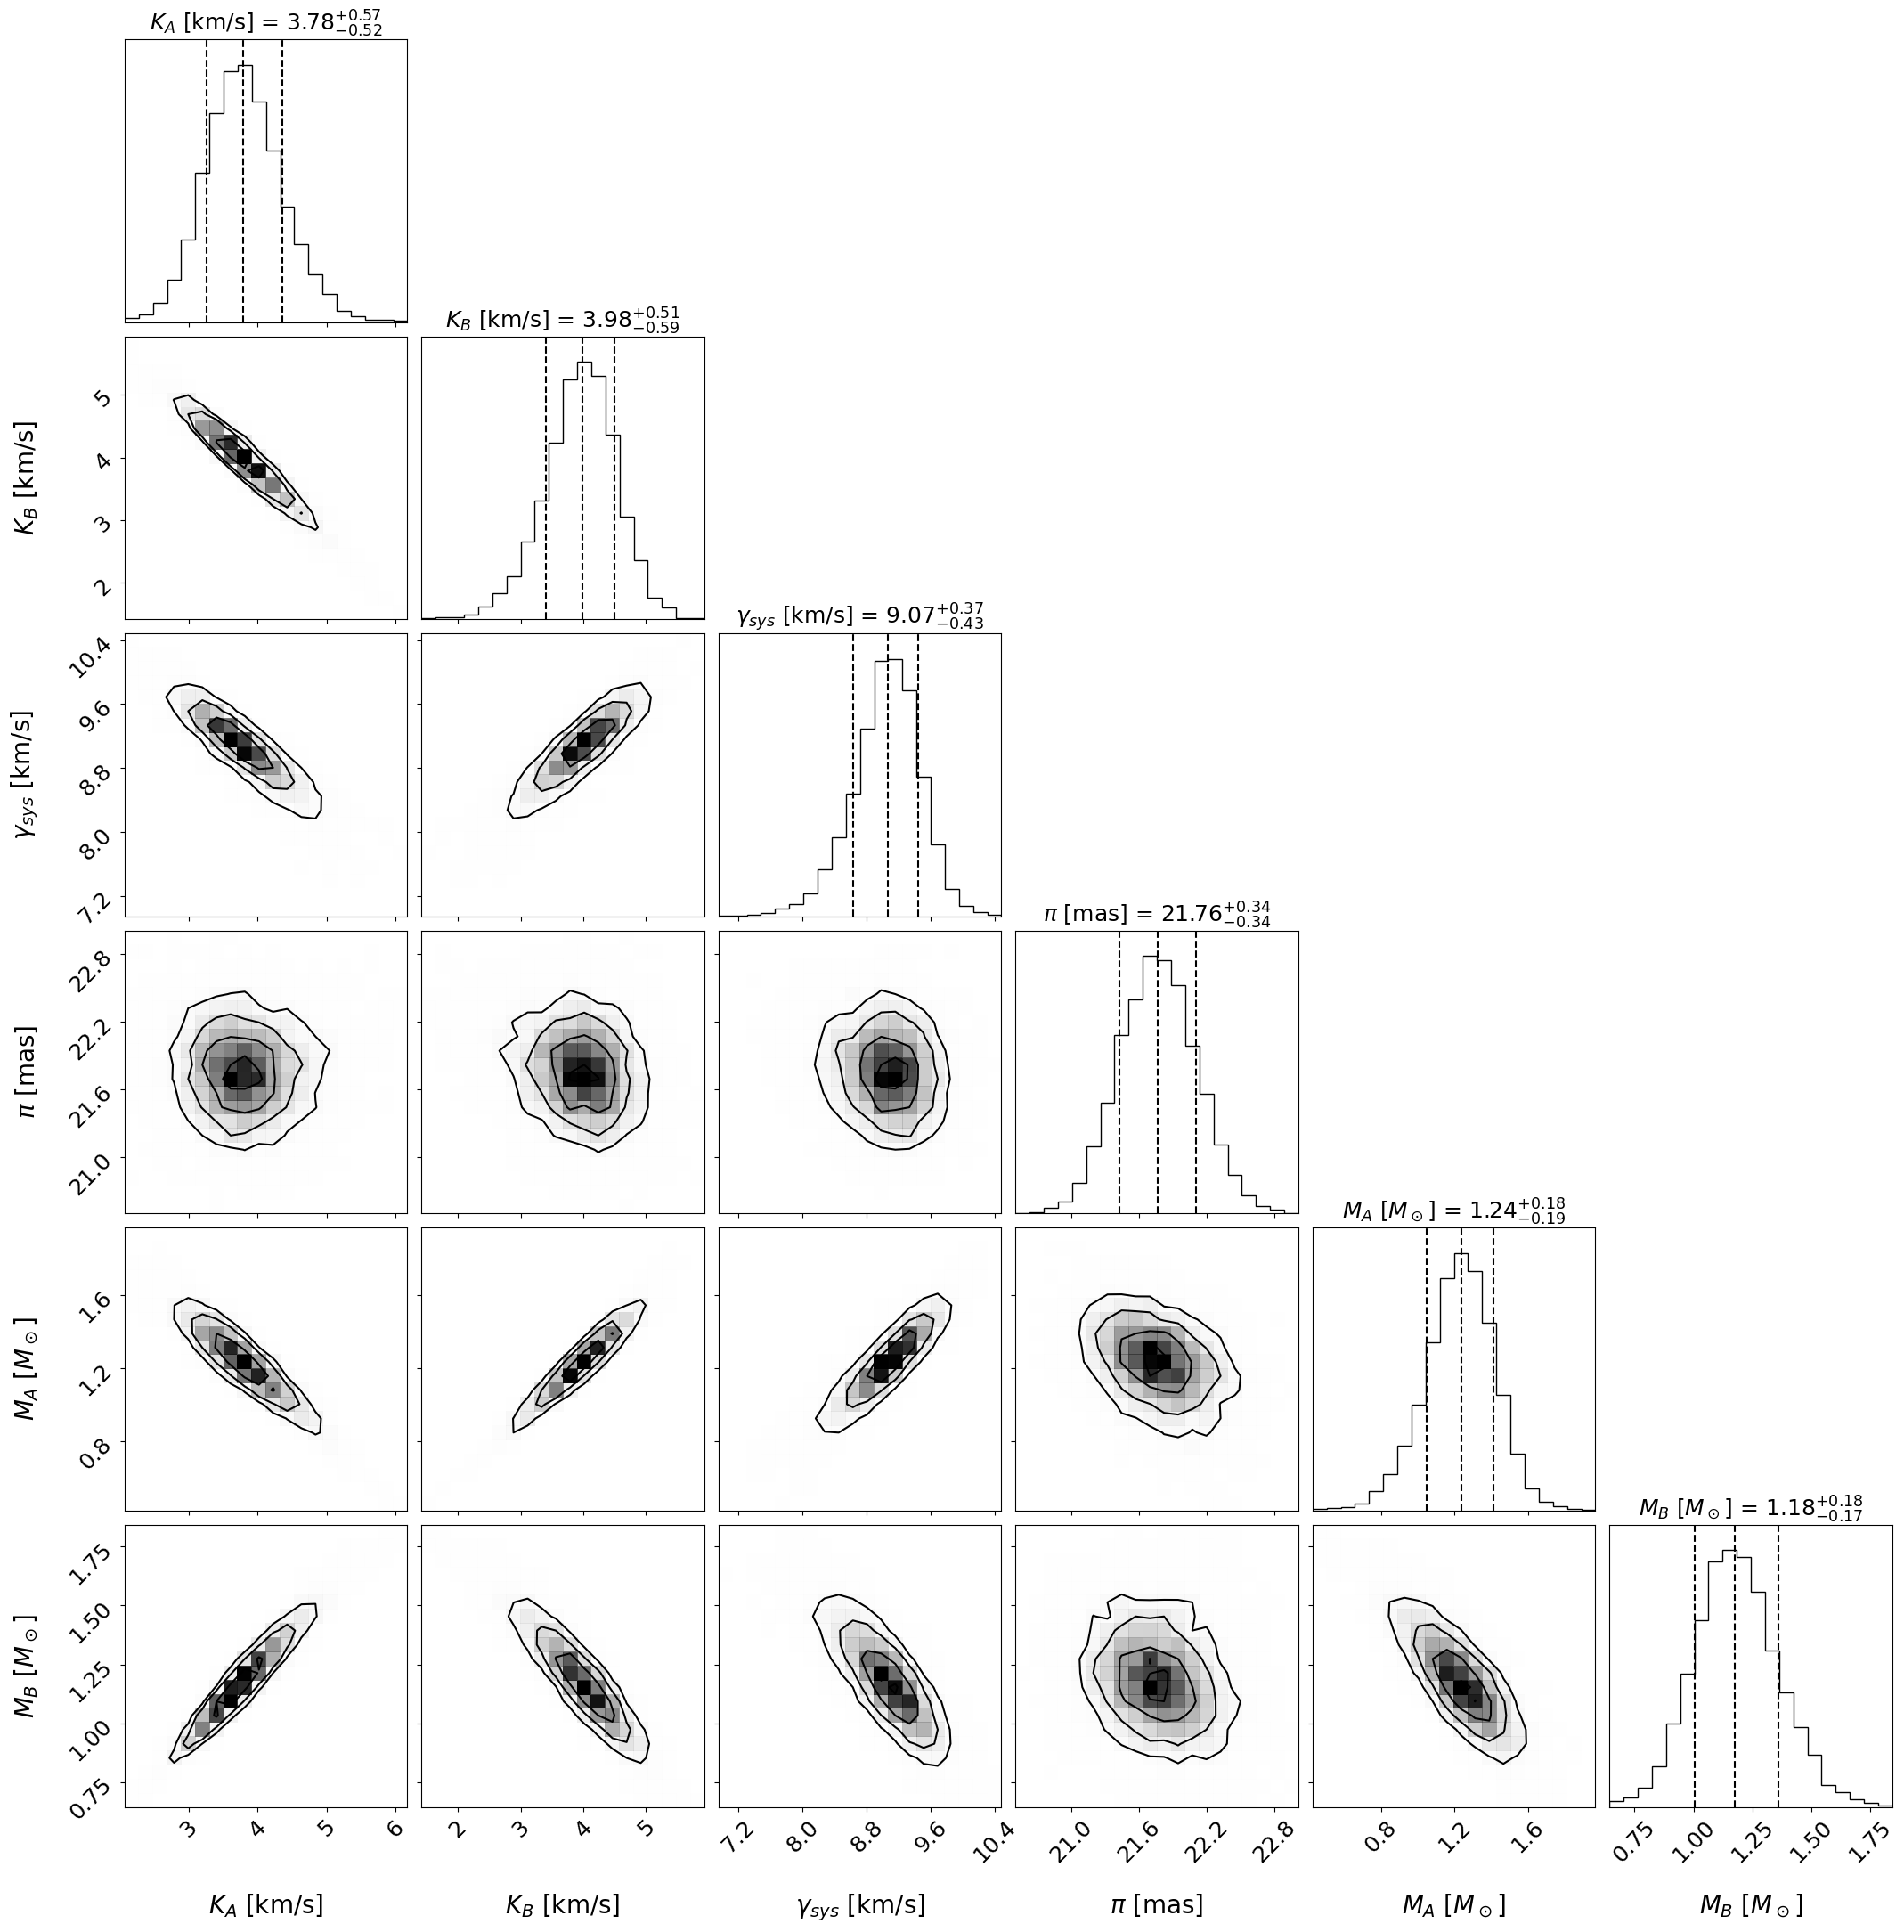

In [19]:
# Extract posterior samples
samples = pm.trace_to_dataframe(
    trace,
    varnames=[
        "Omega_outer",
        "K1_outer",
        "K2_outer",
        "gamma_sys",
        "m_plx_outer",
        "MA_outer",
        "MB_outer",
    ],
)

# ---------------------------------------------------------
# Orbital parameters
# ---------------------------------------------------------

samples["$\\Omega$ [deg]"] = (
    trace["Omega_outer"] / deg
) % 360

# If needed:
# samples["$\\omega$ [deg]"] = (
#     trace["omega_outer"] / deg
# ) % 360

# ---------------------------------------------------------
# RV parameters
# ---------------------------------------------------------

samples["$K_A$ [km/s]"] = trace["K1_outer"]

samples["$K_B$ [km/s]"] = trace["K2_outer"]

samples["$\\gamma_{sys}$ [km/s]"] = trace["gamma_sys"]

# ---------------------------------------------------------
# Parallax
# ---------------------------------------------------------

samples["$\\pi$ [mas]"] = trace["m_plx_outer"]

# ---------------------------------------------------------
# Masses
# ---------------------------------------------------------

samples["$M_A$ [$M_\\odot$]"] = trace["MA_outer"]

samples["$M_B$ [$M_\\odot$]"] = trace["MB_outer"]

# ---------------------------------------------------------
# Posterior statistics
# ---------------------------------------------------------

MA_b, MA_b_s = get_median_sigma(trace["MA_outer"])
print("MA (Msun): " + fmt(MA_b, MA_b_s))

MB_b, MB_b_s = get_median_sigma(trace["MB_outer"])
print("MB (Msun): " + fmt(MB_b, MB_b_s))

KA_b, KA_b_s = get_median_sigma(trace["K1_outer"])
print("KA (km/s): " + fmt(KA_b, KA_b_s))

KB_b, KB_b_s = get_median_sigma(trace["K2_outer"])
print("KB (km/s): " + fmt(KB_b, KB_b_s))

plx_b, plx_b_s = get_median_sigma(trace["m_plx_outer"])
print("Parallax (mas): " + fmt(plx_b, plx_b_s))

# ---------------------------------------------------------
# Physical semimajor axis
# ---------------------------------------------------------

a_b, a_b_s = get_median_sigma(trace["a_outer"])
print("a_outer (AU): " + fmt(a_b, a_b_s))

# ---------------------------------------------------------
# Distance
# ---------------------------------------------------------

dist_pc, dist_pc_s = get_median_sigma(
    1 / (trace["m_plx_outer"] / 1000)
)

print("Distance (pc): " + fmt(dist_pc, dist_pc_s))

# ---------------------------------------------------------
# Remove auxiliary parameter from corner plot
# ---------------------------------------------------------

del samples["$\\Omega$ [deg]"]

# ---------------------------------------------------------
# Save selected posterior distributions
# ---------------------------------------------------------

prior_dist = samples[
    [
        "$\\pi$ [mas]",
        "$M_A$ [$M_\\odot$]",
        "$M_B$ [$M_\\odot$]",
    ]
]

prior_dist.to_csv(
    "CSV/mass_plx.csv",
    index=False
)

# ============================================================
# CLEAN DATAFRAME FOR CORNER
# ============================================================

raw_variables = [
    "Omega_outer",
    "K1_outer",
    "K2_outer",
    "gamma_sys",
    "m_plx_outer",
    "MA_outer",
    "MB_outer",
]

for var in raw_variables:
    if var in samples.columns:
        del samples[var]

# ---------------------------------------------------------
# Corner plot
# ---------------------------------------------------------

figure = corner.corner(
    samples,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 18},
    label_kwargs={"fontsize": 20},
    plot_datapoints=False,
)

figure.subplots_adjust(
    right=1.5,
    top=1.5
)

for ax in figure.get_axes():
    ax.tick_params(
        axis="both",
        labelsize=18
    )

# ---------------------------------------------------------
# Save figures and complete posterior
# ---------------------------------------------------------

figure.savefig(
    "Plots/AaAbB_corner_Mass_plx_RVs.pdf",
    dpi=300,
    pad_inches=0.3,
    bbox_inches="tight"
)

samples.to_csv(
    "CSV/AaAbB_posterior_Mass_plx_RVs.csv",
    index=False
)

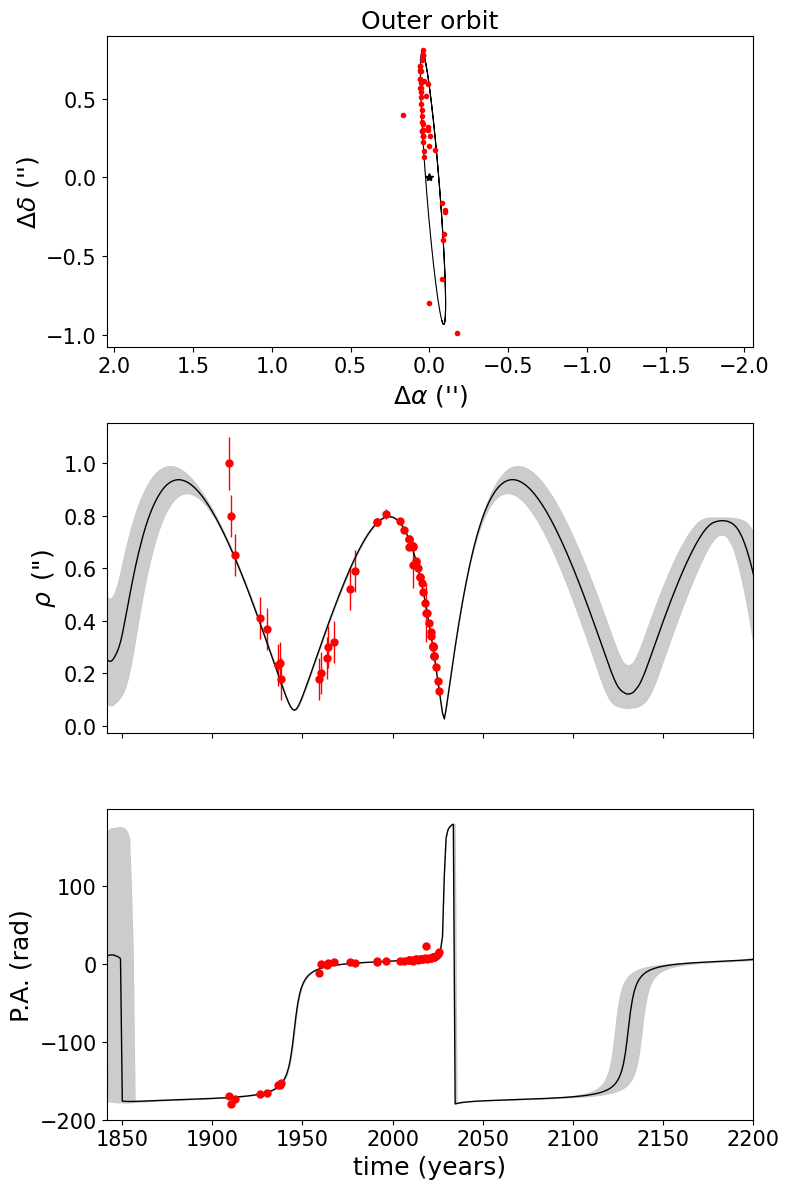

In [46]:

# --- reconstruct the time grid for the physical-separation track ---
r_save_au = np.percentile(trace["r_save_t1"], [16, 50, 84], axis=0)
n_r = r_save_au.shape[1]
t_fine_r = t_fine_xy
t_yr_r   = Time(np.ascontiguousarray(t_fine_r), format='jd').byear

# --- large-uncertainty solution ---
df_r_large = pd.DataFrame({
    'JD'      : t_fine_r,
    'year'    : t_yr_r,
    'r_lo_au' : r_save_au[0],
    'r_med_au': r_save_au[1],
    'r_hi_au' : r_save_au[2],
})

#df_r_large.to_csv('CSV/AB_orbit_r_large.csv', index=False)


period = np.percentile(trace["P"], [16, 50, 84], axis=0)
gamma = np.percentile(trace["gamma"], [16, 50, 84], axis = 0)

theta_save = np.percentile(trace['thetaSaveSky'], [16, 50, 84], axis = 0)
rho_save = np.percentile(trace['rhoSaveSky'], [16, 50, 84], axis = 0)

RV1_save = np.percentile(trace['RV1Dense'], [16, 50, 84], axis = 0)
RV2_save = np.percentile(trace['RV2Dense'], [16, 50, 84], axis = 0)


qx = np.percentile(trace["x_save"], [16, 50, 84], axis=0)
qy = np.percentile(trace["y_save"], [16, 50, 84], axis=0)

#x_2025_large = np.percentile(trace["x_2025_large"], [16, 50, 84], axis=0)
#y_2025_large = np.percentile(trace["y_2025_large"], [16, 50, 84], axis=0)

#x_2026_large = np.percentile(trace["x_2026_large"], [16, 50, 84], axis=0)
#y_2026_large = np.percentile(trace["y_2026_large"], [16, 50, 84], axis=0)

# Plot the orbit
fig, ax = plt.subplots(nrows=3, sharex=False, figsize=(8, 12))

xs = qx[1]  # X is north
ys = qy[1]  # Y is east
ax[0].plot(xs,ys, color="k", lw=0.1)


ax[0].scatter(yd, xd, marker=".", color ='r', zorder=3)

# 1 sigma orbit range
#ax[0].fill(qx[2], qy[2], color="k", lw=0.2, alpha = 0.2)
#plt.fill(Rinner*rs[:,0], Rinner*rs[:,1], "White")
ax[0].plot(qx[1], qy[1], color="k", lw=0.8, zorder = 2)
#ax[0].plot(qx[2], qy[2], color="g", lw=0.8, zorder = 2)
#ax[0].plot(qx[0], qy[0], color="g", lw=0.8, zorder = 2)


ax[0].set_ylabel(r"$\Delta \delta$ ('')", fontsize=18)
ax[0].set_xlabel(r"$\Delta \alpha$ ('')", fontsize=18)
ax[0].invert_xaxis()
ax[0].plot(0, 0, "k*")
ax[0].set_aspect("equal", "datalim")
ax[0].set_title("Outer orbit", fontsize=18)
#ax.legend(loc='upper left', prop={'size': 12})
#print(astrometry_PA[2])
#plt.setp(ax[0],ylim=[-0.8,0.8])

plt.tight_layout()


# Decimal year format
t_fine_y = Time(np.ascontiguousarray(t_fine), format="jd").byear

ax[1].errorbar(astrometry_AB['date'], rho_data, yerr=rho_err, fmt="or", lw=1, ms=5)
ax[1].fill_between(t_fine_y, rho_save[0], rho_save[2], color="k", lw=0.2, alpha = 0.2)
ax[1].plot(t_fine_y, rho_save[1], color="k", lw=1)
ax[1].set_ylabel(r'$\rho\,$ (")', fontsize=18)
plt.setp(ax[1],xlim=[xlim_min,2200])
ax[1].tick_params(labelbottom=False)

ax[2].errorbar(astrometry_AB['date'], theta_data * rad_2_deg, yerr=theta_err * rad_2_deg, fmt="or", lw=1, ms=5)
ax[2].fill_between(t_fine_y, theta_save[0]*rad_2_deg, theta_save[2]*rad_2_deg, color="k", lw=0.2, alpha = 0.2)
ax[2].plot(t_fine_y, theta_save[1] * rad_2_deg, color="k", lw=1)
ax[2].set_ylabel(r"P.A. (rad)", fontsize=18)
_ = ax[2].set_xlabel("time (years)", fontsize=18)
plt.setp(ax[2],xlim=[xlim_min,2200])

plt.tight_layout()

plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

#plt.savefig('AB_Orbit_2026.pdf')  


plt.show()

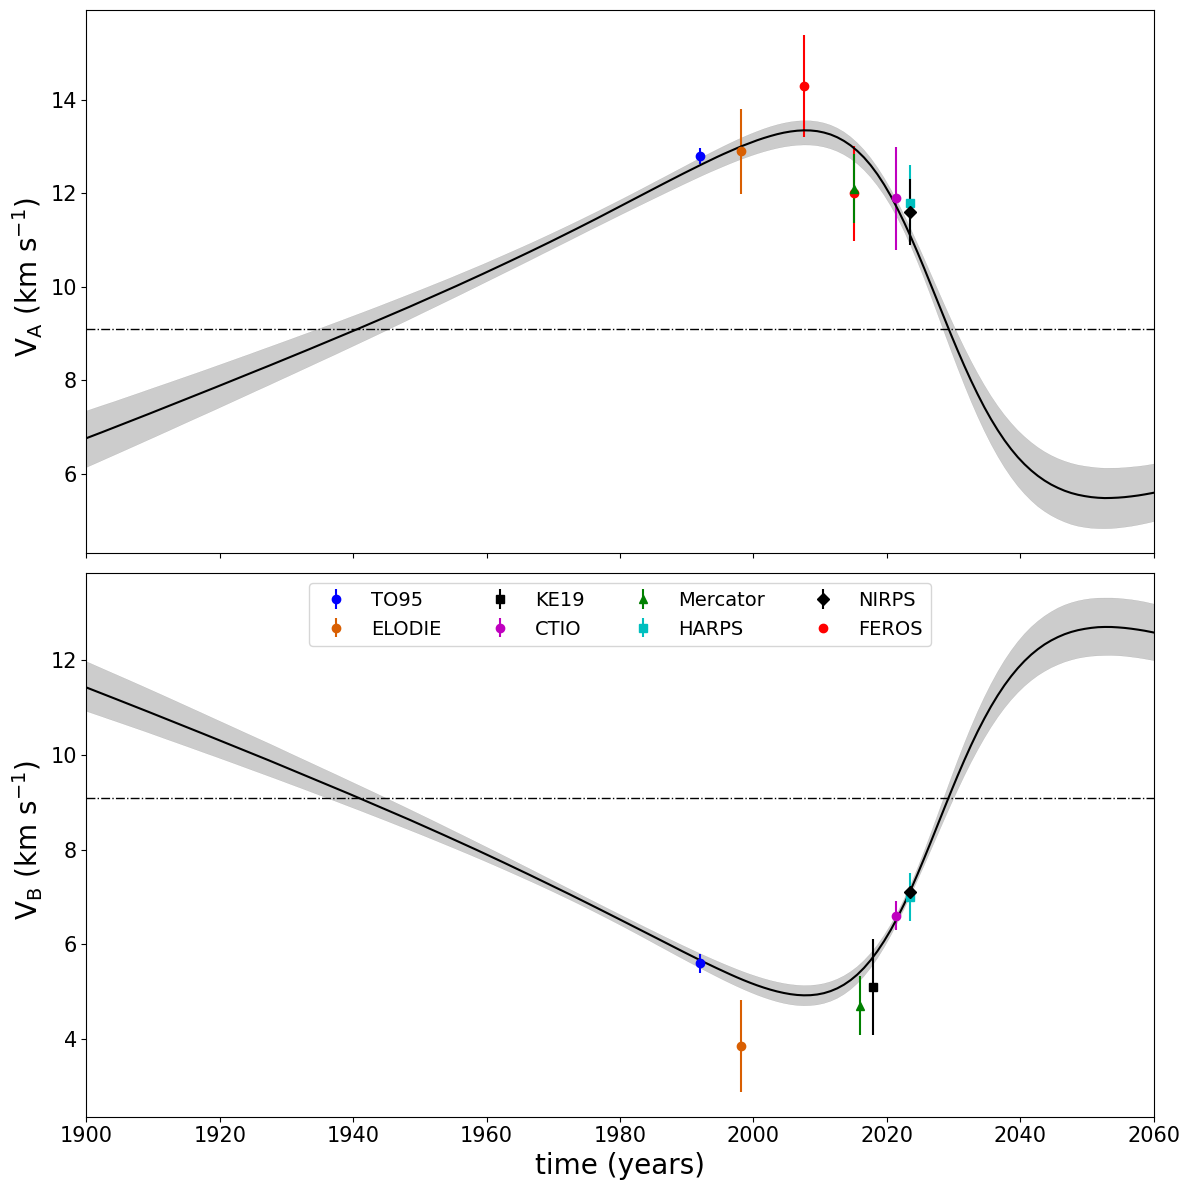

In [48]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(12, 12))

def scaled_err(rv_err, jitter_name):
    return np.sqrt(rv_err**2 + np.exp(2 * np.median(trace[jitter_name])))

errA_TO95 = scaled_err(rvA_err[0], "logjitterouter")
errA_ELO = scaled_err(rvA_err[1], "logjitterouter_ELO")
errA_FEROS = scaled_err(rvA_err[2], "logjitterouter_FEROS")
errA_FEROS2 = scaled_err(rvA_err[3], "logjitterouter_FEROS2")
errA_CTIO = scaled_err(rvA_err[4], "logjitterouter_CTIO")
errA_MERCATOR = scaled_err(rvA_err[5], "logjitterouter_MERCATOR")
errA_HARPS = scaled_err(rvA_err[6], "logjitterouter_HARPS")
errA_NIRPS = scaled_err(rvA_err[7], "logjitterouter_NIRPS")

errB_TO95 = scaled_err(rvB_err[0], "logjitterouter")
errB_ELO = scaled_err(rvB_err[1], "logjitterouter_ELO")
errB_K19 = scaled_err(rvB_err[2], "logjitterouter_K19")
errB_CTIO = scaled_err(rvB_err[3], "logjitterouter_CTIO")
errB_MERCATOR = scaled_err(rvB_err[4], "logjitterouter_MERCATOR")
errB_HARPS = scaled_err(rvB_err[5], "logjitterouter_HARPS")
errB_NIRPS = scaled_err(rvB_err[6], "logjitterouter_NIRPS")

ax[0].axhline(gamma[1], color='k', linestyle='dashdot', lw=1)
#TO95
ax[0].errorbar(Time(t_A, format="jd").byear[0], rvA[0], yerr=errA_TO95,
               fmt="ob", lw=1.5, ms=6)
#FEROS
ax[0].errorbar(Time(t_A, format="jd").byear[2], rvA[2], yerr=errA_FEROS,
               fmt="or", lw=1.5, ms=6)
#CTIO
ax[0].errorbar(Time(t_A, format="jd").byear[4], rvA[4], yerr=errA_CTIO,
               fmt="om", lw=1.5, ms=6)
#FEROS2
ax[0].errorbar(Time(t_A, format="jd").byear[3], rvA[3], yerr=errA_FEROS2,
               fmt="or", lw=1.5, ms=6)
#ELODIE
ax[0].errorbar(Time(t_A, format="jd").byear[1], rvA[1], yerr=errA_ELO,
               fmt="o", color="#d95f02", lw=1.5, ms=6)
#Mercator
ax[0].errorbar(Time(t_A, format="jd").byear[5], rvA[5], yerr=errA_MERCATOR,
               fmt="^g", lw=1.5, ms=6)
#HARPS
ax[0].errorbar(Time(t_A, format="jd").byear[6], rvA[6], yerr=errA_HARPS,
               fmt="sc", lw=1.5, ms=6)
#NIRPS
ax[0].errorbar(Time(t_A, format="jd").byear[7], rvA[7], yerr=errA_NIRPS,
               fmt="Dk", lw=1.5, ms=6)

ax[0].fill_between(t_fine_y, RV1_save[0], RV1_save[2], color="k", lw=0.2, alpha = 0.2)
ax[0].plot(t_fine_y, RV1_save[1], color="k")
ax[0].set_ylabel(r"$~\mathrm{V_A}$ ($\mathrm{km~s^{-1}}$)", fontsize=20)

ax[1].axhline(gamma[1], color='k', linestyle='dashdot', lw=1)
ax[1].errorbar(Time(t_B, format="jd").byear[0], rvB[0], yerr=errB_TO95,
               fmt="ob", lw=1.5, ms=6, label='TO95')
ax[1].errorbar(Time(t_B, format="jd").byear[1], rvB[1], yerr=errB_ELO,
               fmt="o", color="#d95f02", lw=1.5, ms=6, label='ELODIE')
ax[1].errorbar(Time(t_B, format="jd").byear[2], rvB[2], yerr=errB_K19,
               fmt="sk", lw=1.5, ms=6, label='KE19')
ax[1].errorbar(Time(t_B, format="jd").byear[3], rvB[3], yerr=errB_CTIO,
               fmt="om", lw=1.5, ms=6, label='CTIO')
ax[1].errorbar(Time(t_B, format="jd").byear[4], rvB[4], yerr=errB_MERCATOR,
               fmt="^g", lw=1.5, ms=6, label='Mercator')
ax[1].errorbar(Time(t_B, format="jd").byear[5], rvB[5], yerr=errB_HARPS,
               fmt="sc", lw=1.5, ms=6, label='HARPS')
ax[1].errorbar(Time(t_B, format="jd").byear[6], rvB[6], yerr=errB_NIRPS,
               fmt="Dk", lw=1.5, ms=6, label='NIRPS')
# FEROS — only present in panel A; dummy entry for legend
ax[1].errorbar([], [], fmt="or", lw=1.5, ms=6, label='FEROS')

ax[1].legend(loc='upper center', prop={'size': 14}, ncol=4)

ax[1].fill_between(t_fine_y, RV2_save[0], RV2_save[2], color="k", lw=0.2, alpha = 0.2)
ax[1].plot(t_fine_y, RV2_save[1], color="k")
ax[1].set_ylabel(r"$~\mathrm{V_B}$ ($\mathrm{km~s^{-1}}$)", fontsize=20)
_ = ax[1].set_xlabel("time (years)", fontsize=20)
plt.setp(ax[1], xlim=[1900, 2060])

plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

plt.tight_layout()

#plt.savefig('AB_Orbit_RV_2026.pdf')

plt.show()


In [50]:
pd.options.display.float_format = '{:.4f}'.format
np.set_printoptions(suppress=True)

print(np.median(trace['OC_TOa']))
print(np.median(trace['OC_ELOa']))
print(np.median(trace['OC_FEROSa']))
print(np.median(trace['OC_FEROSa2']))
print(np.median(trace['OC_CTIOa']))
print("")
print(np.median(trace['OC_TOb']))
print(np.median(trace['OC_ELOb']))
print(np.median(trace['OC_K19b']))
print(np.median(trace['OC_CTIOb']))
print("")
print(np.percentile(trace["rho_diff"], [16, 50, 84], axis = 0)[1])
print("")
#print(np.percentile(trace["theta_diff"], [16, 50, 84], axis = 0)[1] * rad_2_deg)
#print(astro_sigma_maj)

-0.19337675049317404
0.10129351189330116
-0.9496361765133141
0.9688005675331999
-0.1804930393884172

0.06140910595679472
1.4180266545014404
0.6145584098570769
-0.08096368309828383

[ 0.31240251  0.12471519  0.01203783  0.01419584  0.054327    0.03097489
  0.07039525  0.0132888  -0.10972067 -0.10965543 -0.11857706 -0.08804689
 -0.12262169 -0.07407612 -0.0503784   0.00260574  0.00367238  0.01215878
  0.00698148 -0.00696492  0.00363687  0.00413687 -0.02666313  0.00738581
  0.00978581 -0.04901117  0.00179974  0.00089974 -0.00070955 -0.00000121
  0.00039879  0.00166218 -0.00032161 -0.00181303 -0.03488563 -0.0033102
 -0.00641446 -0.0002734  -0.00060911  0.00047312 -0.00042688 -0.00107935
  0.00052065 -0.00044469  0.00045531  0.00023701  0.00563856  0.00094931
  0.0044453 ]



In [53]:
# Predicted position of B relative to A at target epochs
# -------------------------------------------------------
# Large uncertainty solution : qx / qy / rho_save / theta_save   (first MCMC run)
# Small uncertainty solution  : qx_1 / qy_1 / rho_save_1 / theta_save_1 (second MCMC run)

target_epochs = [2026.5, 2026.8, 2027.0]

# t_fine_xy is the JD grid used for x_save / y_save (T0 ± 150 yr)
# t_fine    is the JD grid used for rhoSaveSky / thetaSaveSky (T0 ± 200 yr)
t_xy_yr = Time(np.ascontiguousarray(t_fine_xy), format='jd').byear
t_yr    = Time(np.ascontiguousarray(t_fine),    format='jd').byear

results = {}

for label, qx_arr, qy_arr, rho_arr, theta_arr in [
    ('Large (AB_astrometry_2)',  qx,   qy,   rho_save,   theta_save),
    #('Small (AB_astrometry_3)', qx_1, qy_1, rho_save_1, theta_save_1),
]:
    results[label] = {}
    print(f"\n{'='*65}")
    print(f"  Solution: {label}")
    print(f"{'='*65}")

    for ep in target_epochs:
        # Interpolate x (Δα) and y (Δδ) in arcsec
        x_lo  = np.interp(ep, t_xy_yr, qx_arr[0])
        x_med = np.interp(ep, t_xy_yr, qx_arr[1])
        x_hi  = np.interp(ep, t_xy_yr, qx_arr[2])

        y_lo  = np.interp(ep, t_xy_yr, qy_arr[0])
        y_med = np.interp(ep, t_xy_yr, qy_arr[1])
        y_hi  = np.interp(ep, t_xy_yr, qy_arr[2])

        # Interpolate separation ρ and PA θ
        rho_lo  = np.interp(ep, t_yr, rho_arr[0])
        rho_med = np.interp(ep, t_yr, rho_arr[1])
        rho_hi  = np.interp(ep, t_yr, rho_arr[2])

        theta_lo  = np.interp(ep, t_yr, theta_arr[0]) * rad_2_deg % 360
        theta_med = np.interp(ep, t_yr, theta_arr[1]) * rad_2_deg % 360
        theta_hi  = np.interp(ep, t_yr, theta_arr[2]) * rad_2_deg % 360

        results[label][ep] = dict(
            x_lo=x_lo, x_med=x_med, x_hi=x_hi,
            y_lo=y_lo, y_med=y_med, y_hi=y_hi,
            rho_lo=rho_lo, rho_med=rho_med, rho_hi=rho_hi,
            theta_lo=theta_lo, theta_med=theta_med, theta_hi=theta_hi,
        )

        print(f"\n  Epoch {ep}:")
        print(f"    Δα  = {x_med:+.4f}  [{x_lo:+.4f}, {x_hi:+.4f}]  arcsec")
        print(f"    Δδ  = {y_med:+.4f}  [{y_lo:+.4f}, {y_hi:+.4f}]  arcsec")
        print(f"    ρ   = {rho_med:.4f}  [{rho_lo:.4f}, {rho_hi:.4f}]  arcsec")
        print(f"    θ   = {theta_med:.2f}  [{theta_lo:.2f}, {theta_hi:.2f}]  deg")

# --- Store for overplotting in the orbit plot cells below -----------------------
# Each entry: (x_lo, x_med, x_hi,  y_lo, y_med, y_hi) in arcsec
pos_large = {ep: (np.interp(ep, t_xy_yr, qx[0]),   np.interp(ep, t_xy_yr, qx[1]),   np.interp(ep, t_xy_yr, qx[2]),
                  np.interp(ep, t_xy_yr, qy[0]),   np.interp(ep, t_xy_yr, qy[1]),   np.interp(ep, t_xy_yr, qy[2]))
             for ep in target_epochs}

#pos_small = {ep: (np.interp(ep, t_xy_yr, qx_1[0]), np.interp(ep, t_xy_yr, qx_1[1]), np.interp(ep, t_xy_yr, qx_1[2]),
#                  np.interp(ep, t_xy_yr, qy_1[0]), np.interp(ep, t_xy_yr, qy_1[1]), np.interp(ep, t_xy_yr, qy_1[2]))
#             for ep in target_epochs}

print("\n\nStored dicts: pos_large  (keys: 2026.5, 2026.8, 2027.0)")
print("Each value: (x_lo, x_med, x_hi, y_lo, y_med, y_hi)  in arcsec")



  Solution: Large (AB_astrometry_2)

  Epoch 2026.5:
    Δα  = +0.0316  [+0.0314, +0.0318]  arcsec
    Δδ  = +0.0959  [+0.0951, +0.0967]  arcsec
    ρ   = 0.1010  [0.1002, 0.1018]  arcsec
    θ   = 18.49  [18.38, 18.60]  deg

  Epoch 2026.8:
    Δα  = +0.0306  [+0.0303, +0.0308]  arcsec
    Δδ  = +0.0810  [+0.0801, +0.0819]  arcsec
    ρ   = 0.0868  [0.0860, 0.0877]  arcsec
    θ   = 21.92  [21.72, 22.12]  deg

  Epoch 2027.0:
    Δα  = +0.0298  [+0.0296, +0.0301]  arcsec
    Δδ  = +0.0710  [+0.0701, +0.0720]  arcsec
    ρ   = 0.0775  [0.0766, 0.0784]  arcsec
    θ   = 25.00  [24.71, 25.29]  deg


Stored dicts: pos_large  (keys: 2026.5, 2026.8, 2027.0)
Each value: (x_lo, x_med, x_hi, y_lo, y_med, y_hi)  in arcsec


In [54]:
# ── Disk geometry constants (used by all subsequent cells) ───────────────────
# Distance to HD 98800 (pc)
dist_pc = 45.0

# Physical disc radii from the 2025 MNRAS paper & Kennedy et al. (2019) geometry
# Dust annulus: 2.5–4.6 au  |  Gas extent: 1.6–6.4 au
dust_inner_au = 2.5
dust_outer_au = 4.6
gas_inner_au  = 1.6
gas_outer_au  = 6.4

# Projected angular thresholds (arcsec) for crossing detection
dust_inner = dust_inner_au / dist_pc
dust_outer = dust_outer_au / dist_pc
gas_inner  = gas_inner_au  / dist_pc
gas_outer  = gas_outer_au  / dist_pc

print(f"dist_pc = {dist_pc} pc")
print(f"Dust annulus : {dust_inner_au}–{dust_outer_au} au  →  {dust_inner:.4f}–{dust_outer:.4f} arcsec")
print(f"Gas  extent  : {gas_inner_au}–{gas_outer_au} au  →  {gas_inner:.4f}–{gas_outer:.4f} arcsec")

dist_pc = 45.0 pc
Dust annulus : 2.5–4.6 au  →  0.0556–0.1022 arcsec
Gas  extent  : 1.6–6.4 au  →  0.0356–0.1422 arcsec


Today (2026.3687):  Large: Δα = 0.0320''  Δδ = 0.1023''


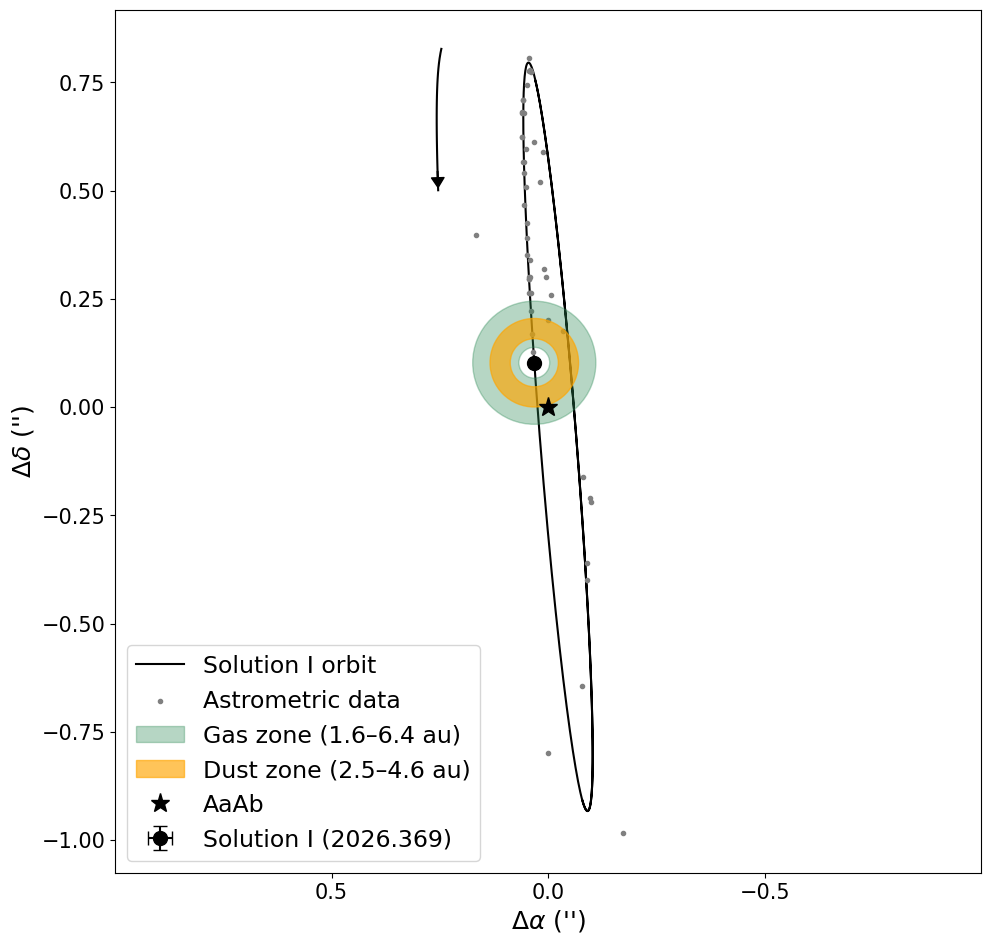

In [56]:
import matplotlib.patches as patches
from astropy.time import Time as ATime

# Today's epoch (decimal year)
today_yr = ATime('2026-05-15').byear

#Arrow point
arrow_yr = ATime('2015-05-13').byear

# Interpolate position — large-uncertainty solution
xm_today = float(np.interp(today_yr, t_xy_yr, qx[1]))
ym_today = float(np.interp(today_yr, t_xy_yr, qy[1]))
xm_lo    = float(np.interp(today_yr, t_xy_yr, qx[0]))
xm_hi    = float(np.interp(today_yr, t_xy_yr, qx[2]))
ym_lo    = float(np.interp(today_yr, t_xy_yr, qy[0]))
ym_hi    = float(np.interp(today_yr, t_xy_yr, qy[2]))

# Interpolate position — small-uncertainty solution
#xm_today_s = float(np.interp(today_yr, t_xy_yr, qx_1[1]))
#ym_today_s = float(np.interp(today_yr, t_xy_yr, qy_1[1]))
#xm_lo_s    = float(np.interp(today_yr, t_xy_yr, qx_1[0]))
#xm_hi_s    = float(np.interp(today_yr, t_xy_yr, qx_1[2]))
#ym_lo_s    = float(np.interp(today_yr, t_xy_yr, qy_1[0]))
#ym_hi_s    = float(np.interp(today_yr, t_xy_yr, qy_1[2]))

print(f"Today ({today_yr:.4f}):  Large: Δα = {xm_today:.4f}''  Δδ = {ym_today:.4f}''")
#print(f"Today ({today_yr:.4f}):  Small: Δα = {xm_today_s:.4f}''  Δδ = {ym_today_s:.4f}''")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# direction-of-motion arrow — curved tail that follows the orbit, offset outward
idx_now   = int(np.argmin(np.abs(t_xy_yr - arrow_yr)))
idx_tail  = max(idx_now - 18, 0)
idx_head  = min(idx_now + 2,  len(t_xy_yr) - 1)
offset    = 0.2   # arcsec outward shift

# Build offset curve: for each point compute its per-point outward normal
curve_x = qx[1][idx_tail : idx_head + 1]
curve_y = qy[1][idx_tail : idx_head + 1]

offset_x, offset_y = [], []
for i in range(len(curve_x)):
    i0, i1 = max(i - 1, 0), min(i + 1, len(curve_x) - 1)
    tang = np.array([curve_x[i1] - curve_x[i0], curve_y[i1] - curve_y[i0]])
    norm = np.linalg.norm(tang)
    if norm > 0:
        tang /= norm
    perp = np.array([-tang[1], tang[0]])
    mid  = np.array([curve_x[i], curve_y[i]])
    if np.dot(perp, mid) < 0:
        perp = -perp
    offset_x.append(curve_x[i] + offset * perp[0])
    offset_y.append(curve_y[i] + offset * perp[1])

# Draw the curved tail (no marker, just the line)
ax.plot(offset_x, offset_y, color="k", lw=1.5, zorder=7)

# Arrowhead only: short segment at the very end of the offset curve
style = "Simple, tail_width=0.5, head_width=9, head_length=7"
kw    = dict(arrowstyle=style, color="k", zorder=8)
ax.add_patch(patches.FancyArrowPatch(
    (offset_x[-3], offset_y[-3]), (offset_x[-1], offset_y[-1]),
    connectionstyle="arc3,rad=0.0",
    transform=ax.transData, **kw))

# orbit curves
ax.plot(qx[1],   qy[1],   color="k", lw=1.5, zorder=2, label='Solution I orbit')
#ax.plot(qx_1[1], qy_1[1], color="b", lw=1.5, zorder=2, ls='--', label='Solution II orbit')

# astrometric data
ax.scatter(yd, xd, marker='.', color='gray', zorder=3, label='Astrometric data')

# disc annuli — large solution
ax.add_patch(patches.Wedge((xm_today, ym_today), r=gas_outer, theta1=0, theta2=360,
                           width=gas_outer - gas_inner,
                           color='seagreen', alpha=0.35, zorder=4,
                           label=f'Gas zone ({gas_inner_au}–{gas_outer_au} au)'))
ax.add_patch(patches.Wedge((xm_today, ym_today), r=dust_outer, theta1=0, theta2=360,
                           width=dust_outer - dust_inner,
                           color='orange', alpha=0.65, zorder=4,
                           label=f'Dust zone ({dust_inner_au}–{dust_outer_au} au)'))

# position + 1-sigma error bars — large solution
ax.errorbar(xm_today, ym_today,
            xerr=[[xm_today - xm_lo], [xm_hi - xm_today]],
            yerr=[[ym_today - ym_lo], [ym_hi - ym_today]],
            fmt='o', color='k', ms=10, lw=1.5, capsize=5, zorder=5,
            label=f'Solution I ({today_yr:.3f})')

# disc annuli — small solution
#ax.add_patch(patches.Wedge((xm_today_s, ym_today_s), r=gas_outer, theta1=0, theta2=360,
#                           width=gas_outer - gas_inner,
#                           color='seagreen', alpha=0.20, zorder=4))
#ax.add_patch(patches.Wedge((xm_today_s, ym_today_s), r=dust_outer, theta1=0, theta2=360,
#                           width=dust_outer - dust_inner,
#                           color='orange', alpha=0.35, zorder=4))

# position + 1-sigma error bars — small solution
#ax.errorbar(xm_today_s, ym_today_s,
#            xerr=[[xm_today_s - xm_lo_s], [xm_hi_s - xm_today_s]],
#            yerr=[[ym_today_s - ym_lo_s], [ym_hi_s - ym_today_s]],
#            fmt='o', color='steelblue', ms=10, lw=1.5, capsize=5, zorder=5,
#            label=f'Solution II ({today_yr:.3f})')

# reference star
ax.plot(0, 0, 'k*', ms=14, label='AaAb', zorder=6)

ax.set_ylabel(r"$\Delta \delta$ ('')", fontsize=18)
ax.set_xlabel(r"$\Delta \alpha$ ('')", fontsize=18)
ax.invert_xaxis()
ax.set_aspect('equal')
#ax.set_title(f"HD 98800 AB — disc position ({ATime('2026-03-15').strftime('%Y-%m-%d')})", fontsize=14)
plt.setp(ax, xlim=[1.0, -1.0])
ax.set_xticks([-0.5, 0.0, 0.5])
ax.legend(loc='lower left', fontsize=17)

plt.tight_layout()
plt.savefig('Plots/AB_disk_toyModel_today.pdf')
plt.show()


In [57]:
# Save predicted orbit posteriors to CSV
# ─────────────────────────────────────────────────────────────────────────────
# qx / qy  use the t_fine_xy grid (t_fine_xy, t_xy_yr)  — shape (3, 400)
# rho/theta use the model's t_fine grid (T0 ± P_0/2, num matches rho_save)

# Reconstruct the rho/theta time grid to match rho_save / theta_save length
# (the model was compiled with this grid; t_fine may have been reassigned since)
n_rt      = rho_save.shape[1]
t_fine_rt = np.linspace(T0 - P_0/2, T0 + P_0/2, num=n_rt)
t_yr_rt   = Time(np.ascontiguousarray(t_fine_rt), format='jd').byear

# ── Large-uncertainty solution (AB_astrometry_2) ─────────────────────────────
df_xy_large = pd.DataFrame({
    'JD'        : t_fine_xy,
    'year'      : t_xy_yr,
    'x_lo'      : qx[0],    # Δα  16th percentile  (arcsec)
    'x_med'     : qx[1],    # Δα  50th percentile
    'x_hi'      : qx[2],    # Δα  84th percentile
    'y_lo'      : qy[0],    # Δδ  16th percentile  (arcsec)
    'y_med'     : qy[1],    # Δδ  50th percentile
    'y_hi'      : qy[2],    # Δδ  84th percentile
})

df_rt_large = pd.DataFrame({
    'JD'         : t_fine_rt,
    'year'       : t_yr_rt,
    'rho_lo'     : rho_save[0],            # separation 16th  (arcsec)
    'rho_med'    : rho_save[1],
    'rho_hi'     : rho_save[2],
    'theta_lo'   : theta_save[0] * rad_2_deg % 360,   # PA 16th  (deg)
    'theta_med'  : theta_save[1] * rad_2_deg % 360,
    'theta_hi'   : theta_save[2] * rad_2_deg % 360,
})

df_xy_large.to_csv('CSV/AB_orbit_xy_Sol_I.csv', index=False)
df_rt_large.to_csv('CSV/AB_orbit_rho_theta_Sol_I.csv', index=False)
print("Saved: CSV/AB_orbit_xy_Sol_I.csv  |  CSV/AB_orbit_rho_theta_Sol_I.csv")

# ── Small-uncertainty solution (AB_astrometry_3) ─────────────────────────────
#df_xy_small = pd.DataFrame({
#    'JD'        : t_fine_xy,
#    'year'      : t_xy_yr,
#    'x_lo'      : qx_1[0],
#    'x_med'     : qx_1[1],
#    'x_hi'      : qx_1[2],
#    'y_lo'      : qy_1[0],
#    'y_med'     : qy_1[1],
#    'y_hi'      : qy_1[2],
#})

#df_rt_small = pd.DataFrame({
#    'JD'         : t_fine_rt,
#    'year'       : t_yr_rt,
#    'rho_lo'     : rho_save_1[0],
#    'rho_med'    : rho_save_1[1],
#    'rho_hi'     : rho_save_1[2],
#    'theta_lo'   : theta_save_1[0] * rad_2_deg % 360,
#    'theta_med'  : theta_save_1[1] * rad_2_deg % 360,
#    'theta_hi'   : theta_save_1[2] * rad_2_deg % 360,
#})

#df_xy_small.to_csv('CSV/AB_orbit_xy_Sol_II.csv', index=False)
#df_rt_small.to_csv('CSV/AB_orbit_rho_theta_Sol_II.csv', index=False)
#print("Saved: CSV/AB_orbit_xy_Sol_II.csv  |  CSV/AB_orbit_rho_theta_Sol_II.csv")

print("\nColumn summary:")
print("  xy files    : JD, year, x_lo/med/hi [arcsec], y_lo/med/hi [arcsec]")
print("  rho/θ files : JD, year, rho_lo/med/hi [arcsec], theta_lo/med/hi [deg]")


Saved: CSV/AB_orbit_xy_Sol_I.csv  |  CSV/AB_orbit_rho_theta_Sol_I.csv

Column summary:
  xy files    : JD, year, x_lo/med/hi [arcsec], y_lo/med/hi [arcsec]
  rho/θ files : JD, year, rho_lo/med/hi [arcsec], theta_lo/med/hi [deg]


Disc projection: i = 26.0 deg, PA = 15.6 deg, cos(i) = 0.8988
Projected-ellipse coordinate q_med range: 0.02889 - 0.28602 arcsec
Sky separation rho_med range:            0.02682 - 0.28352 arcsec

Dust outer edge (4.6 au = 0.10222 arcsec):
  Median entry: 2026.476
    1σ range: 2026.459 - 2026.493
  Median exit: 2030.397
    1σ range: 2030.361 - 2030.434

Dust inner edge (2.5 au = 0.05556 arcsec):
  Median entry: 2027.476
    1σ range: 2027.454 - 2027.500
  Median exit: 2029.378
    1σ range: 2029.351 - 2029.406

Gas  outer edge (6.4 au = 0.14222 arcsec):
  Median entry: 2025.645
    1σ range: 2025.633 - 2025.658
  Median exit: 2031.227
    1σ range: 2031.186 - 2031.267

Gas  inner edge (1.6 au = 0.03556 arcsec):
  Median entry: 2028.052
    1σ range: 2028.030 - 2028.074
  Median exit: 2028.729
    1σ range: 2028.706 - 2028.757

Minimum ellipse-coordinate distance q: 0.02889 arcsec (1.30 au) at 2028.246
Sky separation at same epoch rho:      0.02682 arcsec (1.21 au)


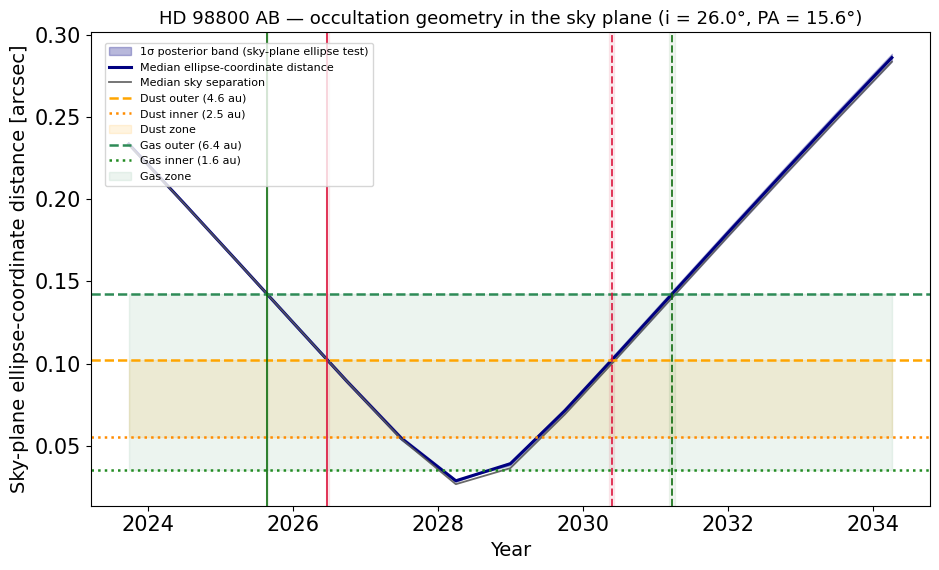

Saved: CSV/hd98800_occultation_skyplane_Sol_I.csv


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xy_file  = "CSV/AB_orbit_xy_Sol_I.csv"   # or AB_orbit_xy_large.csv if that is your local name
out_png  = "Plots/hd98800_occultation_skyplane.pdf"
out_csv  = "CSV/hd98800_occultation_skyplane_Sol_I.csv"

# Window to display
tmin, tmax = 2023.0, 2035.0

# --- Disc geometry ---
inc_disc = 26.0      # deg
PA_disc  = 15.6      # deg, major-axis PA measured N->E
inc_rad  = np.radians(inc_disc)
PA_rad   = np.radians(PA_disc)
cos_inc  = np.cos(inc_rad)

# --- Distance and disc radii ---
dist_pc = 45.0

gas_inner_au, gas_outer_au   = 1.6, 6.4
dust_inner_au, dust_outer_au = 2.5, 4.6

gas_inner  = gas_inner_au  / dist_pc
gas_outer  = gas_outer_au  / dist_pc
dust_inner = dust_inner_au / dist_pc
dust_outer = dust_outer_au / dist_pc

# --- Read orbit tracks ---
xy = pd.read_csv(xy_file).apply(pd.to_numeric, errors='coerce').dropna()
xy = xy[(xy['year'] >= tmin) & (xy['year'] <= tmax)].copy()

t_yr = xy['year'].to_numpy()
JD   = xy['JD'].to_numpy()

x_lo,  x_med,  x_hi  = xy['x_lo'].to_numpy(),  xy['x_med'].to_numpy(),  xy['x_hi'].to_numpy()
y_lo,  y_med,  y_hi  = xy['y_lo'].to_numpy(),  xy['y_med'].to_numpy(),  xy['y_hi'].to_numpy()

# --- Rotate sky coordinates into disc-aligned frame ---
# x = east offset, y = north offset assumed from astrometry convention
# Rotate so xp lies along disc major axis, yp along projected minor axis.
def rotate_to_disc_frame(x, y, pa_rad):
    xp = x * np.sin(pa_rad) + y * np.cos(pa_rad)
    yp = x * np.cos(pa_rad) - y * np.sin(pa_rad)
    return xp, yp

xp_lo,  yp_lo  = rotate_to_disc_frame(x_lo,  y_lo,  PA_rad)
xp_med, yp_med = rotate_to_disc_frame(x_med, y_med, PA_rad)
xp_hi,  yp_hi  = rotate_to_disc_frame(x_hi,  y_hi,  PA_rad)

# Ellipse-coordinate radius in sky plane:
# q = 1 on projected disc edge, q < 1 inside, q > 1 outside
# For a circular disc of radius a inclined by i:
#   (xp/a)^2 + (yp/(a cos i))^2 = 1
# so define q = sqrt( xp^2 + yp^2 / cos^2(i) ), then crossings are q = a
def ellipse_radius(xp, yp, cos_inc):
    return np.sqrt(xp**2 + (yp**2) / cos_inc**2)

q_lo  = ellipse_radius(xp_lo,  yp_lo,  cos_inc)
q_med = ellipse_radius(xp_med, yp_med, cos_inc)
q_hi  = ellipse_radius(xp_hi,  yp_hi,  cos_inc)

# Also keep plain sky separation for reference
rho_lo  = np.sqrt(x_lo**2  + y_lo**2)
rho_med = np.sqrt(x_med**2 + y_med**2)
rho_hi  = np.sqrt(x_hi**2  + y_hi**2)

# --- Crossing detection ---
def find_crossings(t, q, threshold):
    diff = q - threshold
    changes = np.where(diff[:-1] * diff[1:] <= 0)[0]
    out = []
    for i in changes:
        if diff[i+1] == diff[i]:
            continue
        t_cross = t[i] - diff[i] * (t[i+1] - t[i]) / (diff[i+1] - diff[i])
        direction = 'entry' if diff[i] > 0 else 'exit'
        out.append((t_cross, direction))
    return out

def crossing_range(t, q_lo, q_med, q_hi, threshold):
    return (
        find_crossings(t, q_med, threshold),
        find_crossings(t, q_lo, threshold),
        find_crossings(t, q_hi, threshold),
    )

dust_outer_cross_med, dust_outer_cross_lo, dust_outer_cross_hi = crossing_range(t_yr, q_lo, q_med, q_hi, dust_outer)
dust_inner_cross_med, dust_inner_cross_lo, dust_inner_cross_hi = crossing_range(t_yr, q_lo, q_med, q_hi, dust_inner)
gas_outer_cross_med,  gas_outer_cross_lo,  gas_outer_cross_hi  = crossing_range(t_yr, q_lo, q_med, q_hi, gas_outer)
gas_inner_cross_med,  gas_inner_cross_lo,  gas_inner_cross_hi  = crossing_range(t_yr, q_lo, q_med, q_hi, gas_inner)

imin_q     = np.argmin(q_med)
tmin_q     = float(t_yr[imin_q])
qmin       = float(q_med[imin_q])
rho_at_min = float(rho_med[imin_q])

print(f"Disc projection: i = {inc_disc:.1f} deg, PA = {PA_disc:.1f} deg, cos(i) = {cos_inc:.4f}")
print(f"Projected-ellipse coordinate q_med range: {q_med.min():.5f} - {q_med.max():.5f} arcsec")
print(f"Sky separation rho_med range:            {rho_med.min():.5f} - {rho_med.max():.5f} arcsec")

for edge_name, edge_au, edge_thr, c_med, c_lo, c_hi in [
    ("Dust outer", dust_outer_au, dust_outer, dust_outer_cross_med, dust_outer_cross_lo, dust_outer_cross_hi),
    ("Dust inner", dust_inner_au, dust_inner, dust_inner_cross_med, dust_inner_cross_lo, dust_inner_cross_hi),
    ("Gas  outer", gas_outer_au,  gas_outer,  gas_outer_cross_med,  gas_outer_cross_lo,  gas_outer_cross_hi),
    ("Gas  inner", gas_inner_au,  gas_inner,  gas_inner_cross_med,  gas_inner_cross_lo,  gas_inner_cross_hi),
]:
    print(f"\n{edge_name} edge ({edge_au:.1f} au = {edge_thr:.5f} arcsec):")
    for t_c, d in c_med:
        print(f"  Median {d}: {t_c:.3f}")
        lo_m = [x for x, dd in c_lo if dd == d]
        hi_m = [x for x, dd in c_hi if dd == d]
        if lo_m and hi_m:
            print(f"    1σ range: {min(lo_m[0], hi_m[0]):.3f} - {max(lo_m[0], hi_m[0]):.3f}")

print(f"\nMinimum ellipse-coordinate distance q: {qmin:.5f} arcsec ({qmin * dist_pc:.2f} au) at {tmin_q:.3f}")
print(f"Sky separation at same epoch rho:      {rho_at_min:.5f} arcsec ({rho_at_min * dist_pc:.2f} au)")

# --- Save results ---
out = pd.DataFrame({
    'JD': JD,
    'year': t_yr,
    'x_lo_arcsec': x_lo, 'x_med_arcsec': x_med, 'x_hi_arcsec': x_hi,
    'y_lo_arcsec': y_lo, 'y_med_arcsec': y_med, 'y_hi_arcsec': y_hi,
    'xp_lo_arcsec': xp_lo, 'xp_med_arcsec': xp_med, 'xp_hi_arcsec': xp_hi,
    'yp_lo_arcsec': yp_lo, 'yp_med_arcsec': yp_med, 'yp_hi_arcsec': yp_hi,
    'rho_lo_arcsec': rho_lo, 'rho_med_arcsec': rho_med, 'rho_hi_arcsec': rho_hi,
    'q_lo_arcsec': q_lo, 'q_med_arcsec': q_med, 'q_hi_arcsec': q_hi,
    'dust_inner_arcsec': dust_inner,
    'dust_outer_arcsec': dust_outer,
    'gas_inner_arcsec': gas_inner,
    'gas_outer_arcsec': gas_outer,
})
out.to_csv(out_csv, index=False)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9.5, 5.8))

ax.fill_between(t_yr, q_lo, q_hi, color='navy', alpha=0.28, label='1σ posterior band (sky-plane ellipse test)')
ax.plot(t_yr, q_med, color='navy', lw=2.2, label='Median ellipse-coordinate distance')
ax.plot(t_yr, rho_med, color='0.35', lw=1.3, alpha=0.9, label='Median sky separation')

ax.axhline(dust_outer, color='orange',     ls='--', lw=1.8, label=f'Dust outer ({dust_outer_au} au)')
ax.axhline(dust_inner, color='darkorange', ls=':',  lw=1.8, label=f'Dust inner ({dust_inner_au} au)')
ax.fill_between(t_yr, dust_inner, dust_outer, color='orange', alpha=0.12, label='Dust zone')

ax.axhline(gas_outer, color='seagreen',    ls='--', lw=1.8, label=f'Gas outer ({gas_outer_au} au)')
ax.axhline(gas_inner, color='forestgreen', ls=':',  lw=1.8, label=f'Gas inner ({gas_inner_au} au)')
ax.fill_between(t_yr, gas_inner, gas_outer, color='seagreen', alpha=0.09, label='Gas zone')

for t_c, d in dust_outer_cross_med:
    ax.axvline(t_c, color='crimson', lw=1.4, ls='--' if d == 'exit' else '-', alpha=0.85)
    lo_m = [x for x, dd in dust_outer_cross_lo if dd == d]
    hi_m = [x for x, dd in dust_outer_cross_hi if dd == d]
    if lo_m and hi_m:
        ax.axvspan(min(lo_m[0], hi_m[0]), max(lo_m[0], hi_m[0]), color='crimson', alpha=0.08)

for t_c, d in gas_outer_cross_med:
    ax.axvline(t_c, color='darkgreen', lw=1.4, ls='--' if d == 'exit' else '-', alpha=0.8)
    lo_m = [x for x, dd in gas_outer_cross_lo if dd == d]
    hi_m = [x for x, dd in gas_outer_cross_hi if dd == d]
    if lo_m and hi_m:
        ax.axvspan(min(lo_m[0], hi_m[0]), max(lo_m[0], hi_m[0]), color='darkgreen', alpha=0.06)

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Sky-plane ellipse-coordinate distance [arcsec]', fontsize=14)
ax.set_title(f'HD 98800 AB — occultation geometry in the sky plane (i = {inc_disc}°, PA = {PA_disc}°)', fontsize=13)
ax.legend(frameon=True, fontsize=8, loc='upper left', ncol=1, bbox_to_anchor=(0.01, 0.99))
plt.tight_layout()
#plt.savefig(out_png, bbox_inches='tight')
plt.show()

print(f"Saved: {out_csv}")
#print(f"Saved: {out_png}")

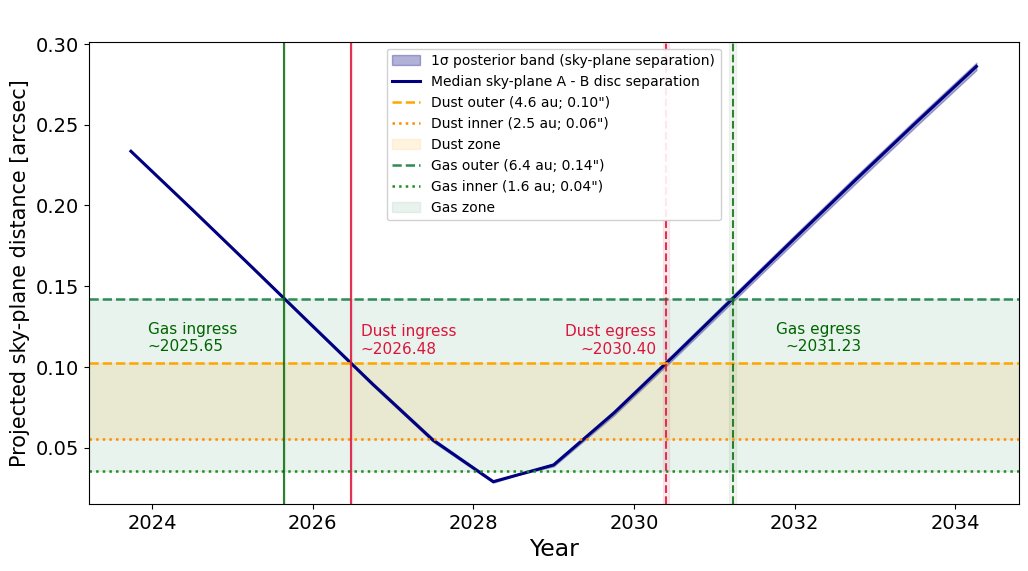

Saved: Plots/hd98800_occultation_solutionI.pdf


In [64]:
# ── Single-panel plot: Solution I (large-unc.) ──
# Uses the sky-plane ellipse-coordinate distances q_* computed for solution I.

FS_LABEL  = 17
FS_TICK   = 14
FS_LEGEND = 10
FS_CROSS  = 11
FS_TITLE  = 16

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

def draw_panel(ax, t_yr_p, q_lo_p, q_med_p, q_hi_p,
               dust_cross_med, dust_cross_lo, dust_cross_hi,
               gas_cross_med,  gas_cross_lo,  gas_cross_hi,
               title, plot_legend=False):

    ax.fill_between(t_yr_p, q_lo_p, q_hi_p, color="navy", alpha=0.30,
                    label="1σ posterior band (sky-plane separation)")
    ax.plot(t_yr_p, q_med_p, color="navy", lw=2.2,
            label="Median sky-plane A - B disc separation")

    ax.axhline(dust_outer, color="orange",     ls="--", lw=1.8,
               label=f'Dust outer ({dust_outer_au} au; {dust_outer:.2f}")')
    ax.axhline(dust_inner, color="darkorange", ls=":",  lw=1.8,
               label=f'Dust inner ({dust_inner_au} au; {dust_inner:.2f}")')
    ax.axhspan(dust_inner, dust_outer, color="orange", alpha=0.12, label="Dust zone")

    ax.axhline(gas_outer, color="seagreen",    ls="--", lw=1.8,
               label=f'Gas outer ({gas_outer_au} au; {gas_outer:.2f}")')
    ax.axhline(gas_inner, color="forestgreen", ls=":",  lw=1.8,
               label=f'Gas inner ({gas_inner_au} au; {gas_inner:.2f}")')
    ax.axhspan(gas_inner, gas_outer, color="seagreen", alpha=0.10, label="Gas zone")

    for t_c, d in dust_cross_med:
        ax.axvline(t_c, color="crimson", lw=1.5,
                   ls='--' if d == 'exit' else '-', alpha=0.85)
        x_off   = 0.12 if d == 'entry' else -0.12
        ha      = 'left' if d == 'entry' else 'right'
        d_label = 'ingress' if d == 'entry' else 'egress'
        ax.text(t_c + x_off, dust_outer * 1.04,
                f"Dust {d_label}\n~{t_c:.2f}", color="crimson",
                fontsize=FS_CROSS, va='bottom', ha=ha)
        lo_m = [x for x, dd in dust_cross_lo if dd == d]
        hi_m = [x for x, dd in dust_cross_hi if dd == d]
        if lo_m and hi_m:
            ax.axvspan(min(lo_m[0], hi_m[0]), max(lo_m[0], hi_m[0]),
                       color="crimson", alpha=0.08)

    for t_c, d in gas_cross_med:
        ax.axvline(t_c, color="darkgreen", lw=1.5,
                   ls='--' if d == 'exit' else '-', alpha=0.8)
        x_off   = -1.7 if d == 'entry' else 1.6
        ha      = 'left' if d == 'entry' else 'right'
        d_label = 'ingress' if d == 'entry' else 'egress'
        ax.text(t_c + x_off, gas_outer * 0.76,
                f"Gas {d_label}\n~{t_c:.2f}", color="darkgreen",
                fontsize=FS_CROSS, va='bottom', ha=ha)
        lo_m = [x for x, dd in gas_cross_lo if dd == d]
        hi_m = [x for x, dd in gas_cross_hi if dd == d]
        if lo_m and hi_m:
            ax.axvspan(min(lo_m[0], hi_m[0]), max(lo_m[0], hi_m[0]),
                       color="darkgreen", alpha=0.06)

    ax.set_xlabel("Year", fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_title(title, fontsize=FS_TITLE, pad=10)
    if plot_legend:
        ax.legend(frameon=True, fontsize=FS_LEGEND, loc="upper center", ncol=1, framealpha=0.9,
                  bbox_transform=ax.transAxes)

# Solution I
draw_panel(ax,
           t_yr, q_lo, q_med, q_hi,
           dust_outer_cross_med, dust_outer_cross_lo, dust_outer_cross_hi,
           gas_outer_cross_med,  gas_outer_cross_lo,  gas_outer_cross_hi,
           title=" ", plot_legend=True)

ax.set_ylabel("Projected sky-plane distance [arcsec]",
              fontsize=FS_LABEL - 2)

plt.savefig("Plots/hd98800_occultation_solutionI.pdf", bbox_inches='tight')
plt.show()
print("Saved: Plots/hd98800_occultation_solutionI.pdf")

In [67]:
# ── Build crossing table using the FULL sky-plane time-series (no plot window clip) ──
# Uses sky-plane ellipse-coordinate q derived from x/y posterior tracks:
#   q = sqrt(x'^2 + y'^2 / cos(i)^2)
# where x', y' are coordinates rotated into the disc-aligned sky frame.

YEAR_MIN_TABLE = 2020.0

def byear_to_date(byear):
    y = int(np.floor(byear))
    frac = byear - y
    days = int(round(frac * 365.2425))
    base = np.datetime64(f"{y}-01-01")
    dt = base + np.timedelta64(days, "D")
    return str(dt)[:10].replace("-", ".")

def rotate_to_disc_frame(x, y, pa_rad):
    xp = x * np.sin(pa_rad) + y * np.cos(pa_rad)
    yp = x * np.cos(pa_rad) - y * np.sin(pa_rad)
    return xp, yp

def ellipse_radius(xp, yp, cos_inc):
    return np.sqrt(xp**2 + (yp**2) / cos_inc**2)

def find_crossings(t, q, threshold):
    diff = q - threshold
    changes = np.where(diff[:-1] * diff[1:] <= 0)[0]
    out = []
    for i in changes:
        if diff[i+1] == diff[i]:
            continue
        t_cross = t[i] - diff[i] * (t[i+1] - t[i]) / (diff[i+1] - diff[i])
        direction = "entry" if diff[i] > 0 else "exit"
        out.append((t_cross, direction))
    return out

def crossing_range(t, q_lo, q_med, q_hi, threshold):
    return (
        find_crossings(t, q_med, threshold),
        find_crossings(t, q_lo, threshold),
        find_crossings(t, q_hi, threshold),
    )

def crossing_stats(cross_med, cross_lo, cross_hi, direction, year_min=YEAR_MIN_TABLE):
    med_t = next((t for t, d in cross_med if d == direction and t > year_min), None)
    lo_t  = next((t for t, d in cross_lo  if d == direction and t > year_min), None)
    hi_t  = next((t for t, d in cross_hi  if d == direction and t > year_min), None)
    if None in (med_t, lo_t, hi_t):
        return None
    return (min(lo_t, hi_t), med_t, max(lo_t, hi_t))

def phase_label(label_prefix, direction):
    is_inner = "inner" in label_prefix.lower()
    if is_inner:
        phase = "egress" if direction == "entry" else "ingress"
    else:
        phase = "ingress" if direction == "entry" else "egress"
    return f"{label_prefix} {phase}"

# ── Load full sky-plane orbital tracks ───────────────────────────────────────
rt_full   = pd.read_csv(xy_file).apply(pd.to_numeric, errors="coerce").dropna()
#rt_full_s = pd.read_csv(xy_file_s).apply(pd.to_numeric, errors="coerce").dropna()

t_full   = rt_full["year"].to_numpy()
#t_full_s = rt_full_s["year"].to_numpy()

x_lo   = rt_full["x_lo"].to_numpy();   x_med   = rt_full["x_med"].to_numpy();   x_hi   = rt_full["x_hi"].to_numpy()
y_lo   = rt_full["y_lo"].to_numpy();   y_med   = rt_full["y_med"].to_numpy();   y_hi   = rt_full["y_hi"].to_numpy()

#x_lo_s = rt_full_s["x_lo"].to_numpy(); x_med_s = rt_full_s["x_med"].to_numpy(); x_hi_s = rt_full_s["x_hi"].to_numpy()
#y_lo_s = rt_full_s["y_lo"].to_numpy(); y_med_s = rt_full_s["y_med"].to_numpy(); y_hi_s = rt_full_s["y_hi"].to_numpy()

# ── Rotate into the disc-aligned sky frame and compute q ─────────────────────
xp_lo, yp_lo = rotate_to_disc_frame(x_lo, y_lo, PA_rad)
xp_med, yp_med = rotate_to_disc_frame(x_med, y_med, PA_rad)
xp_hi, yp_hi = rotate_to_disc_frame(x_hi, y_hi, PA_rad)

q_lo  = ellipse_radius(xp_lo,  yp_lo,  cos_inc)
q_med = ellipse_radius(xp_med, yp_med, cos_inc)
q_hi  = ellipse_radius(xp_hi,  yp_hi,  cos_inc)

#xp_lo_s, yp_lo_s = rotate_to_disc_frame(x_lo_s, y_lo_s, PA_rad)
#xp_med_s, yp_med_s = rotate_to_disc_frame(x_med_s, y_med_s, PA_rad)
#xp_hi_s, yp_hi_s = rotate_to_disc_frame(x_hi_s, y_hi_s, PA_rad)

#q_lo_s  = ellipse_radius(xp_lo_s,  yp_lo_s,  cos_inc)
#q_med_s = ellipse_radius(xp_med_s, yp_med_s, cos_inc)
#q_hi_s  = ellipse_radius(xp_hi_s,  yp_hi_s,  cos_inc)

print(f"Sky-plane method applied: i={inc_disc}°, PA={PA_disc}°")
print(f"  Large: q ∈ [{q_med.min():.4f}, {q_med.max():.4f}] arcsec")
#print(f"  Small: q ∈ [{q_med_s.min():.4f}, {q_med_s.max():.4f}] arcsec")

# ── Compute all edge crossings from the full sky-plane time-series ──────────
edges_large = {
    "Dust outer": crossing_range(t_full, q_lo, q_med, q_hi, dust_outer),
    "Dust inner": crossing_range(t_full, q_lo, q_med, q_hi, dust_inner),
    "Gas outer" : crossing_range(t_full, q_lo, q_med, q_hi, gas_outer),
    "Gas inner" : crossing_range(t_full, q_lo, q_med, q_hi, gas_inner),
}
#edges_small = {
#    "Dust outer": crossing_range(t_full_s, q_lo_s, q_med_s, q_hi_s, dust_outer),
#    "Dust inner": crossing_range(t_full_s, q_lo_s, q_med_s, q_hi_s, dust_inner),
#    "Gas outer" : crossing_range(t_full_s, q_lo_s, q_med_s, q_hi_s, gas_outer),
#    "Gas inner" : crossing_range(t_full_s, q_lo_s, q_med_s, q_hi_s, gas_inner),
#}

# ── Build table ───────────────────────────────────────────────────────────────
crossing_table = {}
for sol_key, edges in [("Large unc.", edges_large)]:#, ("Small unc.", edges_small)]:
    rows = {}
    for label_prefix, (med, lo, hi) in edges.items():
        for direction in ("entry", "exit"):
            stats = crossing_stats(med, lo, hi, direction)
            if stats is not None:
                rows[phase_label(label_prefix, direction)] = stats
    crossing_table[sol_key] = rows

# ── Print debug table ─────────────────────────────────────────────────────────
print(f"\n{'Solution':<14} {'Crossing':<22}  {'Early (−1σ)':<14}  {'Median':<14}  {'Late (+1σ)'}")
print("-" * 78)
for sol, crossings in crossing_table.items():
    for name, (lo, med, hi) in crossings.items():
        print(f"{sol:<14} {name:<22}  {byear_to_date(lo):<14}  {byear_to_date(med):<14}  {byear_to_date(hi)}")
    print()

# ── Sanity check ──────────────────────────────────────────────────────────────
expected_order = [
    "Gas outer ingress",
    "Dust outer ingress",
    "Dust inner egress",
    "Gas inner egress",
    "Gas inner ingress",
    "Dust inner ingress",
    "Dust outer egress",
    "Gas outer egress",
]

for sol, crossings in crossing_table.items():
    sorted_names = [name for name, _ in sorted(crossings.items(), key=lambda kv: kv[1][1])]
    if sorted_names == expected_order:
        print(f"[OK] {sol}: phase order matches expected physical sequence.")
    else:
        print(f"[WARNING] {sol}: sorted phase order differs from expected physical sequence.")
        print("  Expected:", " -> ".join(expected_order))
        print("  Found   :", " -> ".join(sorted_names))

Sky-plane method applied: i=26.0°, PA=15.6°
  Large: q ∈ [0.0289, 0.9408] arcsec

Solution       Crossing                Early (−1σ)     Median          Late (+1σ)
------------------------------------------------------------------------------
Large unc.     Dust outer ingress      2026.06.17      2026.06.23      2026.06.29
Large unc.     Dust outer egress       2030.05.12      2030.05.26      2030.06.08
Large unc.     Dust inner egress       2027.06.15      2027.06.23      2027.07.02
Large unc.     Dust inner ingress      2029.05.09      2029.05.19      2029.05.29
Large unc.     Gas outer ingress       2025.08.20      2025.08.24      2025.08.29
Large unc.     Gas outer egress        2031.03.10      2031.03.24      2031.04.08
Large unc.     Gas inner egress        2028.01.11      2028.01.19      2028.01.27
Large unc.     Gas inner ingress       2028.09.14      2028.09.23      2028.10.03

[OK] Large unc.: phase order matches expected physical sequence.


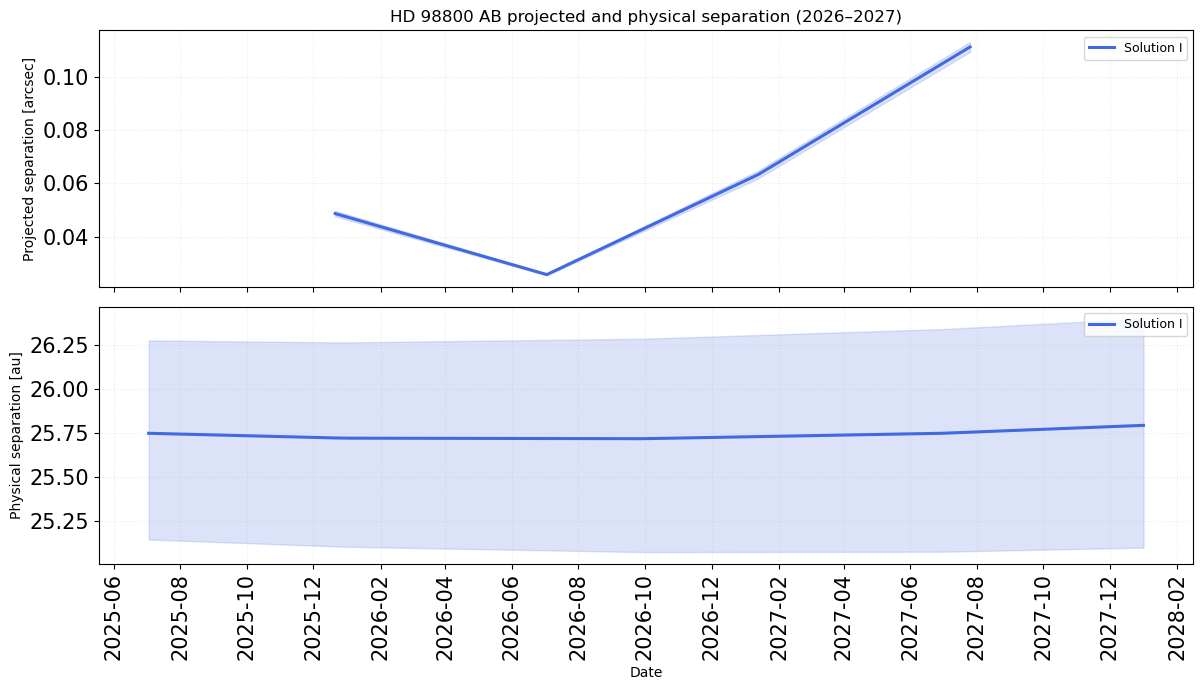

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import interp1d

def to_datetime_from_byear(byear):
    byear = np.asarray(byear, dtype=float)
    y = np.floor(byear).astype(int)
    frac = byear - y
    days = np.rint(frac * 365.2425).astype(int)
    return np.array([np.datetime64(f'{yy:04d}-01-01') + np.timedelta64(int(dd), 'D') for yy, dd in zip(y, days)])

proj_large = df_rt_large.copy()
#proj_small = df_rt_small.copy()


proj_large['date'] = to_datetime_from_byear(proj_large['year'])
#proj_small['date'] = to_datetime_from_byear(proj_small['year'])


start = np.datetime64('2025-10-01')
end   = np.datetime64('2027-12-31')

# dense grid for 2026–2027
t_dense = np.linspace(2025.5, 2028.0, 400)

t = df_r_large["year"].to_numpy()

r_lo_dense_large  = interp1d(t, df_r_large["r_lo_au"].to_numpy(), kind="linear", fill_value="extrapolate")(t_dense)
r_med_dense_large = interp1d(t, df_r_large["r_med_au"].to_numpy(), kind="linear", fill_value="extrapolate")(t_dense)
r_hi_dense_large  = interp1d(t, df_r_large["r_hi_au"].to_numpy(), kind="linear", fill_value="extrapolate")(t_dense)

#r_lo_dense_small  = interp1d(t, df_r_small["r_lo_au"].to_numpy(), kind="linear", fill_value="extrapolate")(t_dense)
#r_med_dense_small = interp1d(t, df_r_small["r_med_au"].to_numpy(), kind="linear", fill_value="extrapolate")(t_dense)
#r_hi_dense_small  = interp1d(t, df_r_small["r_hi_au"].to_numpy(), kind="linear", fill_value="extrapolate")(t_dense)

t_dense_daytime = to_datetime_from_byear(t_dense)

for df in (proj_large,):
    mask = (df['date'] >= start) & (df['date'] < end)
    df.drop(df.index[~mask], inplace=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].fill_between(proj_large['date'], proj_large['rho_lo'], proj_large['rho_hi'], color='royalblue', alpha=0.18)
axes[0].plot(proj_large['date'], proj_large['rho_med'], color='royalblue', lw=2.2, label='Solution I')
#axes[0].fill_between(proj_small['date'], proj_small['rho_lo'], proj_small['rho_hi'], color='black', alpha=0.10)
#axes[0].plot(proj_small['date'], proj_small['rho_med'], color='black', lw=2.0, label='Solution II')
axes[0].set_ylabel('Projected separation [arcsec]')
axes[0].legend(frameon=True, fontsize=9)
axes[0].grid(True, linestyle=':', alpha=0.25)

axes[1].fill_between(t_dense_daytime, r_lo_dense_large, r_hi_dense_large,
                     color='royalblue', alpha=0.18)
axes[1].plot(t_dense_daytime, r_med_dense_large,
             color='royalblue', lw=2.2, label='Solution I')

#axes[1].fill_between(t_dense_daytime, r_lo_dense_small, r_hi_dense_small,
#                     color='black', alpha=0.10)
#axes[1].plot(t_dense_daytime, r_med_dense_small,
#             color='black', lw=2.0, label='Solution II')

axes[1].set_ylabel('Physical separation [au]')
axes[1].set_xlabel('Date')
axes[1].legend(frameon=True, fontsize=9)
axes[1].grid(True, linestyle=':', alpha=0.25)

locator = mdates.MonthLocator(interval=2)
formatter = mdates.DateFormatter('%Y-%m')
for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

plt.setp(axes[1].get_xticklabels(), rotation=90, ha='center')
axes[0].set_title('HD 98800 AB projected and physical separation (2026–2027)')
plt.tight_layout()
plt.show()

In [69]:
# ── Generate LaTeX table sorted chronologically by median date ───────────────

lines = []
lines.append(r"\begin{table}")
lines.append(r"\tiny")
lines.append(r"\caption{Predicted time windows for the occultation of AaAb by the")
lines.append(r"BaBb disc in HD~98800. The quoted dates correspond to the early")
lines.append(r"($-1\sigma$), median, and late ($+1\sigma$) limits of the predicted")
lines.append(r"sky-plane crossing window.}")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lccc}")
lines.append(r"\hline")
lines.append(r"\hline")
lines.append(r"Crossing phase & Early ($-1\sigma$) & Median & Late ($+1\sigma$) \\")
lines.append(r"\hline")

sol_labels = {"Large unc.": "Solution I"}
#sol_labels = {"Large unc.": "Solution I", "Small unc.": "Solution II"}

for sol_key, sol_label in sol_labels.items():
    crossings = crossing_table[sol_key]
    sorted_rows = sorted(crossings.items(), key=lambda kv: kv[1][1])
    lines.append(r"\multicolumn{4}{c}{" + sol_label + r"} \\")
    lines.append(r"\hline")
    for name, (lo, med, hi) in sorted_rows:
        lines.append(
            f"{name} & {byear_to_date(lo)} & {byear_to_date(med)} & {byear_to_date(hi)} \\\\"
        )
    lines.append(r"\hline")

lines.append(r"\end{tabular}")
lines.append(r"\label{tab:occultation_window}")
lines.append(r"\end{table}")

print("\n".join(lines))

\begin{table}
\tiny
\caption{Predicted time windows for the occultation of AaAb by the
BaBb disc in HD~98800. The quoted dates correspond to the early
($-1\sigma$), median, and late ($+1\sigma$) limits of the predicted
sky-plane crossing window.}
\centering
\begin{tabular}{lccc}
\hline
\hline
Crossing phase & Early ($-1\sigma$) & Median & Late ($+1\sigma$) \\
\hline
\multicolumn{4}{c}{Solution I} \\
\hline
Gas outer ingress & 2025.08.20 & 2025.08.24 & 2025.08.29 \\
Dust outer ingress & 2026.06.17 & 2026.06.23 & 2026.06.29 \\
Dust inner egress & 2027.06.15 & 2027.06.23 & 2027.07.02 \\
Gas inner egress & 2028.01.11 & 2028.01.19 & 2028.01.27 \\
Gas inner ingress & 2028.09.14 & 2028.09.23 & 2028.10.03 \\
Dust inner ingress & 2029.05.09 & 2029.05.19 & 2029.05.29 \\
Dust outer egress & 2030.05.12 & 2030.05.26 & 2030.06.08 \\
Gas outer egress & 2031.03.10 & 2031.03.24 & 2031.04.08 \\
\hline
\end{tabular}
\label{tab:occultation_window}
\end{table}


In [70]:
import pandas as pd
import numpy as np

def _ms(arr):
    """Return (median, half-68%-interval sigma) from a 1-D posterior array."""
    a = np.asarray(arr, dtype=float)
    med = np.percentile(a, 50)
    sig = 0.5 * (np.percentile(a, 84) - np.percentile(a, 16))
    return med, sig

def _fmt(med, sig, fallback=None):
    """Format med ± sig with 2-sf uncertainty via fmt(), or return fallback if med is None."""
    if med is None:
        return fallback
    return fmt(med, sig)

# ── Load saved posteriors ─────────────────────────────────────────────────────
post_L = pd.read_csv('CSV/AB_posterior_Solution_I.csv')
mass_L = pd.read_csv('CSV/AB_posterior_Mass_plx_RVs_Solution_I.csv')
#post_S = pd.read_csv('CSV/AB_posterior_Solution_II.csv')
#mass_S = pd.read_csv('CSV/AB_posterior_Mass_plx_RVs_Solution_II.csv')

# ── Solution I (large-uncertainty astrometry) ─────────────────────────────────
P_I,    P_I_s    = _ms(post_L['$P$ (years)'])
Tp_I,   Tp_I_s   = _ms(post_L['$T_\\mathrm{p}$ (years)'])
e_I,    e_I_s    = _ms(post_L['$e$'])
om_I,   om_I_s   = _ms(post_L['$\\omega$ (deg)'])
Om_I,   Om_I_s   = _ms(post_L['$\\Omega$ (deg)'])
i_I,    i_I_s    = _ms(post_L['$i$ (deg)'])
a_I,    a_I_s    = _ms(post_L["$a$ ('')"])
MA_I,   MA_I_s   = _ms(mass_L['$MA$ [$M_{\\odot}$]'])
MB_I,   MB_I_s   = _ms(mass_L['$MB$ [$M_{\\odot}$]'])
pi_I,   pi_I_s   = _ms(mass_L['$\\pi$ [mas]'])
# K1, K2, gamma, a(AU), d(pc) come from mass_plx_large.csv once cell 17 is re-run
K1_I,   K1_I_s   = _ms(mass_L['K1 [km/s]'])             if 'K1 [km/s]'             in mass_L.columns else (None, None)
K2_I,   K2_I_s   = _ms(mass_L['K2 [km/s]'])             if 'K2 [km/s]'             in mass_L.columns else (None, None)
gam_I,  gam_I_s  = _ms(mass_L['$\\gamma_{AB}$ [km/s]'])  if '$\\gamma_{AB}$ [km/s]' in mass_L.columns else (None, None)
aAU_I,  aAU_I_s  = _ms(mass_L['$a$ (AU)'])               if '$a$ (AU)'              in mass_L.columns else (None, None)
d_I,    d_I_s    = _ms(mass_L['$d$ (pc)'])                if '$d$ (pc)'              in mass_L.columns else (None, None)

# ── Solution II (small-uncertainty astrometry) ────────────────────────────────
#P_II,   P_II_s   = _ms(post_S['$P$ (years)'])
#Tp_II,  Tp_II_s  = _ms(post_S['$T_\\mathrm{p}$ (years)'])
#e_II,   e_II_s   = _ms(post_S['$e$'])
#om_II,  om_II_s  = _ms(post_S['$\\omega$ (deg)'])
#Om_II,  Om_II_s  = _ms(post_S['$\\Omega$ (deg)'])
#i_II,   i_II_s   = _ms(post_S['$i$ (deg)'])
#a_II,   a_II_s   = _ms(post_S["$a$ ('')"])
#MA_II,  MA_II_s  = _ms(mass_S['$MA$ [$M_{\\odot}$]'])
#MB_II,  MB_II_s  = _ms(mass_S['$MB$ [$M_{\\odot}$]'])
#pi_II,  pi_II_s  = _ms(mass_S['$\\pi$ [mas]'])
## K1, K2, gamma, a(AU), d(pc) come from mass_plx_small.csv once cell 26 is re-run
#K1_II,  K1_II_s  = _ms(mass_S['K1 [km/s]'])             if 'K1 [km/s]'             in mass_S.columns else (None, None)
#K2_II,  K2_II_s  = _ms(mass_S['K2 [km/s]'])             if 'K2 [km/s]'             in mass_S.columns else (None, None)
#gam_II, gam_II_s = _ms(mass_S['$\\gamma_{AB}$ [km/s]'])  if '$\\gamma_{AB}$ [km/s]' in mass_S.columns else (None, None)
#aAU_II, aAU_II_s = _ms(mass_S['$a$ (AU)'])               if '$a$ (AU)'              in mass_S.columns else (None, None)
#d_II,   d_II_s   = _ms(mass_S['$d$ (pc)'])                if '$d$ (pc)'              in mass_S.columns else (None, None)

# ── Build table rows ──────────────────────────────────────────────────────────
row_P   = r"Period (yr)                  & $230 \\pm 20$    & " + _fmt(P_I,   P_I_s) + r" \\"
row_Tp  = r"$T_0$ (yr)                   & $2023 \\pm 1$    & " + _fmt(Tp_I,  Tp_I_s) + r" \\"
row_e   = r"$e$                          & $0.46 \\pm 0.02$ & " + _fmt(e_I,   e_I_s) + r" \\"
row_om  = r"$\\omega_A$ ($^\\circ$)        & $65 \\pm 5$      & " + _fmt(om_I,  om_I_s) + r" \\"
row_Om  = r"$\\Omega$ ($^\\circ$)          & $184.5 \\pm 0.1$ & " + _fmt(Om_I,  Om_I_s) + r" \\"
row_i   = r"$i$ ($^\\circ$)              & $88.1 \\pm 0.1$  & " + _fmt(i_I,   i_I_s) + r" \\"
row_gam = r"$\\gamma_{AB}$ (km s$^{-1}$) & $8.7 \\pm 0.7$   & " + _fmt(gam_I, gam_I_s,  r'$9.0 \\pm 0.1$') + r" \\"
row_MA  = r"$M_A$ (M$_\\odot$)           & $1.1 \\pm 0.3$   & " + _fmt(MA_I,  MA_I_s) + r" \\"
row_MB  = r"$M_B$ (M$_\\odot$)           & $1.4 \\pm 0.3$   & " + _fmt(MB_I,  MB_I_s) + r" \\"
row_pi  = r"$\\pi$ (mas)                 & $22.2 \\pm 0.5$  & " + _fmt(pi_I,  pi_I_s) + r" \\"
row_K1  = r"$K_A$ (km s$^{-1}$)         & $4.2 \\pm 0.8$   & " + _fmt(K1_I,  K1_I_s,   r'$4.0 \\pm 0.1$') + r" \\"
row_K2  = r"$K_B$ (km s$^{-1}$)         & $3.2 \\pm 0.8$   & " + _fmt(K2_I,  K2_I_s,   r'$3.5 \\pm 0.1$') + r" \\"
row_a   = r"$a$ ($^{\\prime\\prime}$)      & $1.13 \\pm 0.08$ & " + _fmt(a_I,   a_I_s) + r" \\"
row_aAU = r"$a$ (AU)                     & $51 \\pm 3$      & " + _fmt(aAU_I, aAU_I_s,  r'$48 \\pm 1$') + r" \\"
row_d   = r"$d$ (pc)                     & $45 \\pm 1$      & " + _fmt(d_I,   d_I_s,    r'$44.9 \\pm 0.4$') + r" \\"

# ── Assemble table ────────────────────────────────────────────────────────────
latex_table = "\n".join([
    r"\begin{table}",
    r"\tiny",
    r"\centering",
    (r"\caption{Orbital parameters for the HD\,98800 AB system.}"),
    r"\label{tab:orbit_AB}",
    r"\begin{tabular}{lcc}",
    r"\hline",
    r"\hline\\",
    r"Fitted parameters & SZF21 & Solution I \\",
    r"\hline \\",
    row_P, row_Tp, row_e, row_om, row_Om, row_i, row_gam,
    row_MA, row_MB, row_pi,
    r"&&\\",
    r"\hline",
    r"\hline\\",
    r"Derived parameters & & \\",
    r"\hline \\",
    row_K1, row_K2, row_a, row_aAU, row_d,
    r"\hline",
    r"\end{tabular}",
    r"\end{table}",
])

print(latex_table)

\begin{table}
\tiny
\centering
\caption{Orbital parameters for the HD\,98800 AB system.}
\label{tab:orbit_AB}
\begin{tabular}{lcc}
\hline
\hline\\
Fitted parameters & SZF21 & Solution I \\
\hline \\
Period (yr)                  & $230 \\pm 20$    & 185.1$\pm$7.5 \\
$T_0$ (yr)                   & $2023 \\pm 1$    & 2026.51$\pm$0.70 \\
$e$                          & $0.46 \\pm 0.02$ & 0.4187$\pm$0.0081 \\
$\\omega_A$ ($^\\circ$)        & $65 \\pm 5$      & 79.8$\pm$3.5 \\
$\\Omega$ ($^\\circ$)          & $184.5 \\pm 0.1$ & 184.430$\pm$0.038 \\
$i$ ($^\\circ$)              & $88.1 \\pm 0.1$  & 87.463$\pm$0.049 \\
$\\gamma_{AB}$ (km s$^{-1}$) & $8.7 \\pm 0.7$   & 9.10$\pm$0.27 \\
$M_A$ (M$_\\odot$)           & $1.1 \\pm 0.3$   & 1.25$\pm$0.14 \\
$M_B$ (M$_\\odot$)           & $1.4 \\pm 0.3$   & 1.27$\pm$0.14 \\
$\\pi$ (mas)                 & $22.2 \\pm 0.5$  & 21.53$\pm$0.31 \\
&&\\
\hline
\hline\\
Derived parameters & & \\
\hline \\
$K_A$ (km s$^{-1}$)         & $4.2 \\pm 0.8$   & 3.92$\p

In [71]:
# -----------------------------------------------------------------------
# Monthly motion of B relative to A at the current epoch
# Uses the pre-computed posterior percentile arrays (16th / 50th / 84th)
# -----------------------------------------------------------------------

month = 1 / 12          # one month in decimal years
now   = today_yr

t1 = now
t2 = now + month

def interp3(t_arr, vals_lo, vals_med, vals_hi, t):
    return (np.interp(t, t_arr, vals_lo),
            np.interp(t, t_arr, vals_med),
            np.interp(t, t_arr, vals_hi))

print(f"Current epoch : {now:.3f}")
print(f"Interval      : {t1:.3f}  →  {t2:.3f}  (+1 month)\n")

# qx/qy    → t_fine_xy grid  → t_xy_yr
# rho/theta → t_fine_rt grid → t_yr_rt  (reconstructed in the CSV-save cell)
for label, qx_p, qy_p, rho_p, theta_p in [
    ("Solution I  (large unc.)", qx,   qy,   rho_save,   theta_save),
    #("Solution II (small unc.)", qx_1, qy_1, rho_save_1, theta_save_1),
]:
    # --- sky positions (Δα, Δδ) ---
    x1_lo,  x1_med,  x1_hi  = interp3(t_xy_yr, qx_p[0], qx_p[1], qx_p[2], t1)
    x2_lo,  x2_med,  x2_hi  = interp3(t_xy_yr, qx_p[0], qx_p[1], qx_p[2], t2)
    y1_lo,  y1_med,  y1_hi  = interp3(t_xy_yr, qy_p[0], qy_p[1], qy_p[2], t1)
    y2_lo,  y2_med,  y2_hi  = interp3(t_xy_yr, qy_p[0], qy_p[1], qy_p[2], t2)

    dx_med    = x2_med - x1_med
    dy_med    = y2_med - y1_med
    dx_sig    = 0.5 * abs((x2_hi - x2_lo) + (x1_hi - x1_lo))
    dy_sig    = 0.5 * abs((y2_hi - y2_lo) + (y1_hi - y1_lo))
    total_med = np.sqrt(dx_med**2 + dy_med**2)

    # --- separation and PA (live on t_yr_rt) ---
    rho1_lo, rho1_med, rho1_hi = interp3(t_yr_rt, rho_p[0], rho_p[1], rho_p[2], t1)
    rho2_lo, rho2_med, rho2_hi = interp3(t_yr_rt, rho_p[0], rho_p[1], rho_p[2], t2)
    drho_med = rho2_med - rho1_med
    drho_sig = 0.5 * abs((rho2_hi - rho2_lo) + (rho1_hi - rho1_lo))

    th1_lo, th1_med, th1_hi = interp3(t_yr_rt, theta_p[0], theta_p[1], theta_p[2], t1)
    th2_lo, th2_med, th2_hi = interp3(t_yr_rt, theta_p[0], theta_p[1], theta_p[2], t2)
    dtheta_med = (th2_med - th1_med) * rad_2_deg
    dtheta_sig = 0.5 * abs((th2_hi - th2_lo) + (th1_hi - th1_lo)) * rad_2_deg

    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Δ(Δα)  per month : {dx_med*1000:+.2f}  ± {dx_sig*1000:.2f}  mas")
    print(f"  Δ(Δδ)  per month : {dy_med*1000:+.2f}  ± {dy_sig*1000:.2f}  mas")
    print(f"  |Δpos| per month : {total_med*1000:.2f}  mas  ({total_med:.4f} arcsec)")
    print(f"  Δρ     per month : {drho_med*1000:+.2f}  ± {drho_sig*1000:.2f}  mas")
    print(f"  Δθ     per month : {dtheta_med:+.4f}  ± {dtheta_sig:.4f}  deg\n")

Current epoch : 2026.369
Interval      : 2026.369  →  2026.452  (+1 month)

  Solution I  (large unc.)
  Δ(Δα)  per month : -0.28  ± 0.42  mas
  Δ(Δδ)  per month : -4.12  ± 1.54  mas
  |Δpos| per month : 4.13  mas  (0.0041 arcsec)
  Δρ     per month : -3.58  ± 0.92  mas
  Δθ     per month : +12.2632  ± 5.2556  deg



In [72]:
# Diagnostic: list all raw crossings to verify ordering and multiplicity

def _show_crossings(label, cross):
    print(f"\n{label} ({len(cross)} crossings):")
    for t_c, d in cross:
        print(f"  {t_c:.3f}  {d}")

print("=== Large uncertainty solution ===")
_show_crossings("Dust outer", dust_outer_cross_med)
_show_crossings("Dust inner", dust_inner_cross_med)
_show_crossings("Gas outer",  gas_outer_cross_med)
_show_crossings("Gas inner",  gas_inner_cross_med)

#print("\n=== Small uncertainty solution ===")
#_show_crossings("Dust outer", dust_outer_cross_med_s)
#_show_crossings("Dust inner", dust_inner_cross_med_s)
#_show_crossings("Gas outer",  gas_outer_cross_med_s)
#_show_crossings("Gas inner",  gas_inner_cross_med_s)

=== Large uncertainty solution ===

Dust outer (2 crossings):
  2026.476  entry
  2030.397  exit

Dust inner (2 crossings):
  2027.476  entry
  2029.378  exit

Gas outer (2 crossings):
  2025.645  entry
  2031.227  exit

Gas inner (2 crossings):
  2028.052  entry
  2028.729  exit
